In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
plots_dir = os.path.join(notebook_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)
save_file = True

In [3]:
def plot_conflicts_and_nogoods(file_1, file_2, config_1, config_2, problem_name, figsize=(8, 6)):
    problem_name_title = problem_name.replace(' ', '_')
    config_1_title = config_1.replace(' ', '_')
    config_2_title = config_2.replace(' ', '_')
    # Read CSVs
    df_1 = pd.read_csv(file_1)
    df_2   = pd.read_csv(file_2)
    #filter out unkowns and errors for plotting
    df_1 = df_1[df_1['ERROR']==0]
    df_1 = df_1[df_1['UNKNOWN']==0]
    df_2 = df_2[df_2['ERROR']==0]
    df_2 = df_2[df_2['UNKNOWN']==0]
    # NUMBER OF CONFLICTS
    df_1_sat = df_1[df_1['UNSATISFIABLE'] == 0]
    df_2_sat = df_2[df_2['UNSATISFIABLE'] == 0]
    df_1_unsat = df_1[df_1['UNSATISFIABLE'] == 1]
    df_2_unsat = df_2[df_2['UNSATISFIABLE'] == 1]
    print(df_1_unsat["Filename"].tolist())
    print(df_2_unsat["Filename"].tolist())
    print(df_1_sat["Filename"].tolist())
    print(df_2_sat["Filename"].tolist())
    conflicts_nomdd_sat = df_1_sat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_no_mdd'}
    )
    conflicts_nomdd_unsat = df_1_unsat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_no_mdd'}
    )
    conflicts_mdd_sat = df_2_sat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_mdd'}
    )
    conflicts_mdd_unsat = df_2_unsat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_mdd'}
    )
    df_conflicts_sat = pd.merge(conflicts_nomdd_sat, conflicts_mdd_sat, on='Filename', how='inner')
    df_conflicts_sat = df_conflicts_sat.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_conflicts_unsat = pd.merge(conflicts_nomdd_unsat, conflicts_mdd_unsat, on='Filename', how='inner')
    df_conflicts_unsat = df_conflicts_unsat.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_wrong_positive = pd.merge(conflicts_mdd_sat, conflicts_nomdd_unsat, on='Filename', how='left', indicator=True)
    df_wrong_negative = pd.merge(conflicts_nomdd_sat, conflicts_mdd_unsat, on='Filename', how='left', indicator=True)
    df_wrong_positive = df_wrong_positive.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_wrong_negative = df_wrong_negative.dropna(subset=['Conflicts_mdd', 'Conflicts_no_mdd'])
    print(df_wrong_positive['Filename'])
    print(df_wrong_negative['Filename'])
    # Scatter plot
    plt.figure(figsize=figsize)
    print(problem_name)
    if "Market Split".lower() in problem_name.lower():
        problem_types = ['s3', 's4', 's5', 'u3', 'u4', 'u5']
        color_map = {
            's3': '#E63946', ## - Rich red/crimson
            's4': '#F77F00', ## - Vibrant orange
            's5': '#FCBF49', ## - Golden yellow
            'u3': '#264653', ## - Deep teal/forest green
            'u4': '#2A9D8F', ## - Turquoise/mint green
            'u5': '#457B9D', ## - Steel blue
        }
        for problem_type in problem_types:
            df_current_sat = df_conflicts_sat[df_conflicts_sat['Filename'].str.contains(problem_type, na = False)]
            if not df_current_sat.empty:
                plt.scatter(df_current_sat['Conflicts_no_mdd'], df_current_sat['Conflicts_mdd'], alpha=0.7,label=f"Satisfiable - {problem_type}", color=color_map[problem_type])
            df_current_unsat = df_conflicts_unsat[df_conflicts_unsat['Filename'].str.contains(problem_type, na = False)]
            if not df_current_unsat.empty:
                plt.scatter(df_current_unsat['Conflicts_no_mdd'], df_current_unsat['Conflicts_mdd'], alpha=0.7,label=f"Unsatisfiable - {problem_type}", color=color_map[problem_type])



    else:
        plt.scatter(df_conflicts_sat['Conflicts_no_mdd'], df_conflicts_sat['Conflicts_mdd'], alpha=0.7,label="satisfiable")
        plt.scatter(df_conflicts_unsat['Conflicts_no_mdd'], df_conflicts_unsat['Conflicts_mdd'], alpha=0.7, label="unsatisfiable",color='red')
    plt.xscale('log')
    plt.yscale('log')

    min_val = min(df_conflicts_sat['Conflicts_no_mdd'].min(), df_conflicts_sat['Conflicts_mdd'].min(),df_conflicts_unsat['Conflicts_no_mdd'].min(), df_conflicts_unsat['Conflicts_mdd'].min())
    max_val = max(df_conflicts_sat['Conflicts_no_mdd'].max(), df_conflicts_sat['Conflicts_mdd'].max(),df_conflicts_unsat['Conflicts_no_mdd'].max(), df_conflicts_unsat['Conflicts_mdd'].max())
    max_val = max_val + (max_val - min_val) * 0.1


    # plt.xticks([25, 100, 1000, 5000, 10000, 30000])
    # plt.yticks([25, 100, 1000, 5000, 10000, 30000])

    def format_func(value, tick_position):
        return f'{int(value)}'

    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_func))
    min_val = max(min_val - 0.1, 1)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left')
    # Add a diagonal line for reference
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
    plt.xlabel(f'Number of Conflicts ({config_1})')
    plt.ylabel(f'Number of Conflicts ({config_2})')
    plt.title(f'{problem_name} Scatter Plot of Conflicts: {config_1} vs {config_2}')
    plt.grid(True)
    plt.tight_layout()
    if save_file:
        plt.savefig(f'plots/{problem_name_title}_conflicts_scatter_{config_1_title}_vs_{config_2_title}.png')
    plt.show()


    # Average LBD
    lbd_nomdd_sat = df_1_sat[['Filename', 'learnedClauseStatisticsAverageLbd']].rename(
        columns={'learnedClauseStatisticsAverageLbd': 'AverageLbd_no_mdd'}
    )
    lbd_nomdd_unsat = df_1_unsat[['Filename', 'learnedClauseStatisticsAverageLbd']].rename(
        columns={'learnedClauseStatisticsAverageLbd': 'AverageLbd_no_mdd'}
    )
    lbd_mdd_sat = df_2_sat[['Filename', 'learnedClauseStatisticsAverageLbd']].rename(
        columns={'learnedClauseStatisticsAverageLbd': 'AverageLbd_mdd'}
    )
    lbd_mdd_unsat = df_2_unsat[['Filename', 'learnedClauseStatisticsAverageLbd']].rename(
        columns={'learnedClauseStatisticsAverageLbd': 'AverageLbd_mdd'}
    )
    df_lbd_sat = pd.merge(lbd_nomdd_sat, lbd_mdd_sat, on='Filename', how='inner')
    df_lbd_sat = df_lbd_sat.dropna(subset=['AverageLbd_no_mdd', 'AverageLbd_mdd'])
    df_lbd_unsat = pd.merge(lbd_nomdd_unsat, lbd_mdd_unsat, on='Filename', how='inner')
    df_lbd_unsat = df_lbd_unsat.dropna(subset=['AverageLbd_no_mdd', 'AverageLbd_mdd'])
    # Scatter plot
    plt.figure(figsize=figsize)
    if "Market Split".lower() in problem_name.lower():
        problem_types = ['s3', 's4', 's5', 'u3', 'u4', 'u5']
        color_map = {
            's3': '#E63946', ## - Rich red/crimson
            's4': '#F77F00', ## - Vibrant orange
            's5': '#FCBF49', ## - Golden yellow
            'u3': '#264653', ## - Deep teal/forest green
            'u4': '#2A9D8F', ## - Turquoise/mint green
            'u5': '#457B9D', ## - Steel blue
        }
        for problem_type in problem_types:
            df_current_sat = df_lbd_sat[df_lbd_sat['Filename'].str.contains(problem_type, na = False)]
            if not df_current_sat.empty:
                plt.scatter(df_current_sat['AverageLbd_no_mdd'], df_current_sat['AverageLbd_mdd'], alpha=0.7,label=f"Satisfiable - {problem_type}", color=color_map[problem_type])
            df_current_unsat = df_lbd_unsat[df_lbd_unsat['Filename'].str.contains(problem_type, na = False)]
            if not df_current_unsat.empty:
                plt.scatter(df_current_unsat['AverageLbd_no_mdd'], df_current_unsat['AverageLbd_mdd'], alpha=0.7,label=f"Unsatisfiable - {problem_type}", color=color_map[problem_type])

    else:
        plt.scatter(df_lbd_sat['AverageLbd_no_mdd'], df_lbd_sat['AverageLbd_mdd'], alpha=0.7, color='orange',label="satisfiable")
        plt.scatter(df_lbd_unsat['AverageLbd_no_mdd'], df_lbd_unsat['AverageLbd_mdd'], alpha=0.7, color='red',label="unsatisfiable")
    min_val = min(df_lbd_sat['AverageLbd_no_mdd'].min(), df_lbd_sat['AverageLbd_mdd'].min(),df_lbd_unsat['AverageLbd_no_mdd'].min(), df_lbd_unsat['AverageLbd_mdd'].min())
    max_val = max(df_lbd_sat['AverageLbd_no_mdd'].max(), df_lbd_sat['AverageLbd_mdd'].max(),df_lbd_unsat['AverageLbd_no_mdd'].max(), df_lbd_unsat['AverageLbd_mdd'].max())
    ranges = max_val - min_val
    max_val = max_val + (max_val - min_val) * 0.1
    # Add a diagonal line for reference
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left')
    plt.xlabel(f'Average Lbd ({config_1})')
    plt.ylabel(f'Average Lbd ({config_2})')
    plt.title(f'{problem_name} Scatter Plot of Average Lbd: {config_1} vs {config_2}')
    plt.grid(True)
    plt.tight_layout()
    if save_file:
        plt.savefig(f'plots/{problem_name_title}_lbd_scatter_{config_1_title}_vs_{config_2_title}.png')
    plt.show()
    # NUMBER OF UNIT NOGOODS

    nogoods_nomdd_sat = df_1_sat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_no_mdd'}
    )
    nogoods_nomdd_unsat = df_1_unsat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_no_mdd'}
    )
    nogoods_mdd_sat = df_2_sat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_mdd'}
    )
    nogoods_mdd_unsat = df_2_unsat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_mdd'}
    )

    df_nogoods_sat = pd.merge(nogoods_nomdd_sat, nogoods_mdd_sat, on='Filename', how='inner')
    df_nogoods_sat = df_nogoods_sat.dropna(subset=['UnitNogoods_no_mdd', 'UnitNogoods_mdd'])
    df_nogoods_unsat = pd.merge(nogoods_nomdd_unsat, nogoods_mdd_unsat, on='Filename', how='inner')
    df_nogoods_unsat = df_nogoods_unsat.dropna(subset=['UnitNogoods_no_mdd', 'UnitNogoods_mdd'])
    # Scatter plot
    plt.figure(figsize=figsize)
    plt.scatter(df_nogoods_sat['UnitNogoods_no_mdd'], df_nogoods_sat['UnitNogoods_mdd'], alpha=0.7, color='orange',label="satisfiable")
    plt.scatter(df_nogoods_unsat['UnitNogoods_no_mdd'], df_nogoods_unsat['UnitNogoods_mdd'], alpha=0.7, color='red',label="unsatisfiable")
    min_val = min(df_nogoods_sat['UnitNogoods_no_mdd'].min(), df_nogoods_sat['UnitNogoods_mdd'].min(),df_nogoods_unsat['UnitNogoods_no_mdd'].min(), df_nogoods_unsat['UnitNogoods_mdd'].min())
    max_val = max(df_nogoods_sat['UnitNogoods_no_mdd'].max(), df_nogoods_sat['UnitNogoods_mdd'].max(),df_nogoods_unsat['UnitNogoods_no_mdd'].max(), df_nogoods_unsat['UnitNogoods_mdd'].max())
    ranges = max_val - min_val
    max_val = max_val + (max_val - min_val) * 0.1
    # Add a diagonal line for reference
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left')
    plt.xlabel(f'Number of Unit Nogoods ({config_1})')
    plt.ylabel(f'Number of Unit Nogoods ({config_2})')
    plt.title(f'{problem_name} Scatter Plot of Unit Nogoods: {config_1} vs {config_2}')
    plt.grid(True)
    plt.tight_layout()
    if save_file:
        plt.savefig(f'plots/{problem_name_title}_unit_nogoods_scatter_{config_1_title}_vs_{config_2_title}.png')
    plt.show()

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w128


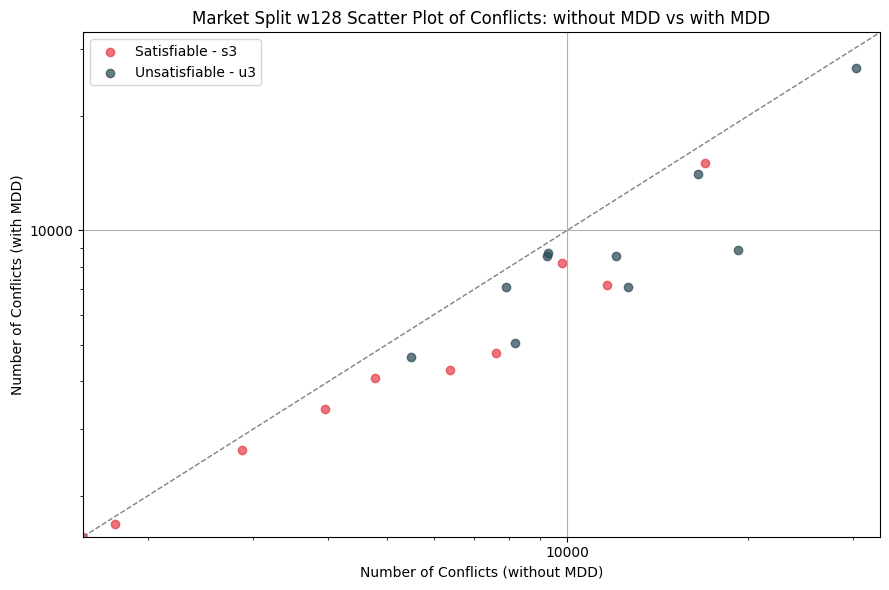

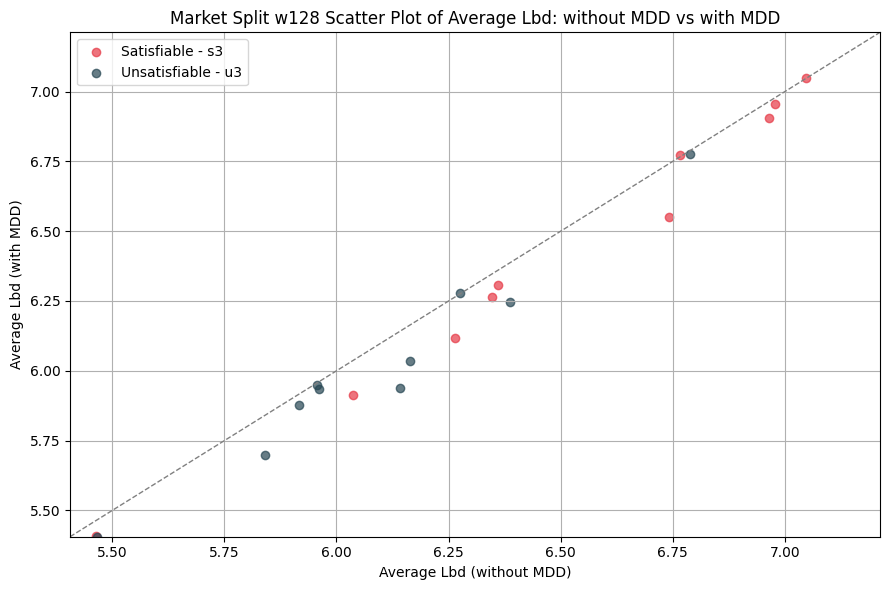

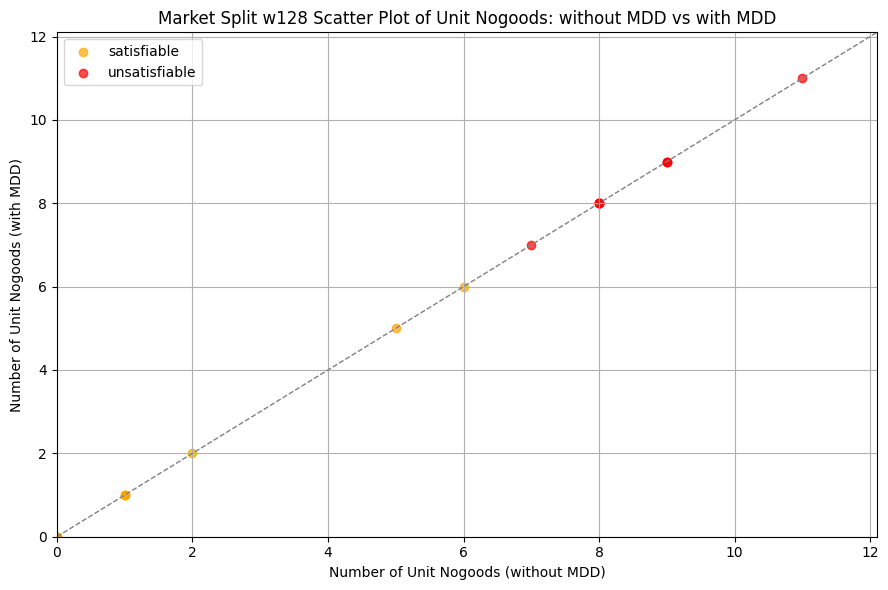

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w128


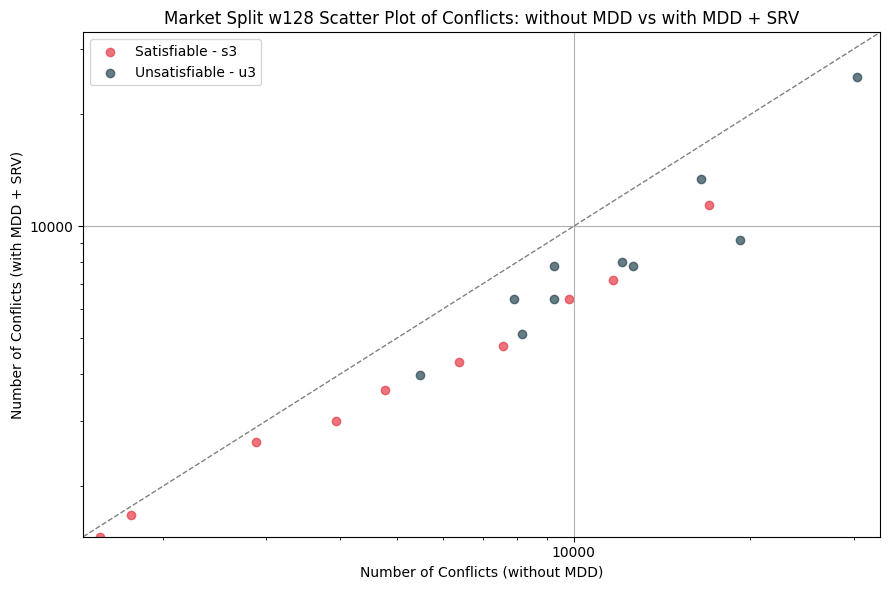

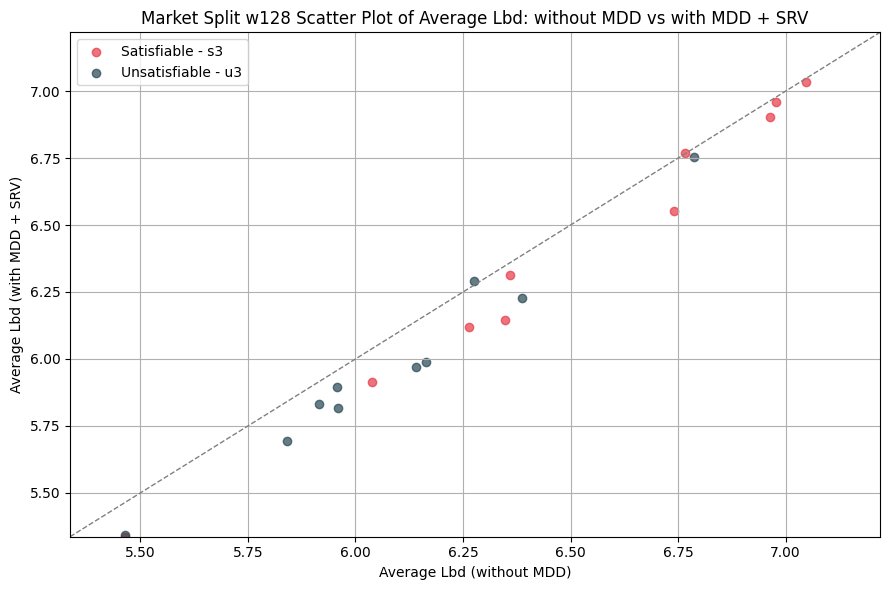

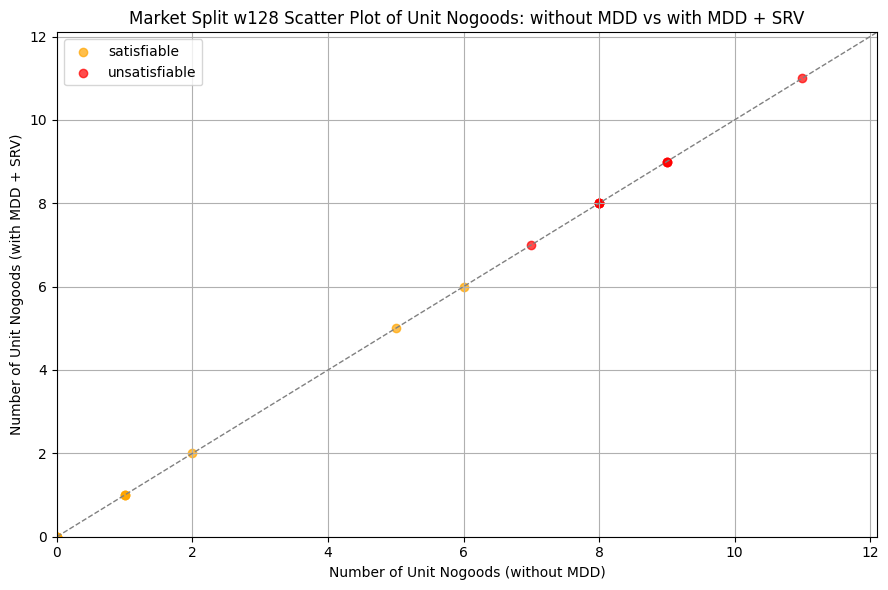

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w128


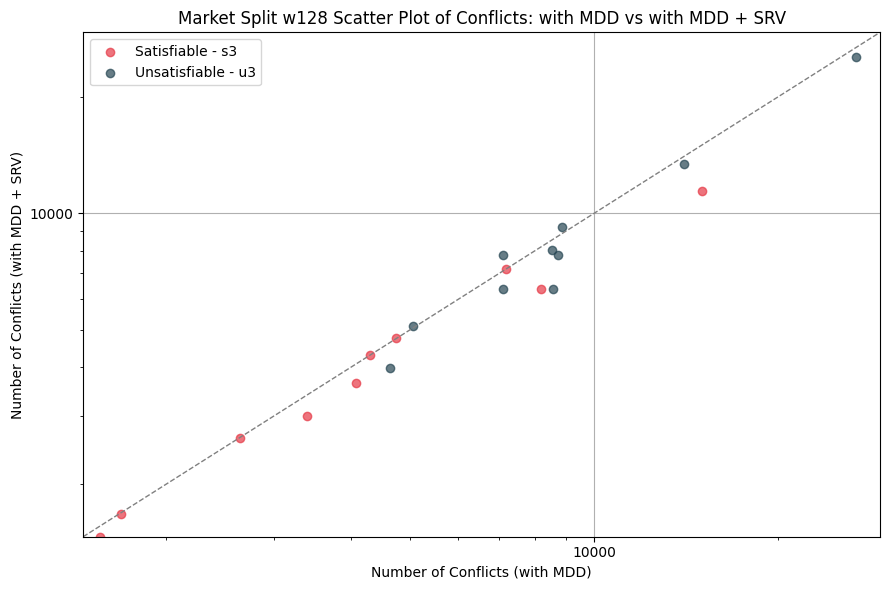

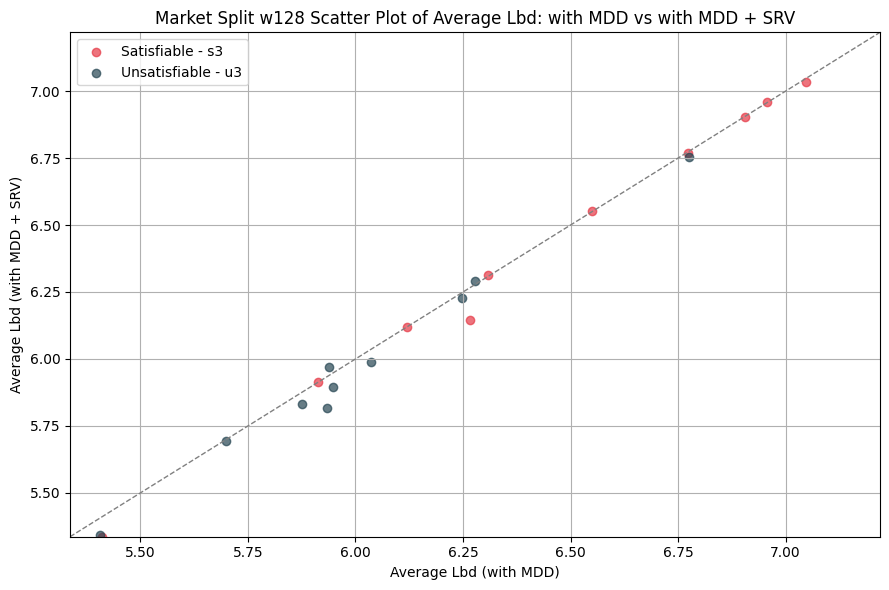

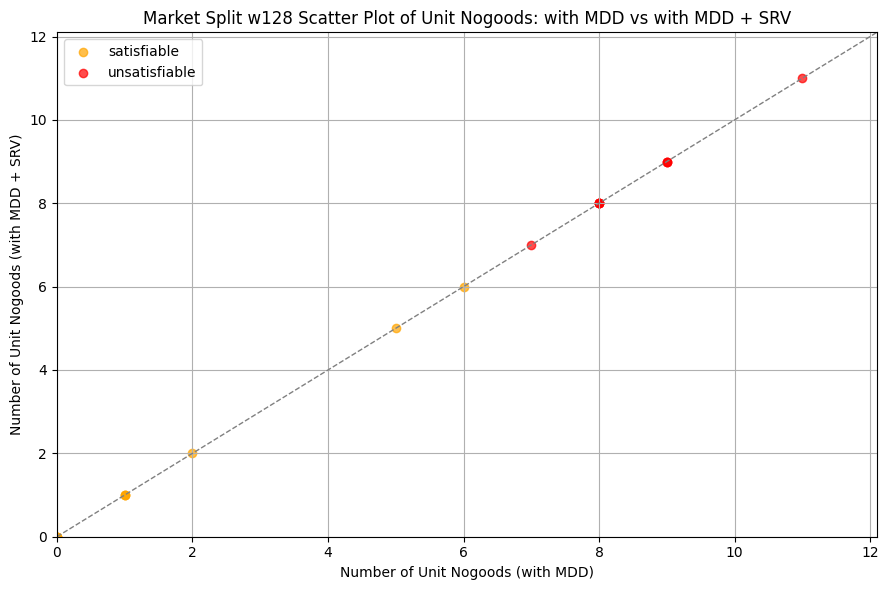

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split


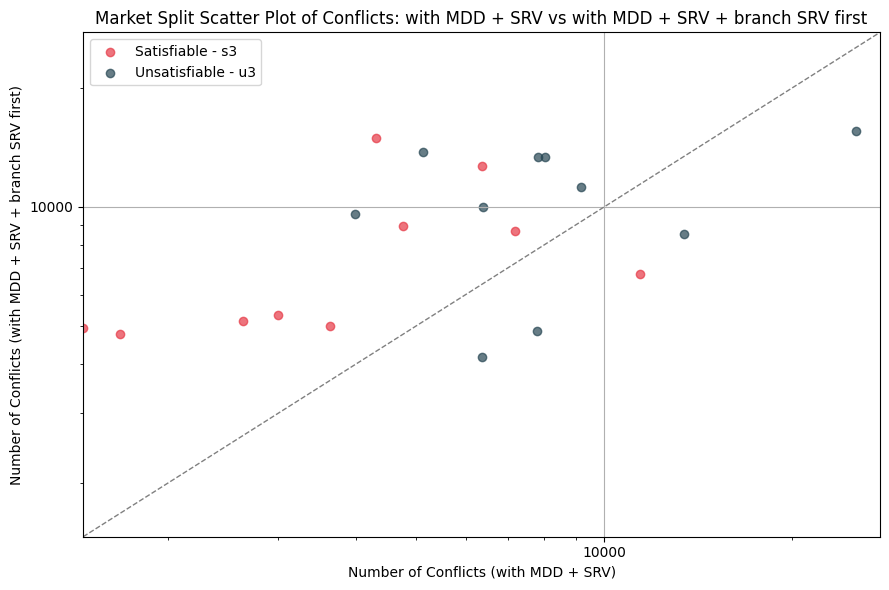

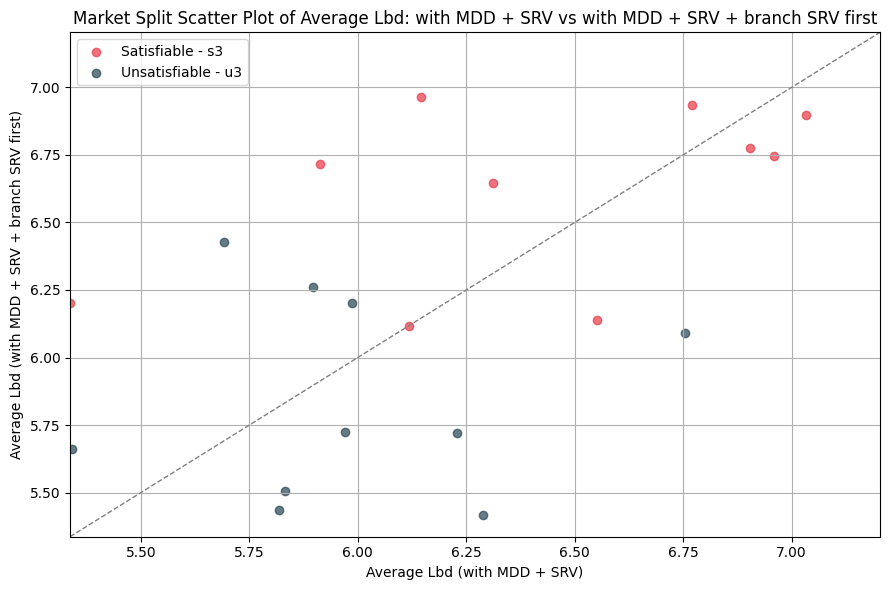

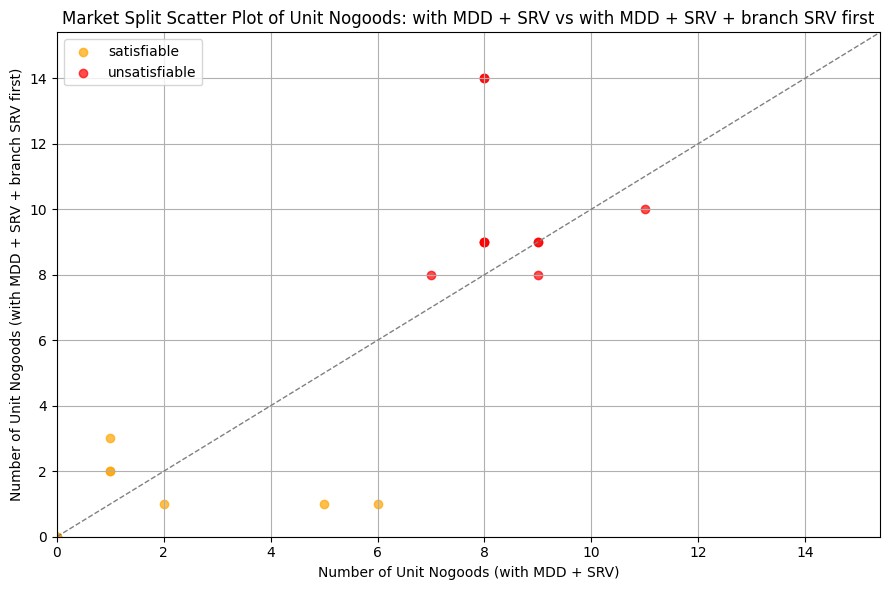

In [4]:
## Max width 128 - Market Split
file_128 = 'experiment_1_maxwidth_128/marketsplit_dd_disabled.csv'
file_128_with_mdd = 'experiment_1_maxwidth_128/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd,'without MDD', 'with MDD', 'Market Split w128', (9,6))
file_128 = 'experiment_1_maxwidth_128/marketsplit_dd_disabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w128', (9,6))
file_128_with_mdd = 'experiment_1_maxwidth_128/marketsplit_dd_enabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd, file_128_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w128', (9,6))
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
file_128_with_mdd_srv_branchfirst = 'experiment_srv_branch_first_w128/marketsplit_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv, file_128_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'Market Split', (9,6))

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

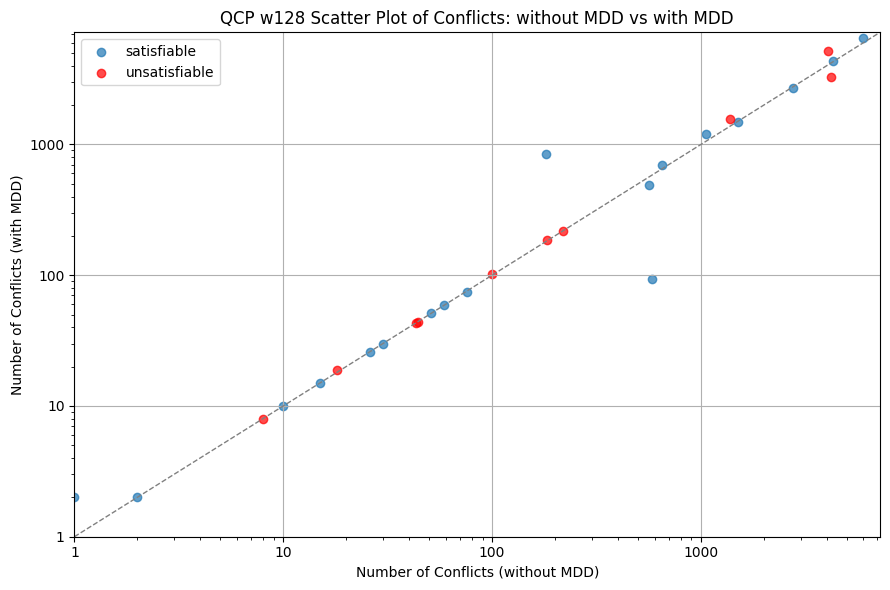

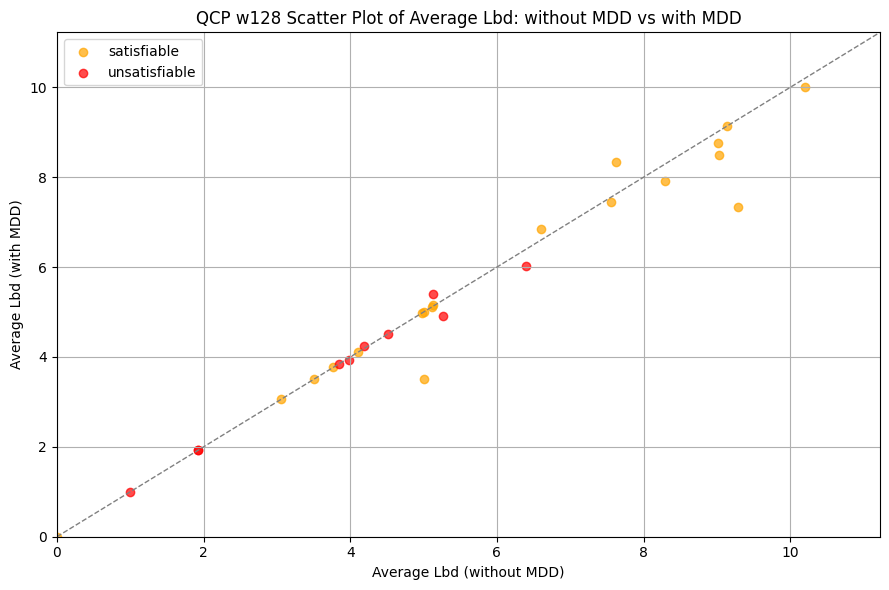

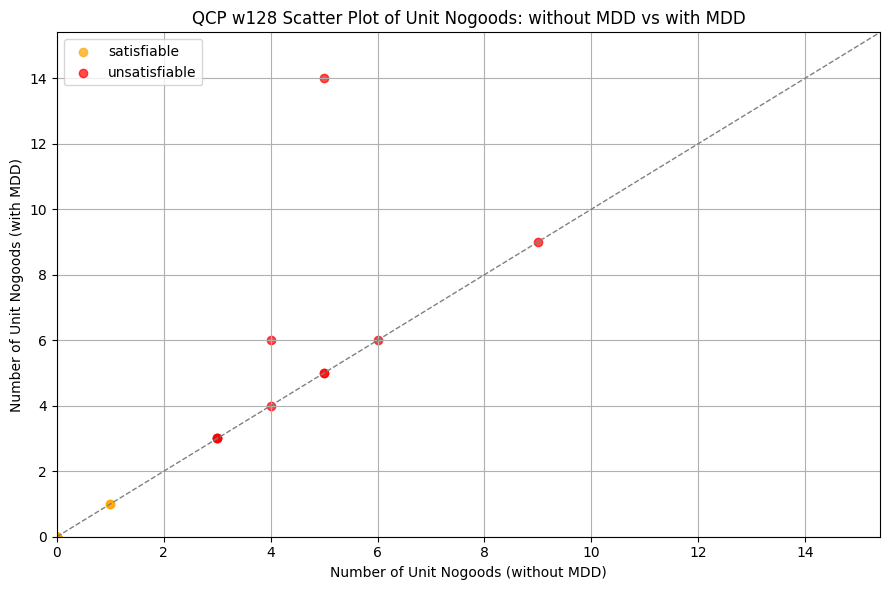

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

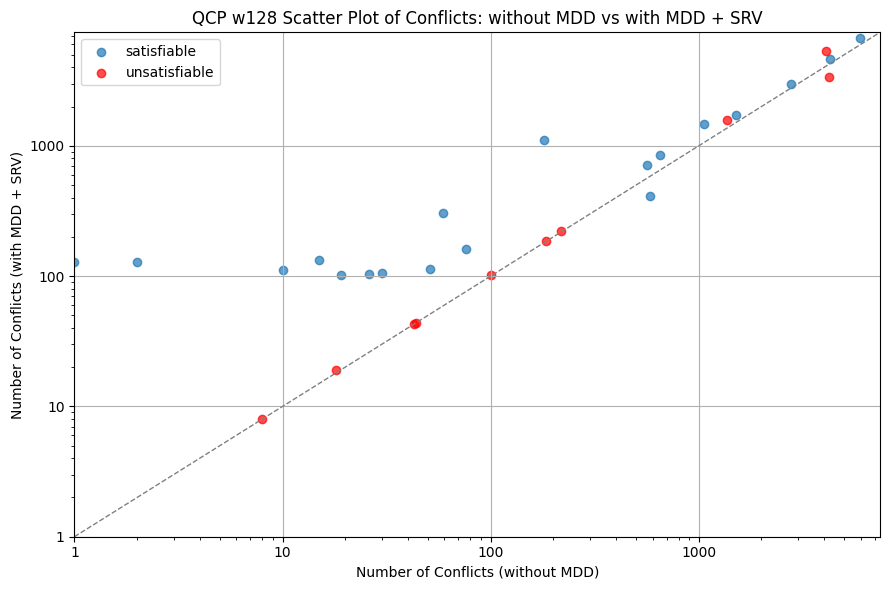

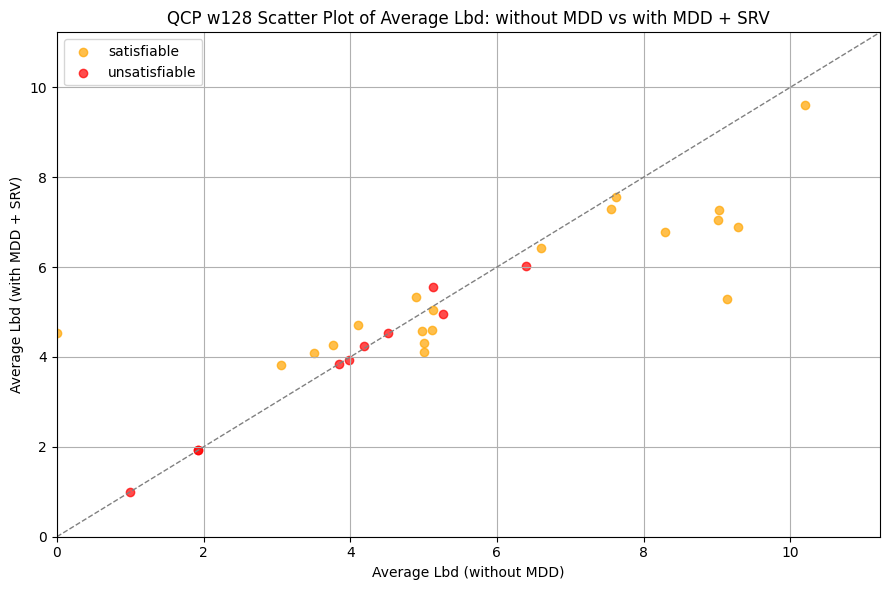

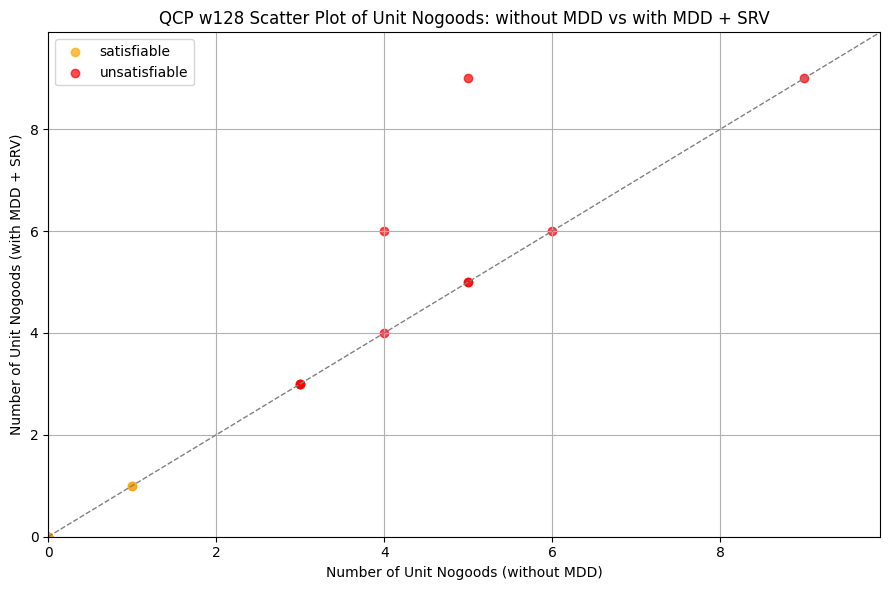

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-

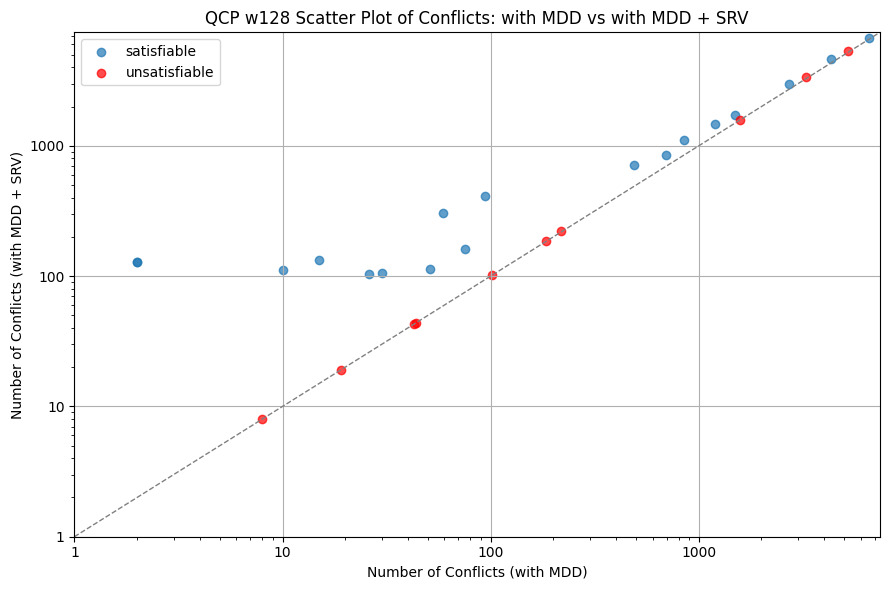

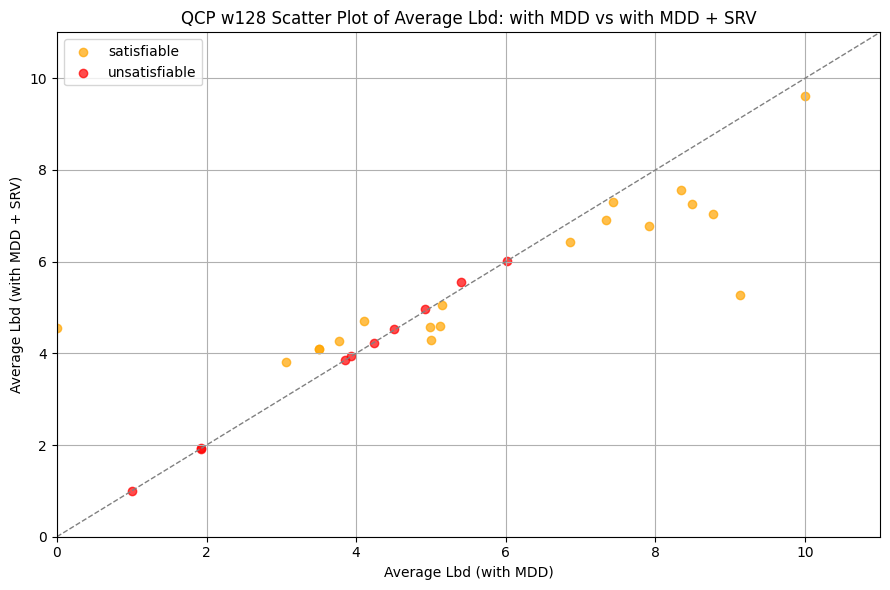

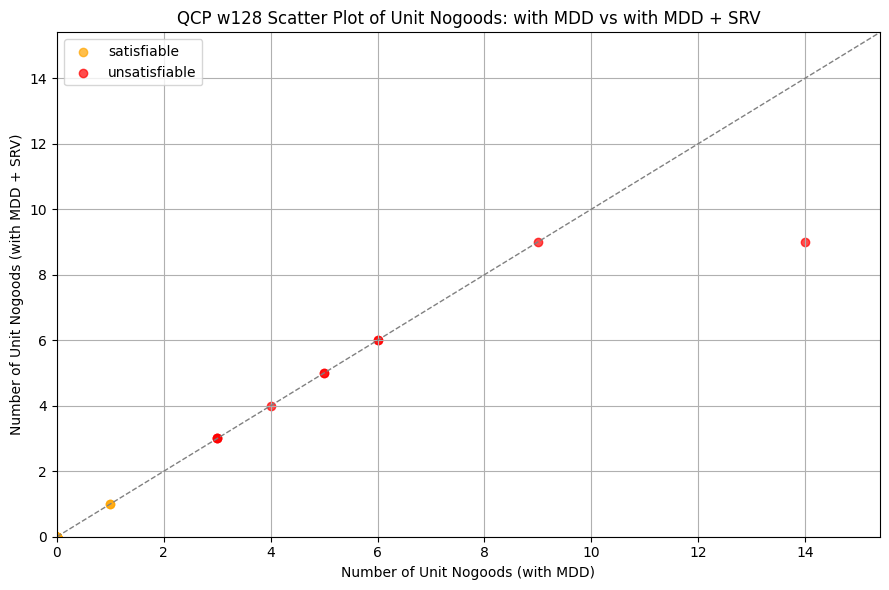

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

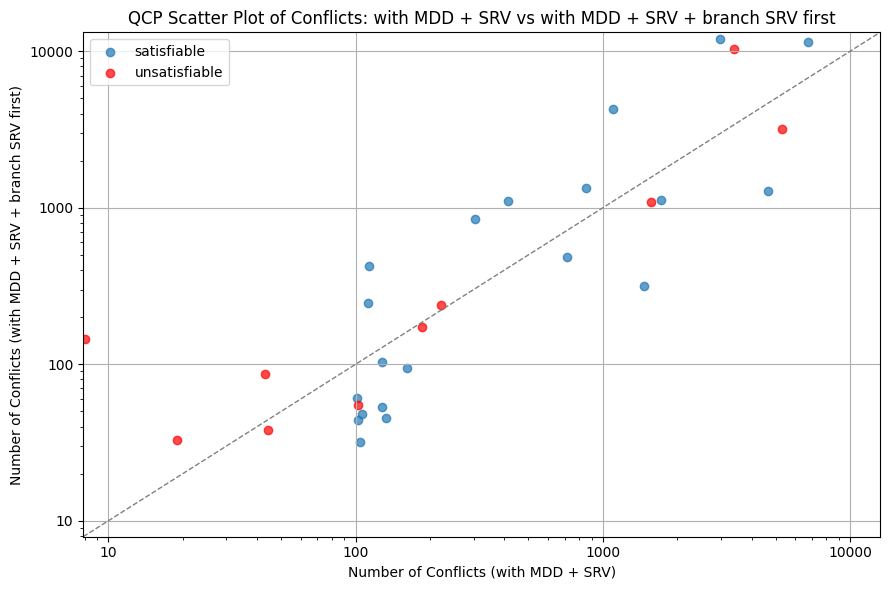

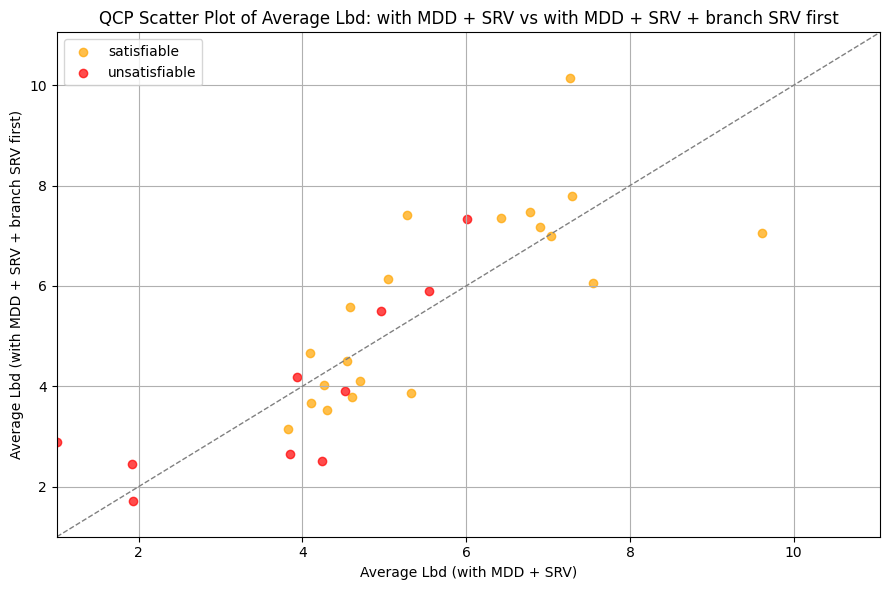

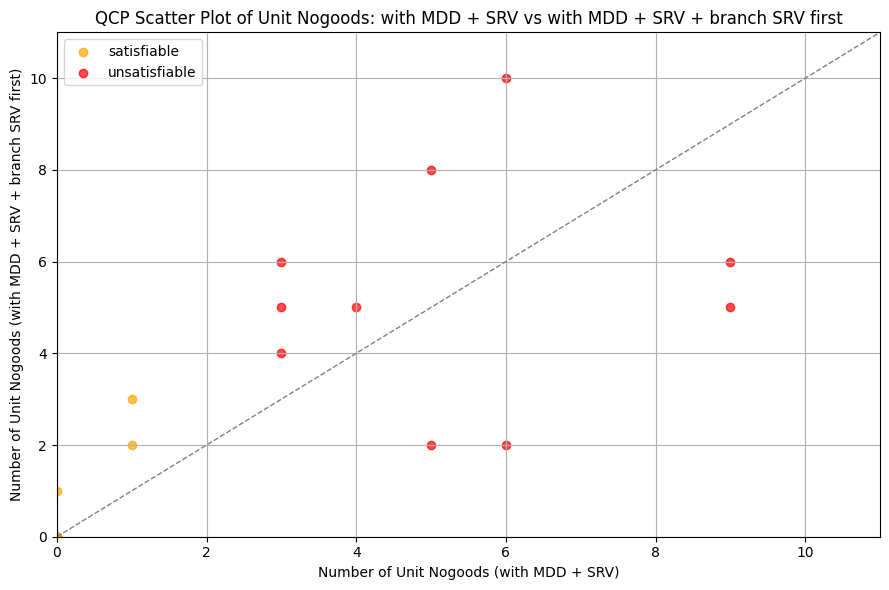

In [5]:
## Max width 128 - QCP
file_128 = 'experiment_1_maxwidth_128/qcp_disabled.csv'
file_128_with_mdd = 'experiment_1_maxwidth_128/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd,'without MDD', 'with MDD', 'QCP w128', (9,6))
file_128 = 'experiment_1_maxwidth_128/qcp_disabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w128', (9,6))
file_128_with_mdd = 'experiment_1_maxwidth_128/qcp_dd_enabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd, file_128_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w128', (9,6))
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
file_128_with_mdd_srv_branchfirst = 'experiment_srv_branch_first_w128/qcp_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv, file_128_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'QCP', (9,6))

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048


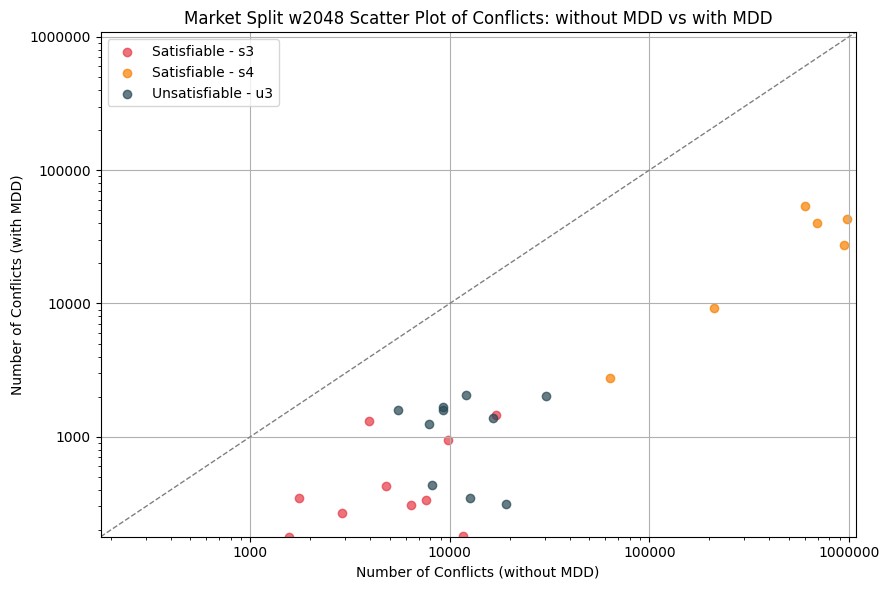

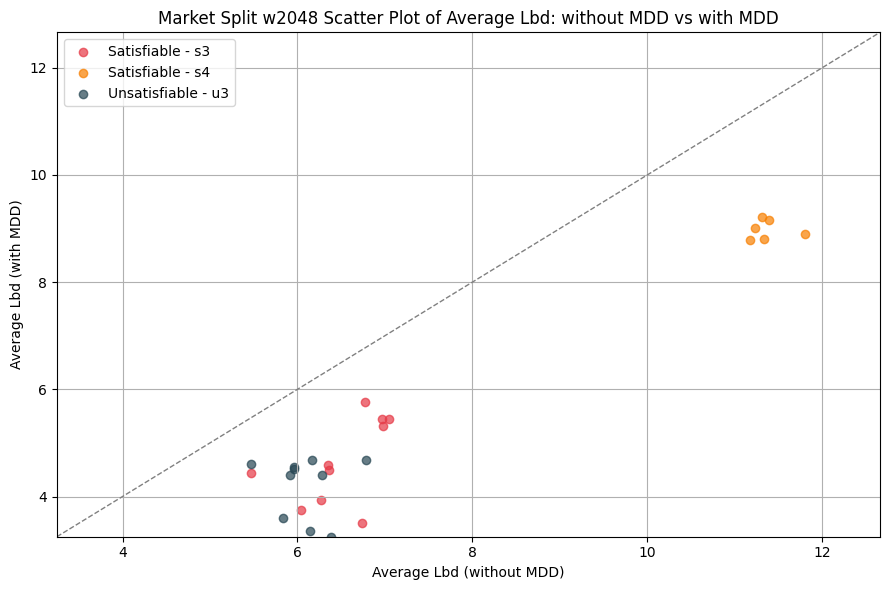

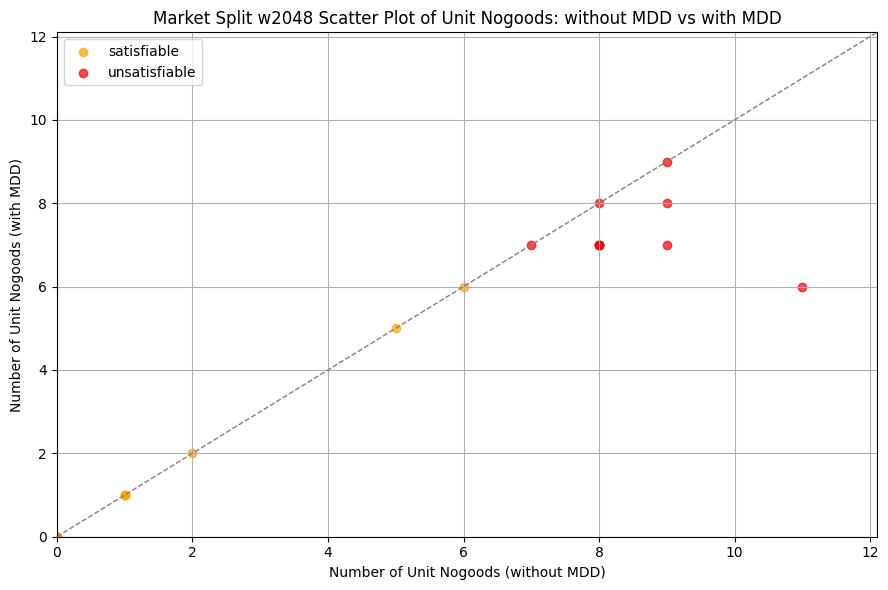

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048


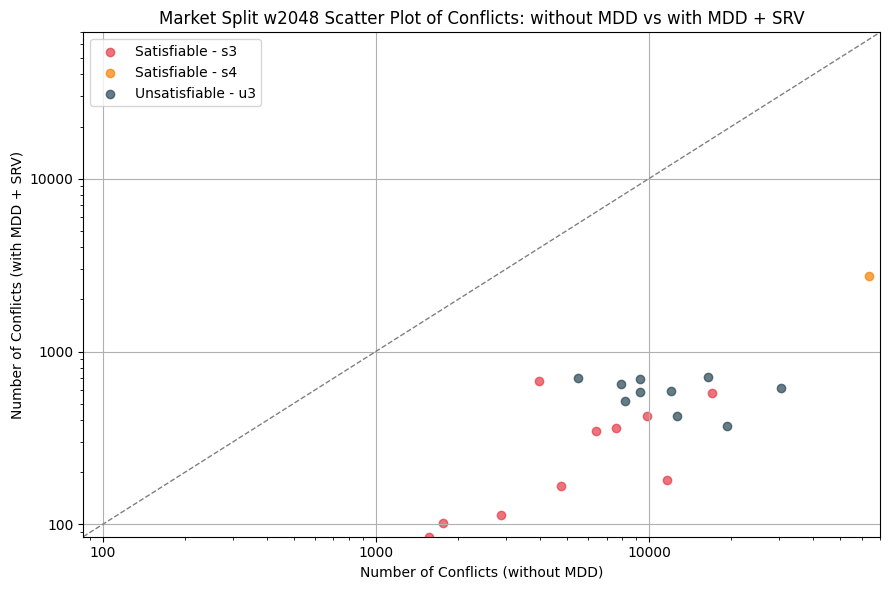

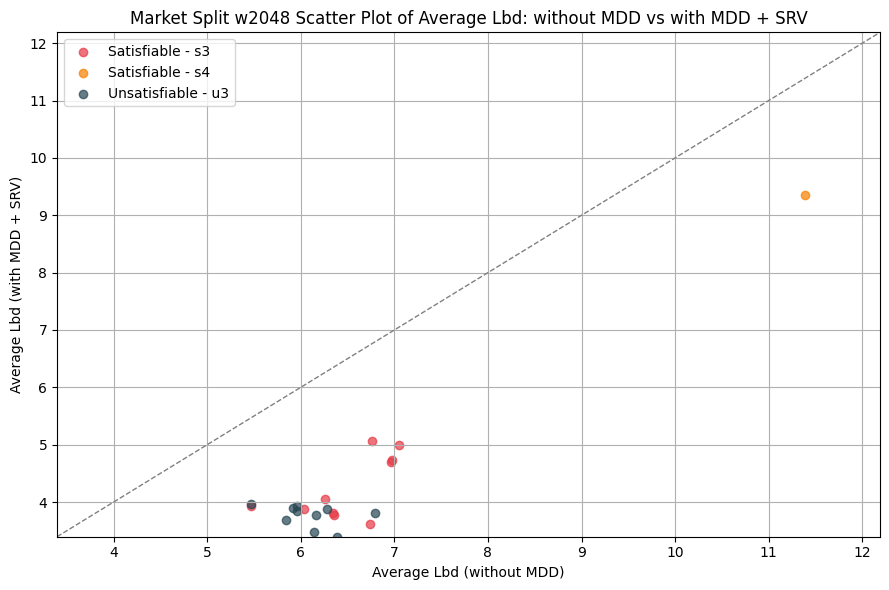

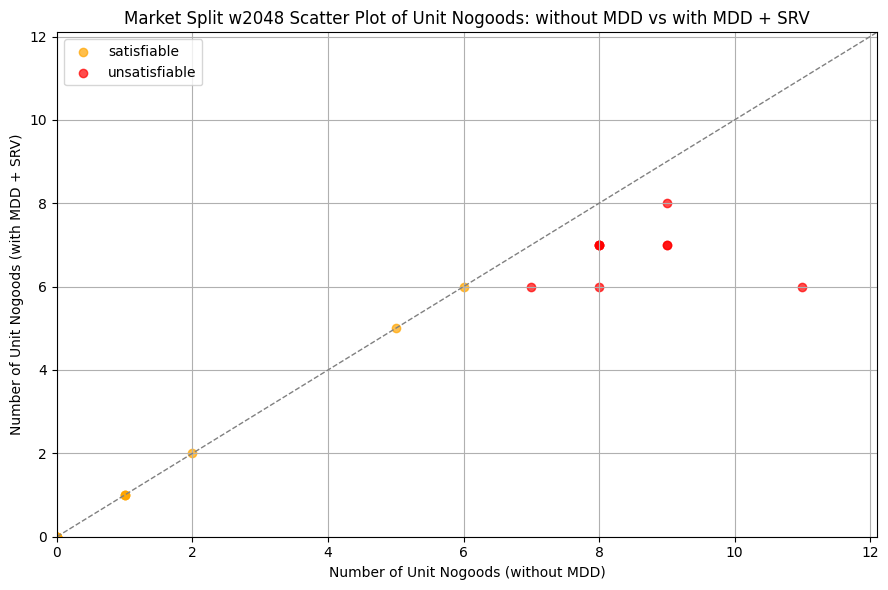

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048


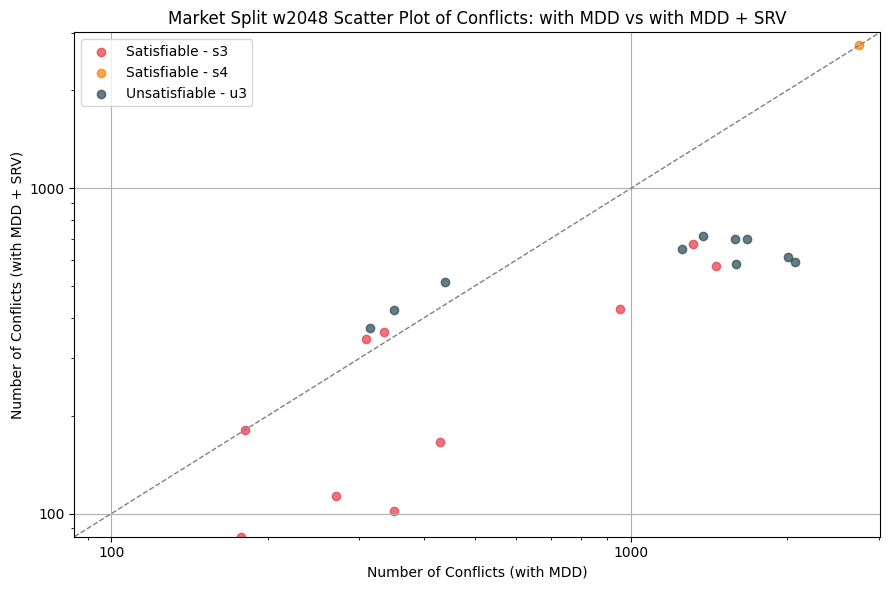

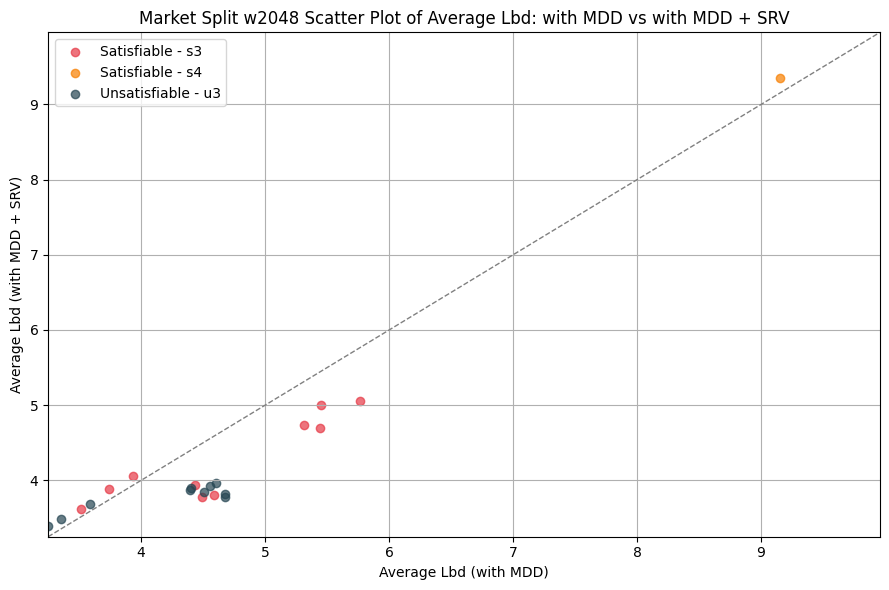

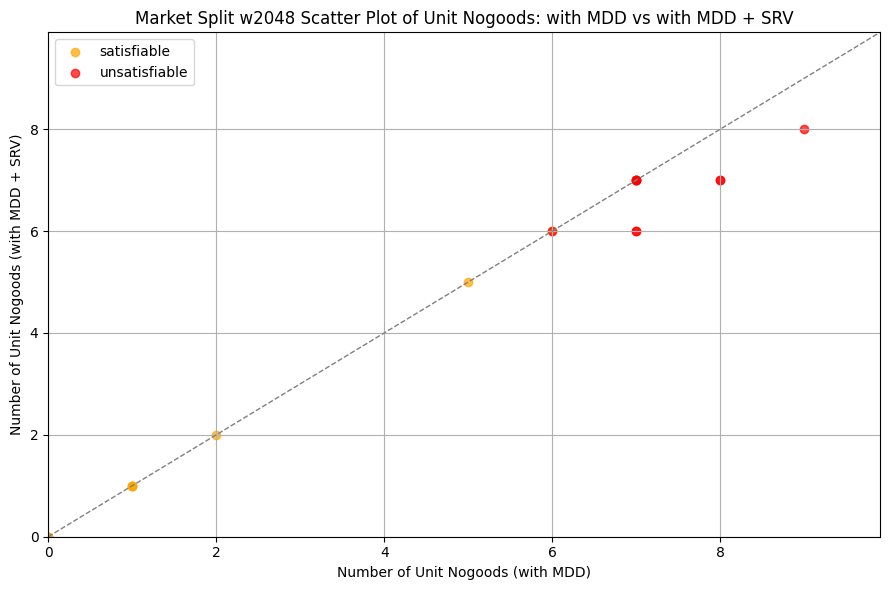

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split


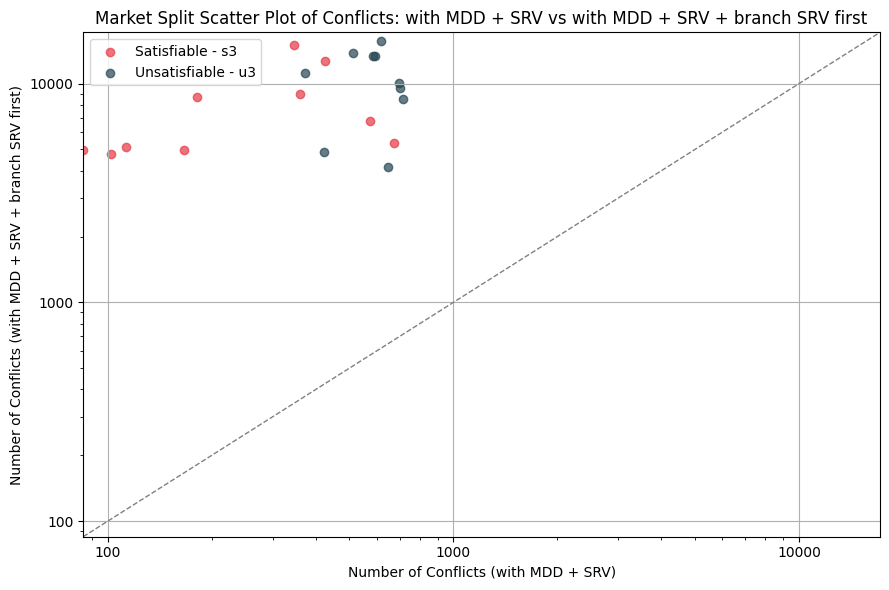

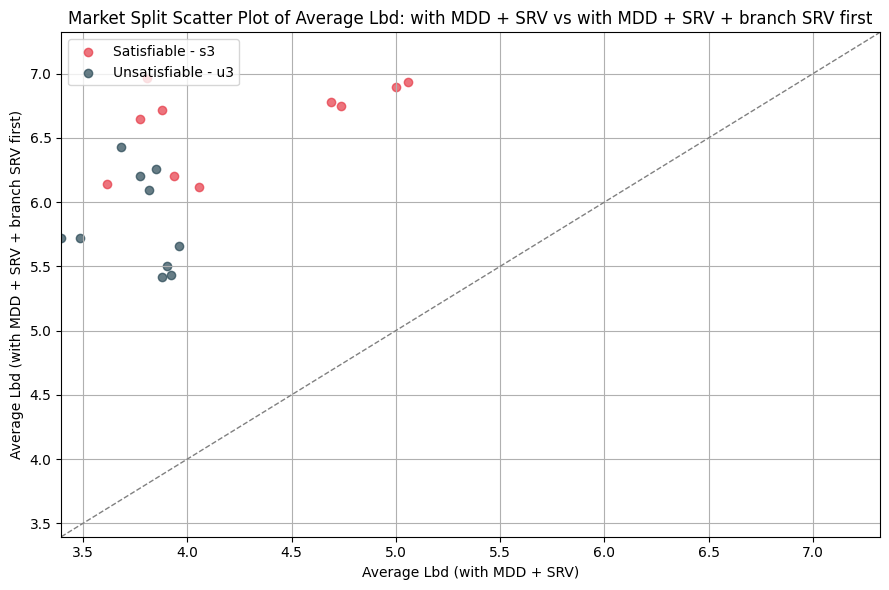

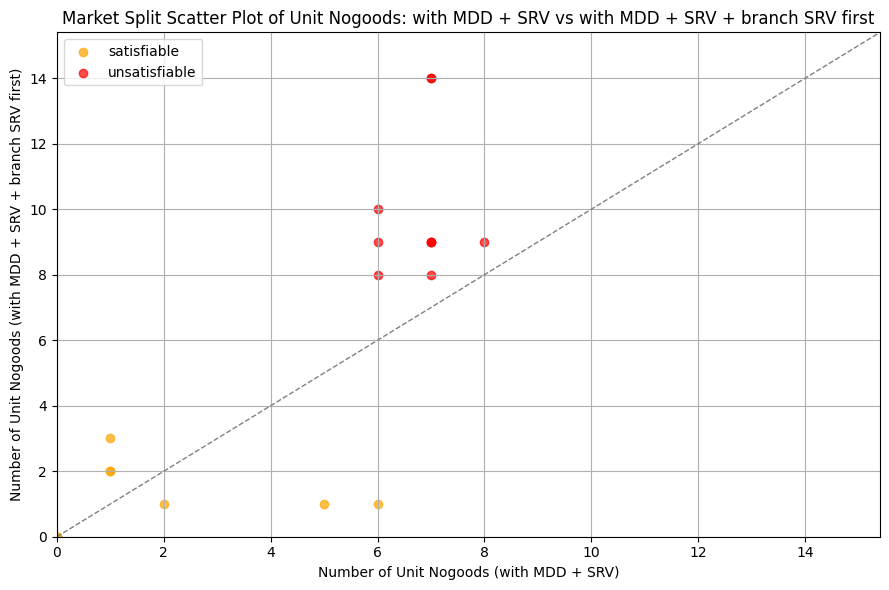

In [6]:
## Max width 2048 - Market Split
file_2048 = 'experiment_1_maxwidth_2048/marketsplit_dd_disabled.csv'
file_2048_with_mdd = 'experiment_1_maxwidth_2048/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'Market Split w2048', (9,6))
file_2048 = 'experiment_1_maxwidth_2048/marketsplit_dd_disabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w2048', (9,6))
file_2048_with_mdd = 'experiment_1_maxwidth_2048/marketsplit_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w2048', (9,6))
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_srv_branch_first_w2048/marketsplit_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'Market Split', (9,6))

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

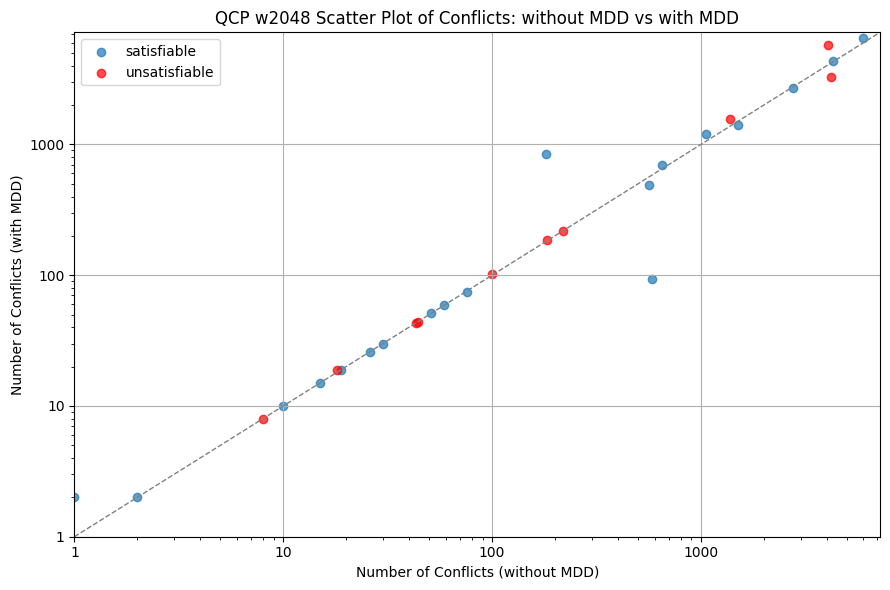

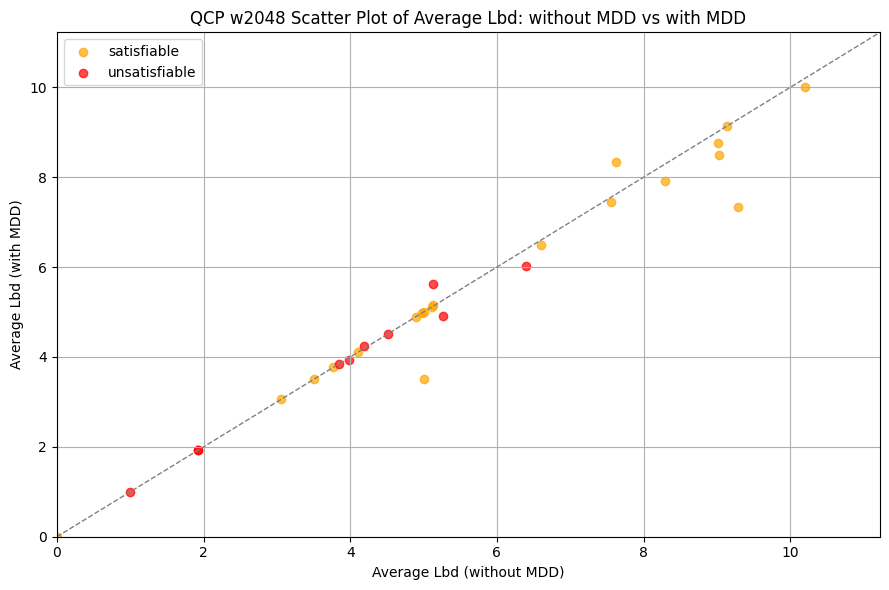

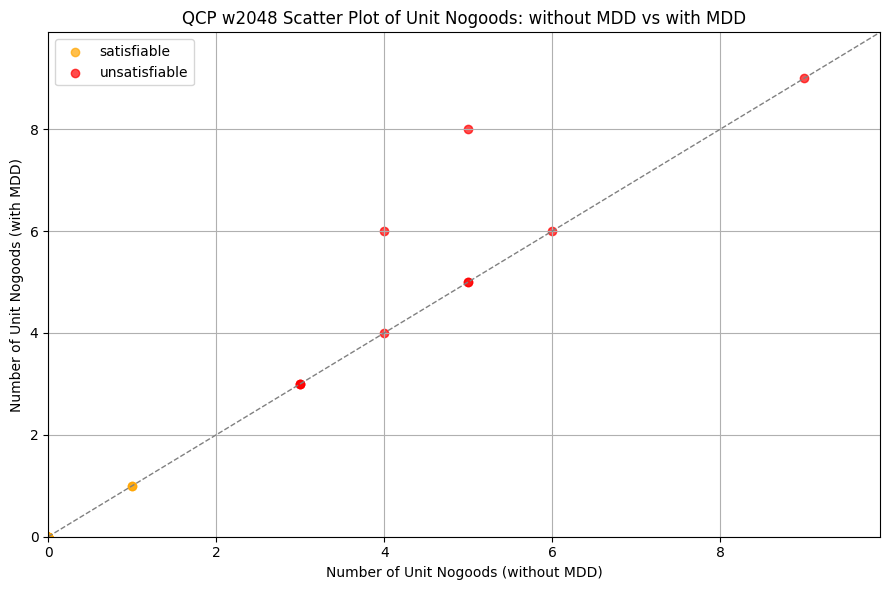

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

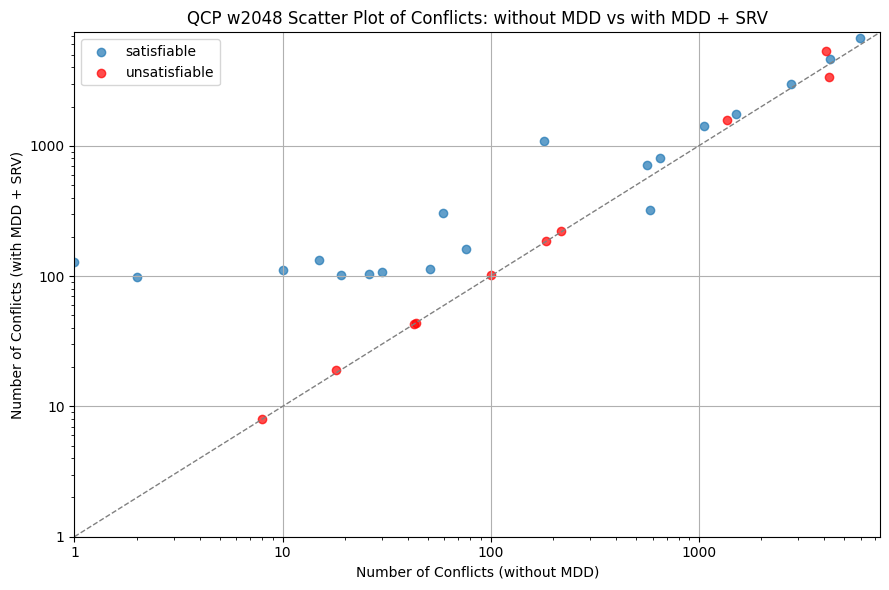

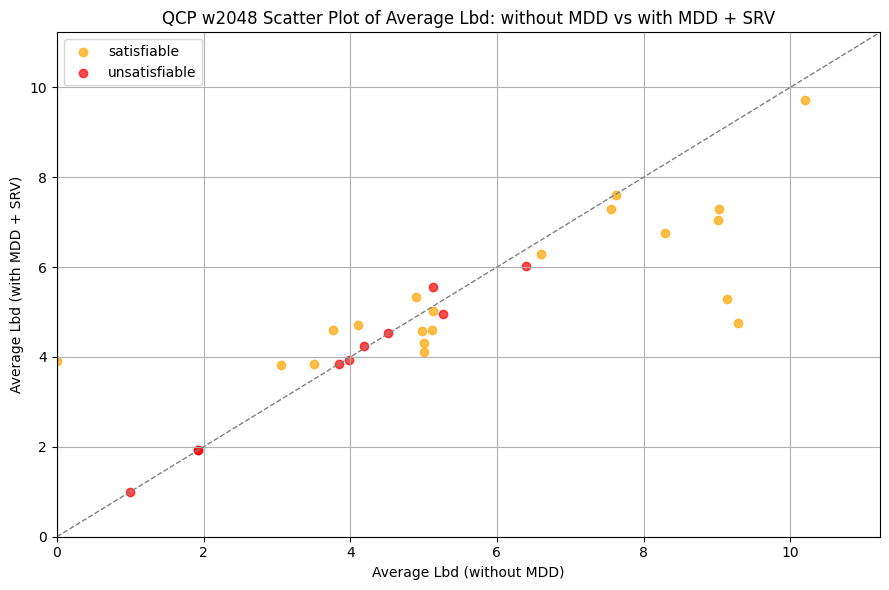

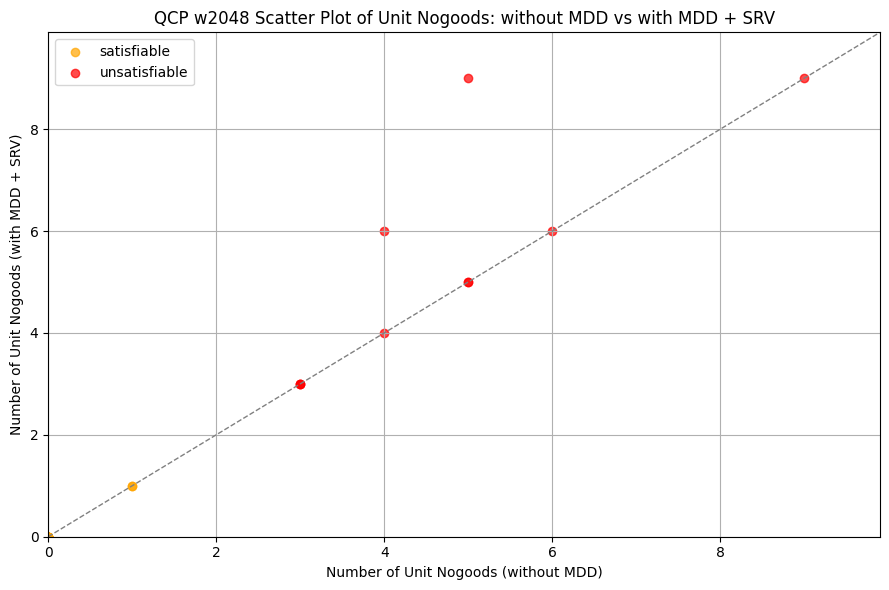

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

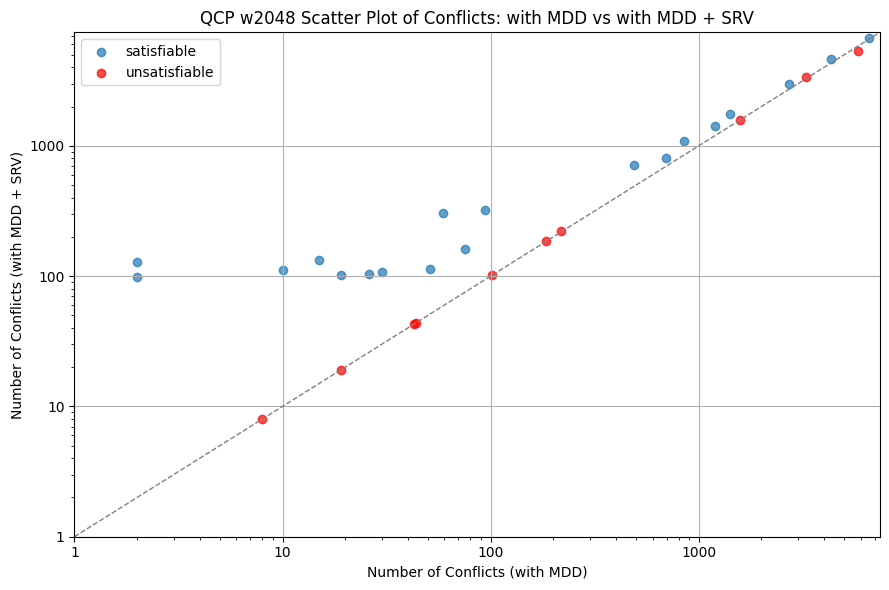

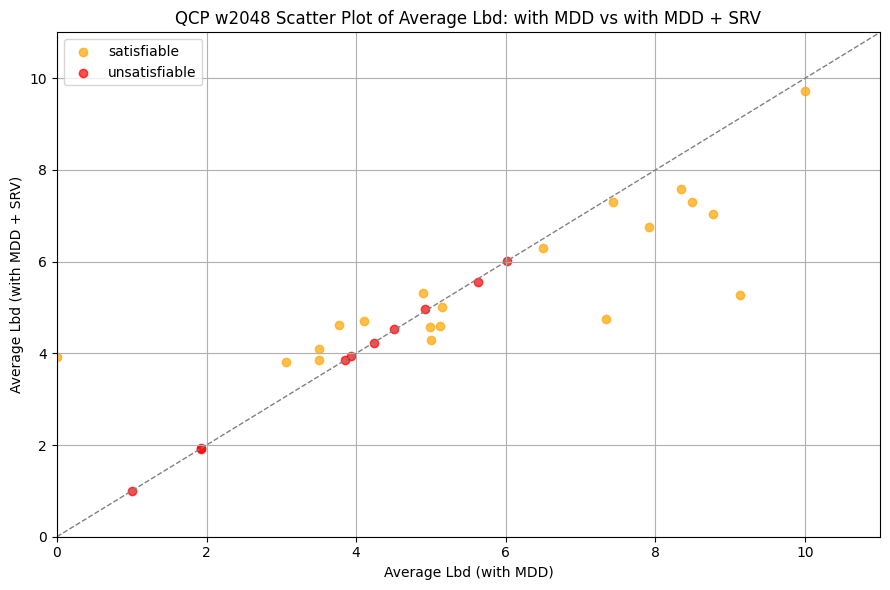

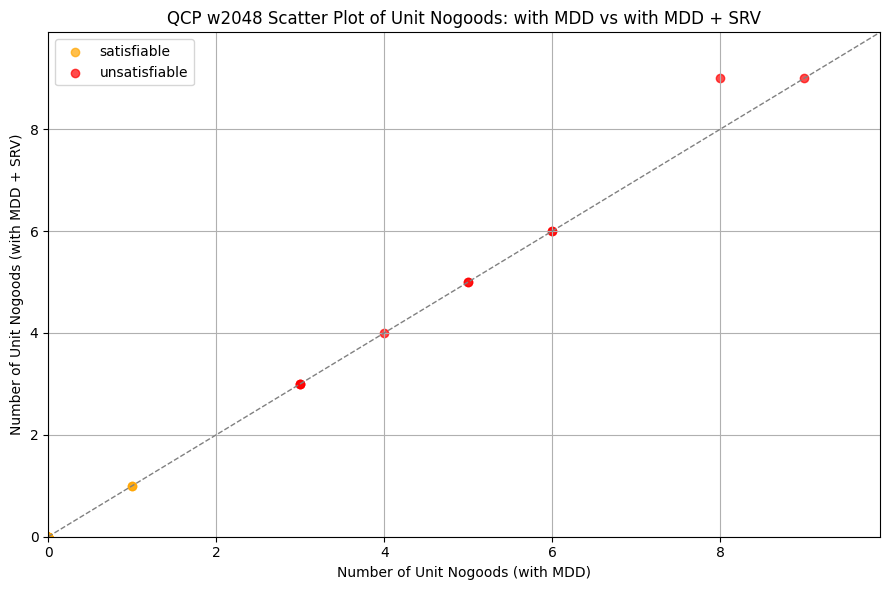

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

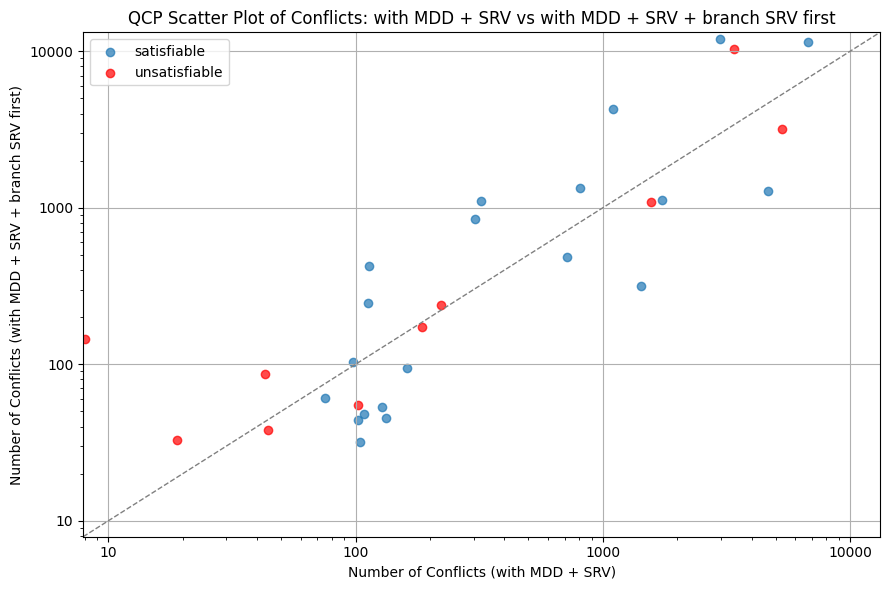

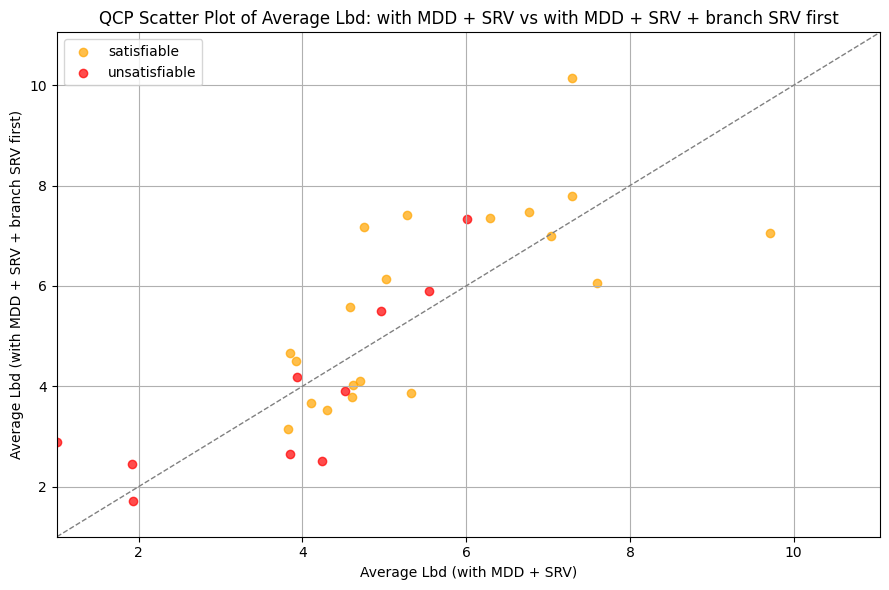

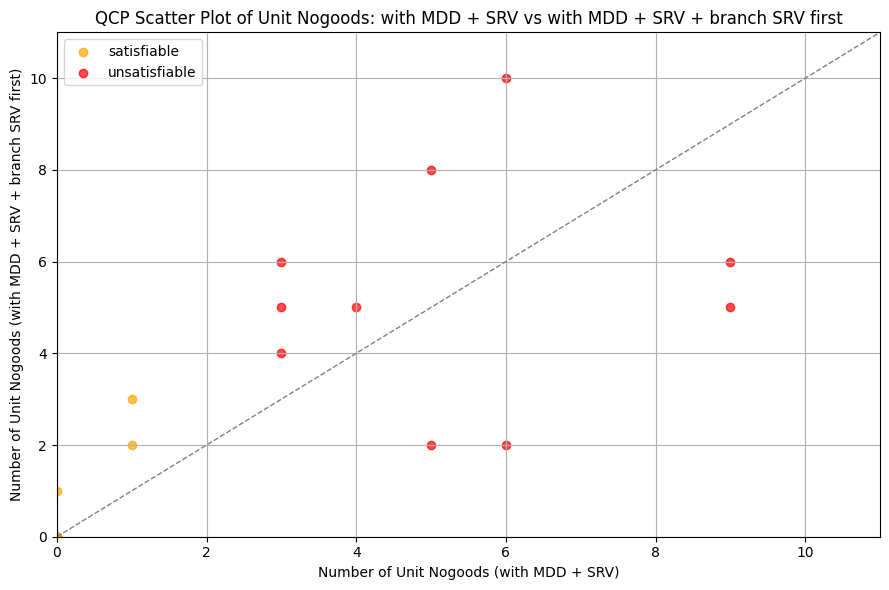

In [7]:
## Max width 2048 - QCP
file_2048 = 'experiment_1_maxwidth_2048/qcp_disabled.csv'
file_2048_with_mdd = 'experiment_1_maxwidth_2048/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'QCP w2048', (9,6))
file_2048 = 'experiment_1_maxwidth_2048/qcp_disabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w2048', (9,6))
file_2048_with_mdd = 'experiment_1_maxwidth_2048/qcp_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w2048', (9,6))
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_srv_branch_first_w2048/qcp_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'QCP', (9,6))

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-05', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w512 1hr


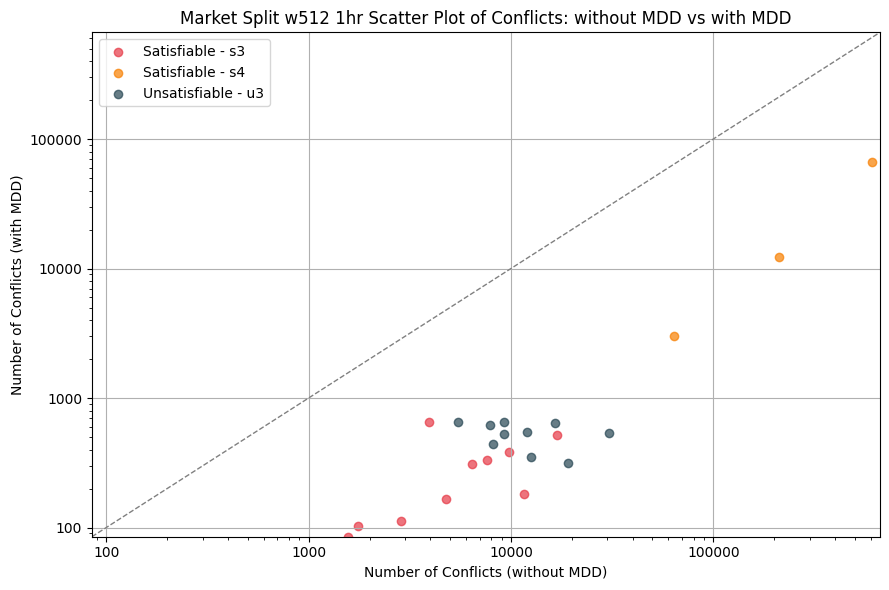

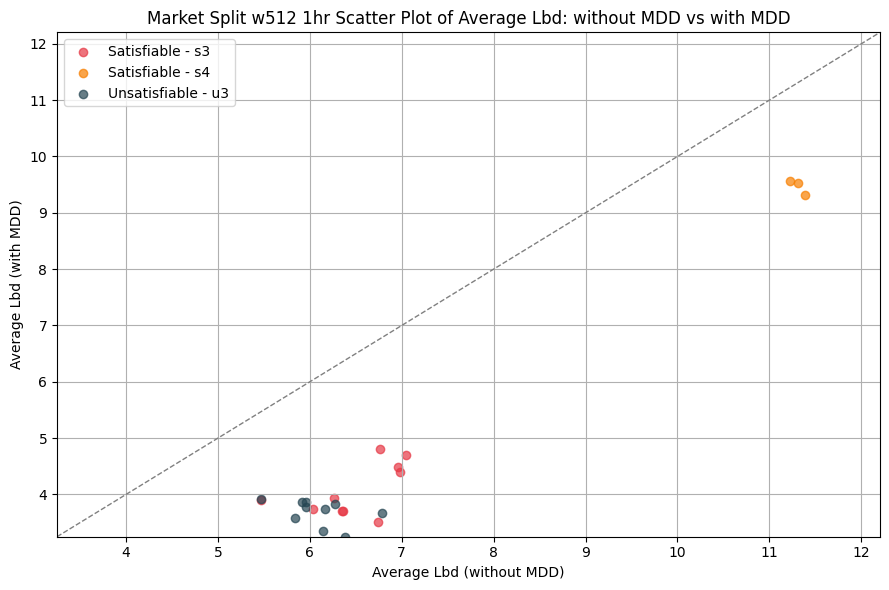

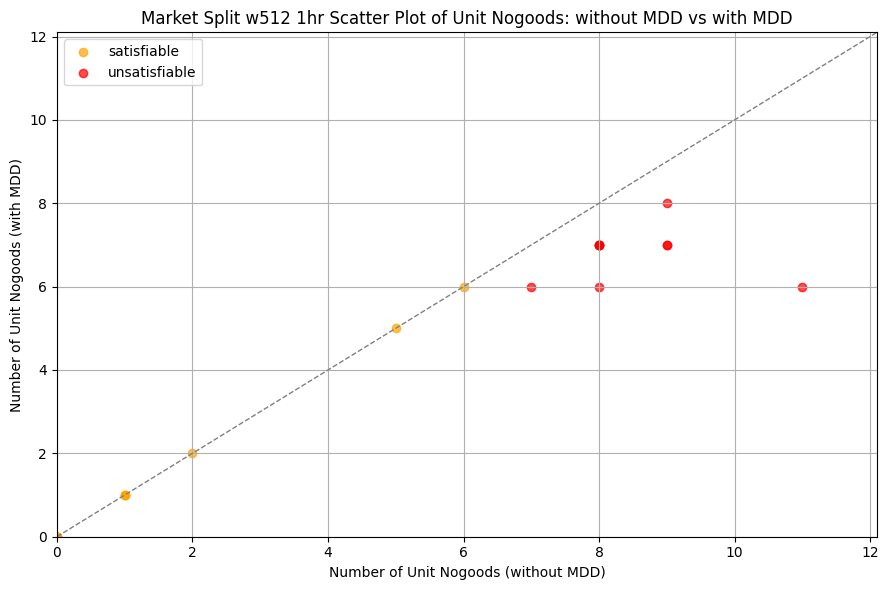

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w512 1hr


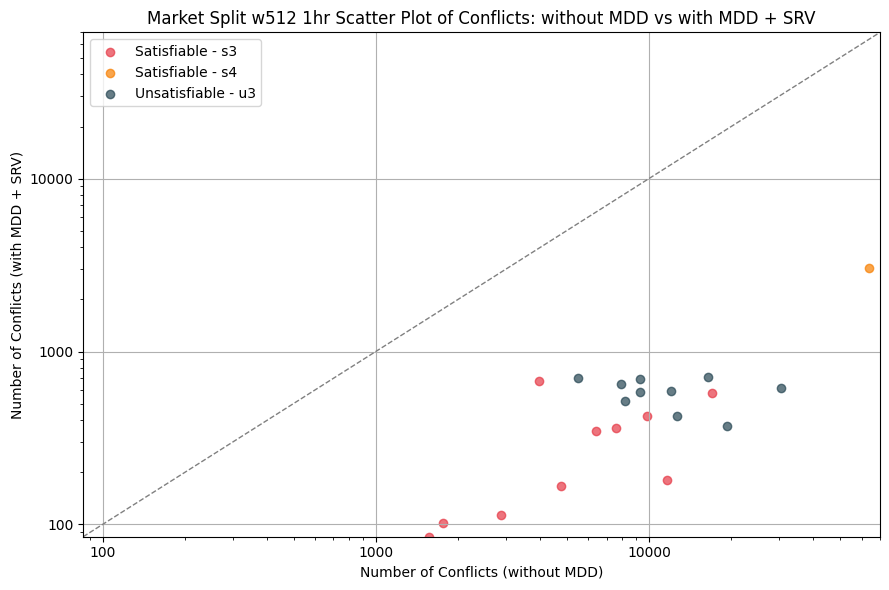

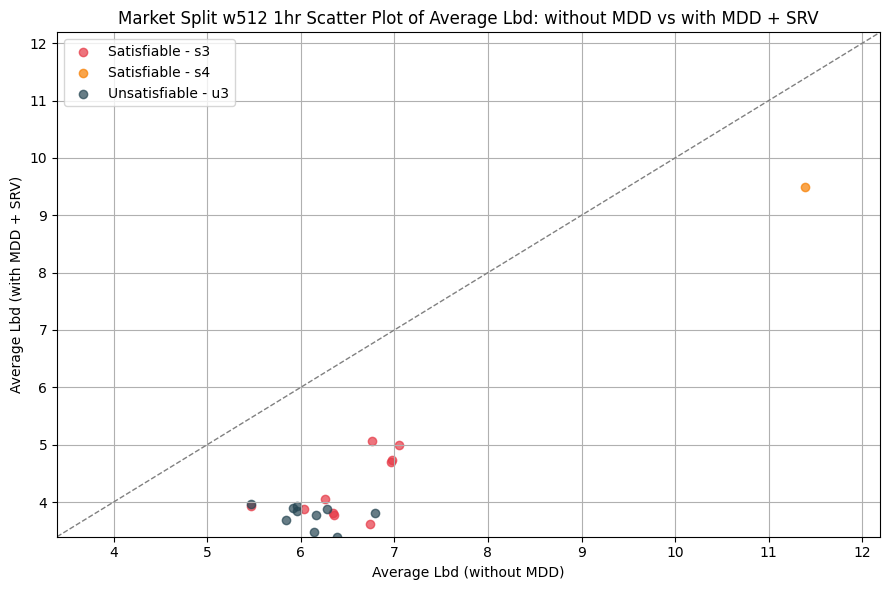

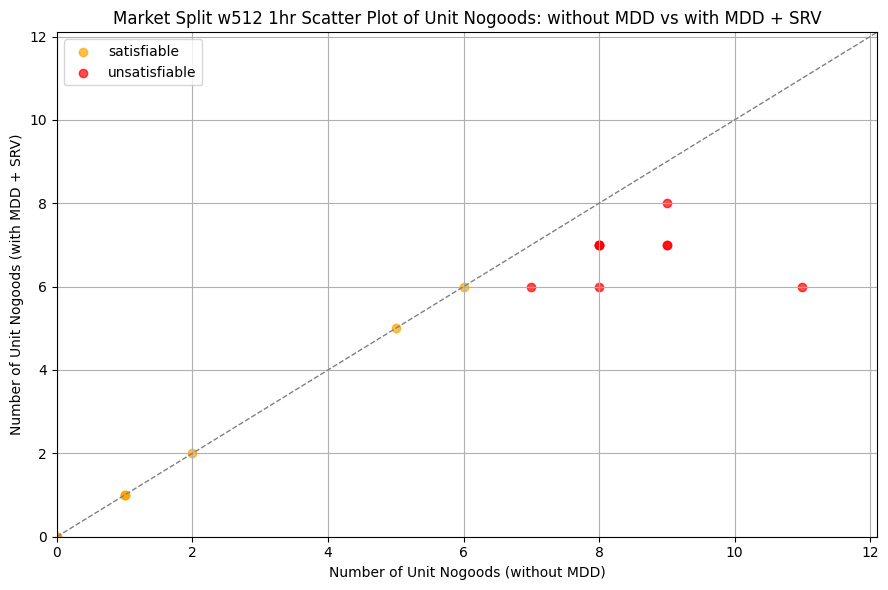

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-05', 's4-08', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w512 1hr


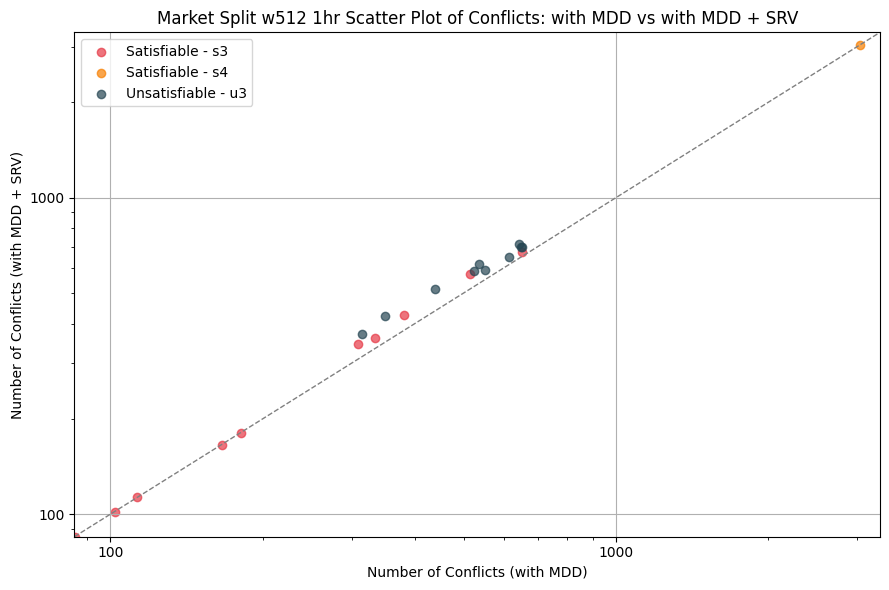

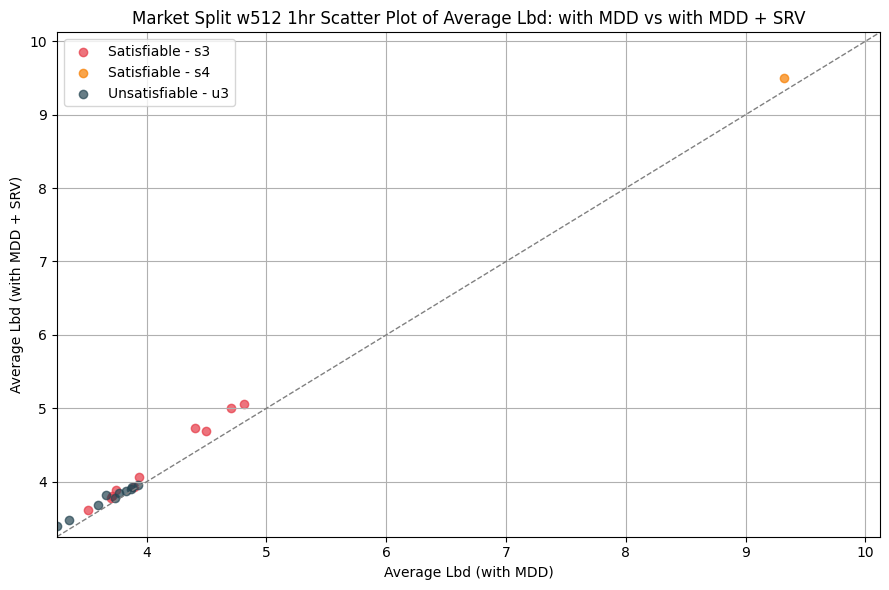

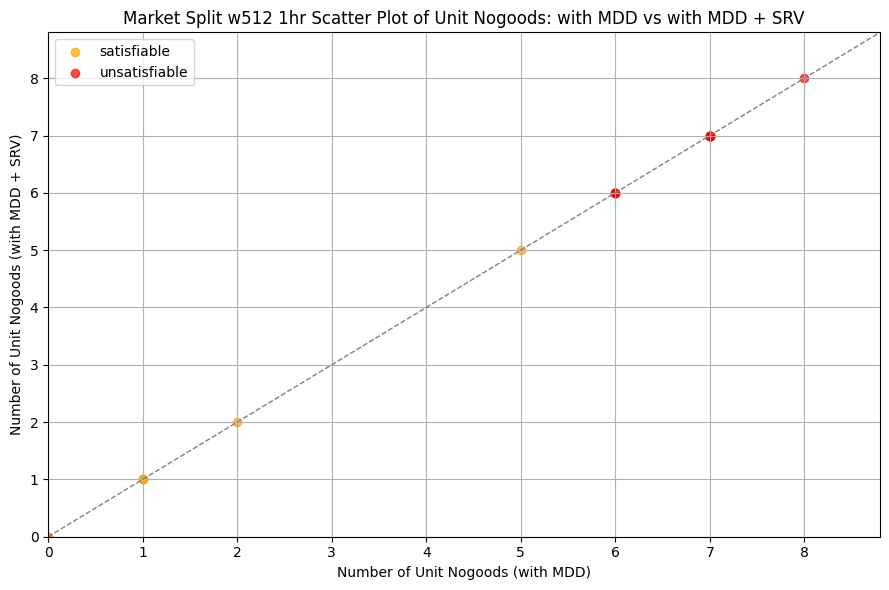

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w512 1hr


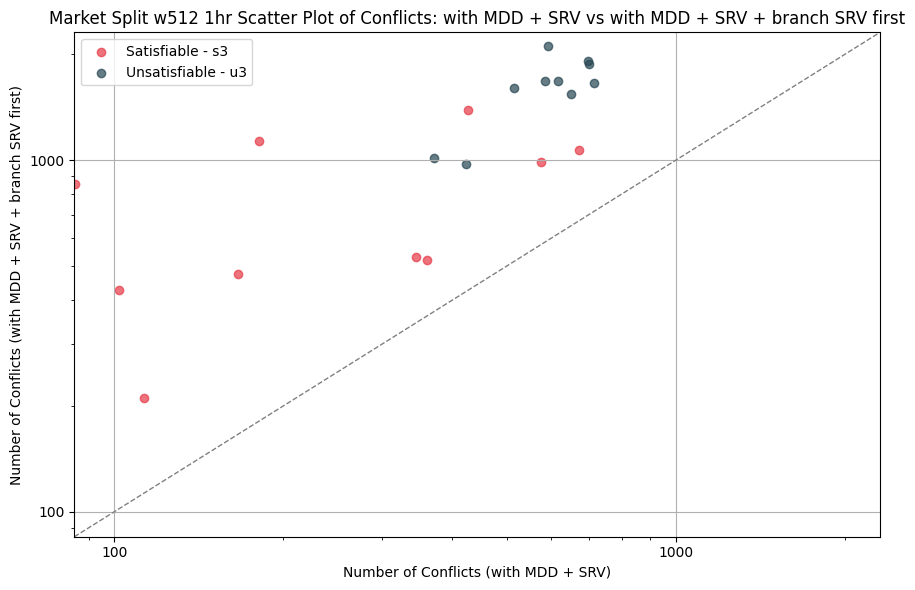

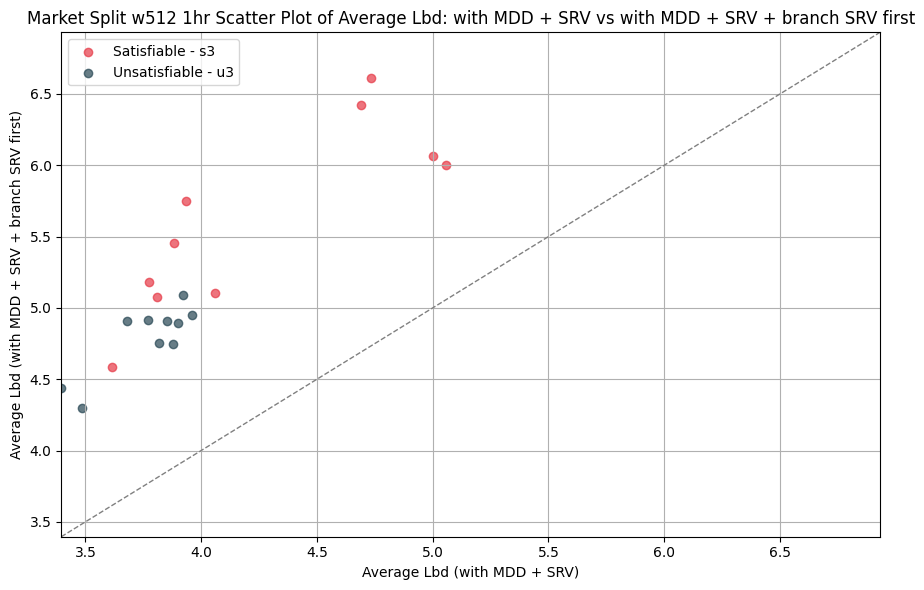

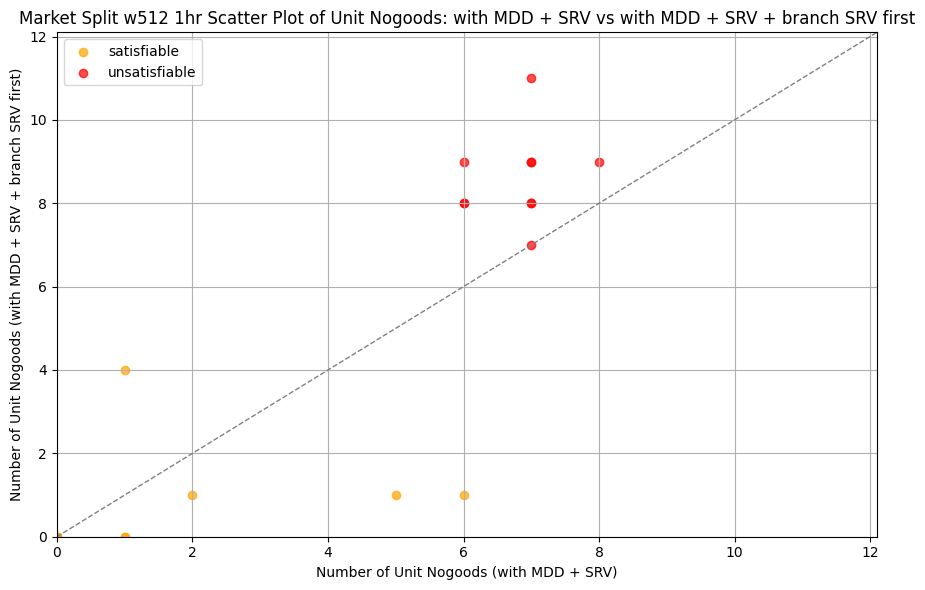

In [8]:
## Market Split w512 1hr run
file_2048 = 'experiment_w512_1hr/marketsplit_dd_disabled.csv'
file_2048_with_mdd = 'experiment_w512_1hr/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'Market Split w512 1hr', (9,6))
file_2048 = 'experiment_w512_1hr/marketsplit_dd_disabled.csv'
file_2048_with_mdd_srv = 'experiment_w512_1hr/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w512 1hr', (9,6))
file_2048_with_mdd = 'experiment_w512_1hr/marketsplit_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_w512_1hr/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w512 1hr', (9,6))
file_2048_with_mdd_srv = 'experiment_w512_1hr/marketsplit_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w512_1hr/marketsplit_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'Market Split w512 1hr', (9,6))

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048 1hr


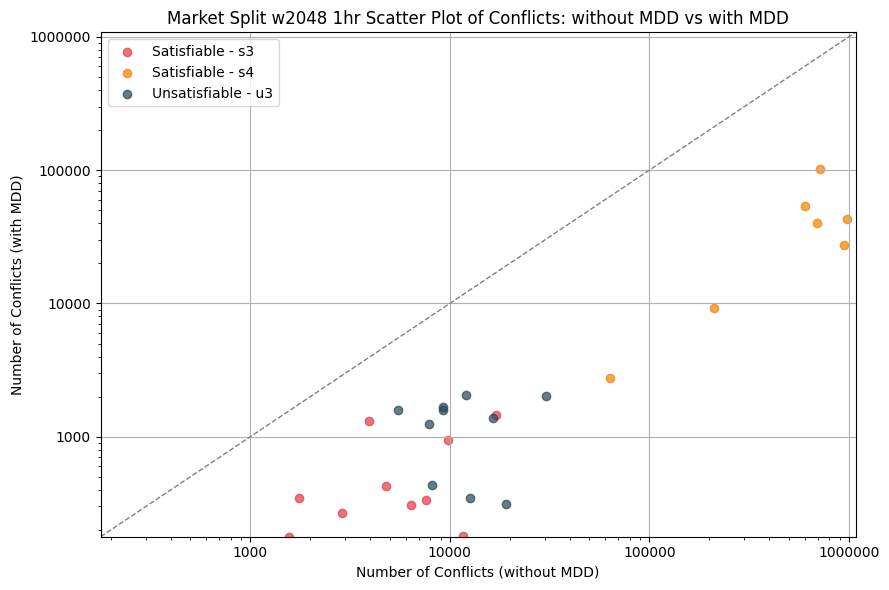

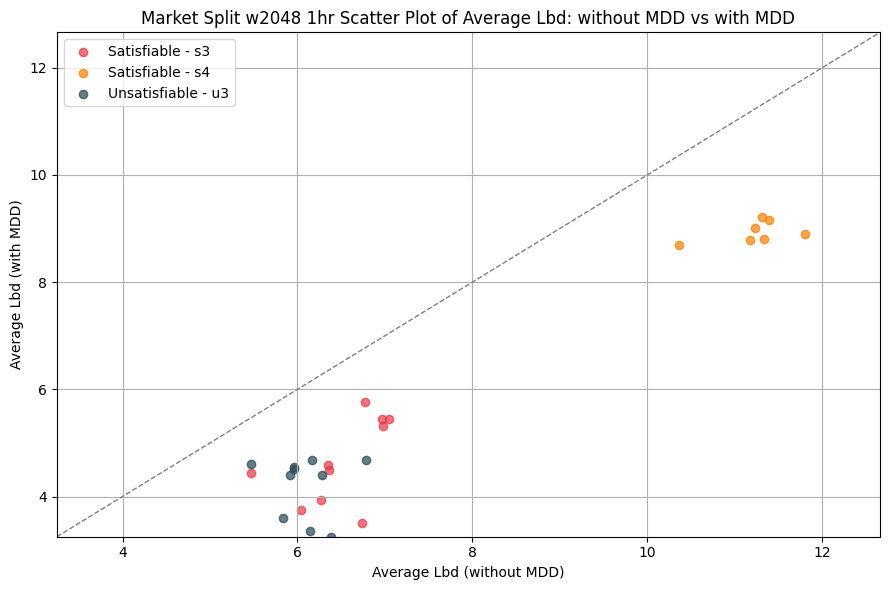

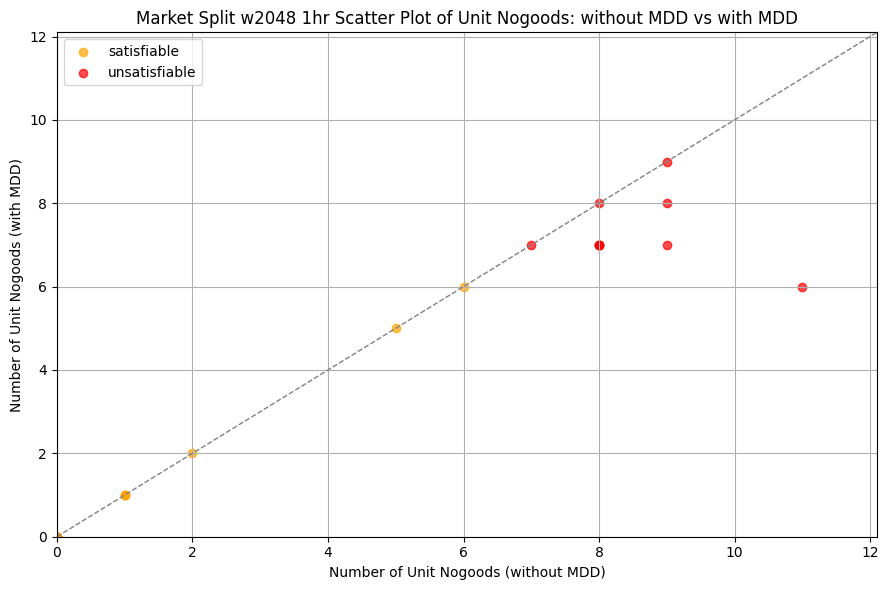

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048 1hr


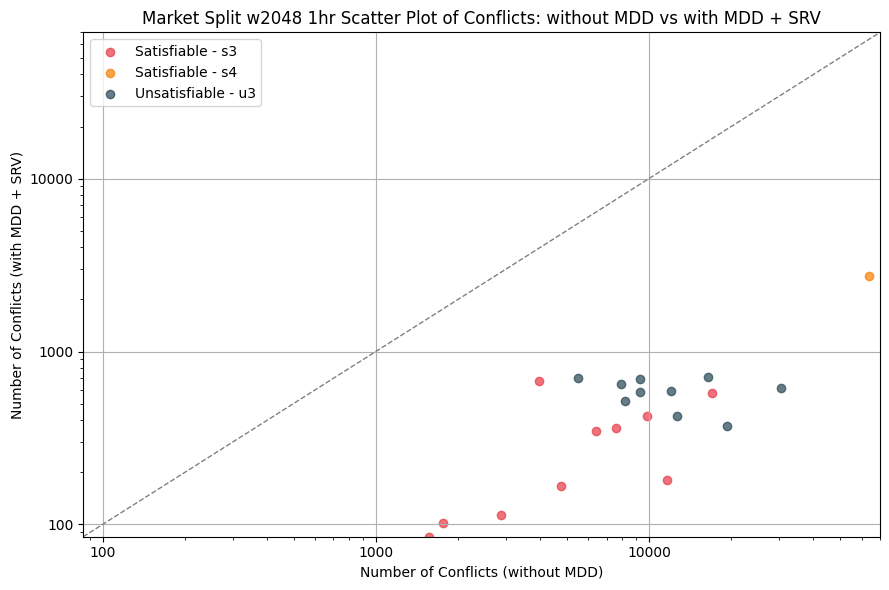

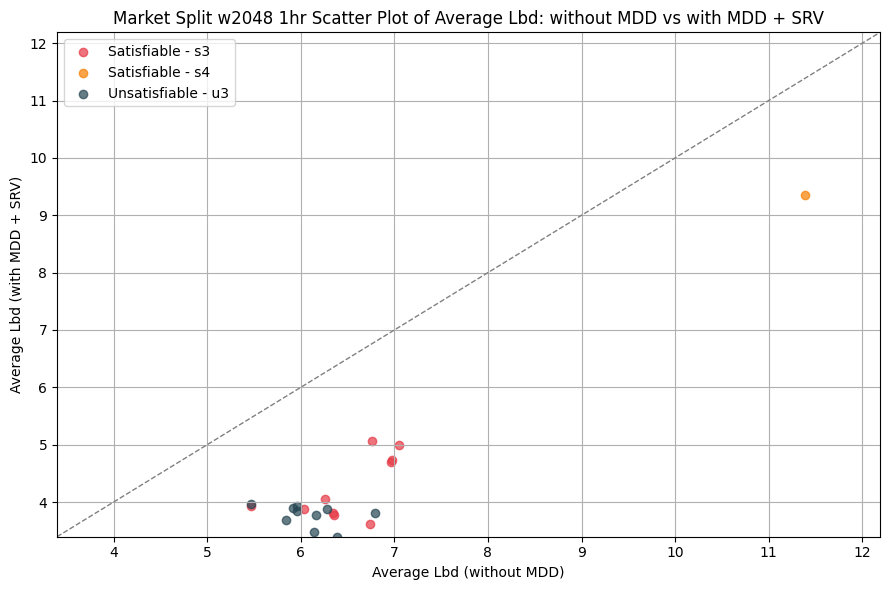

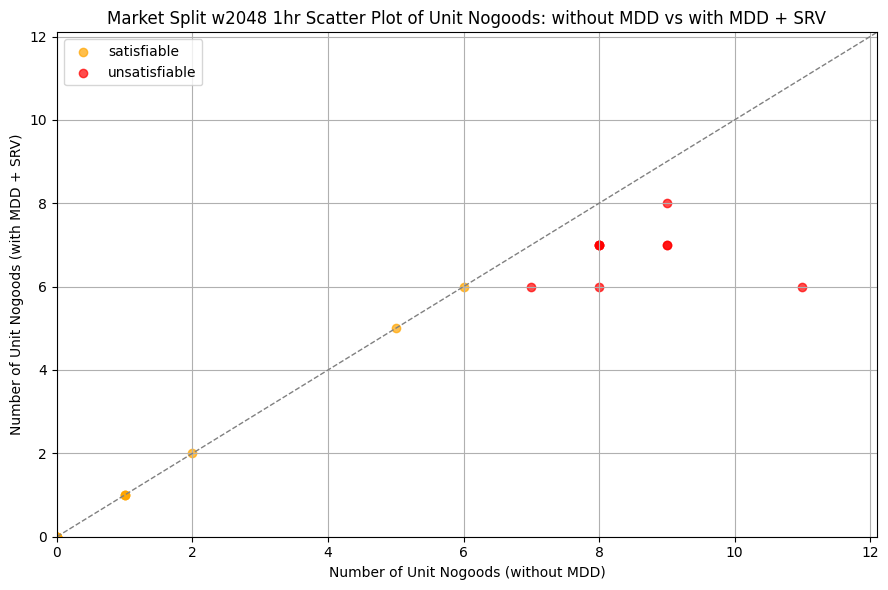

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048 1hr


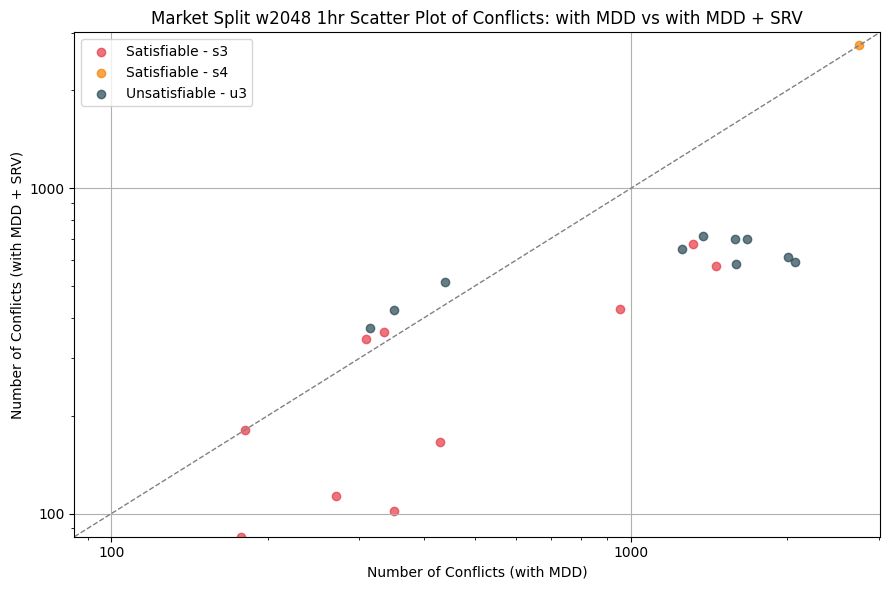

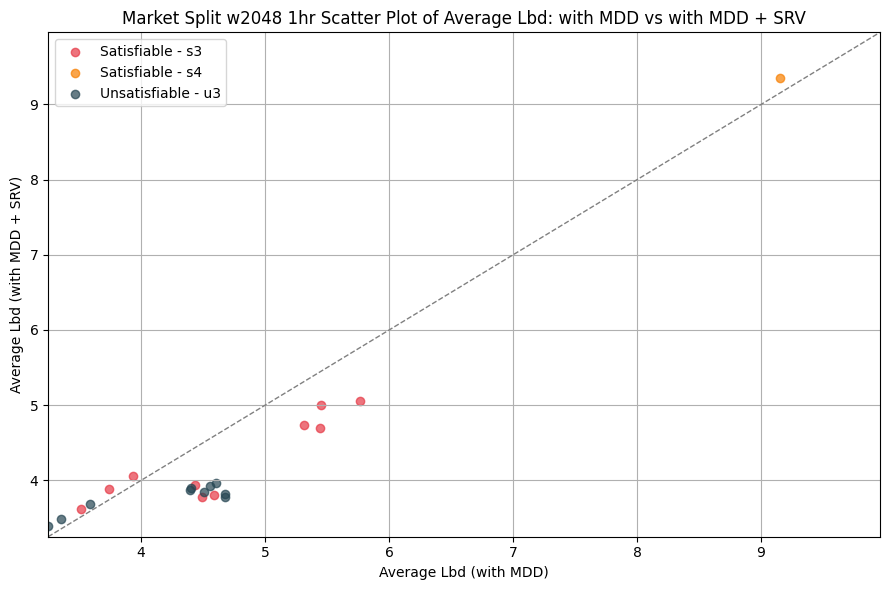

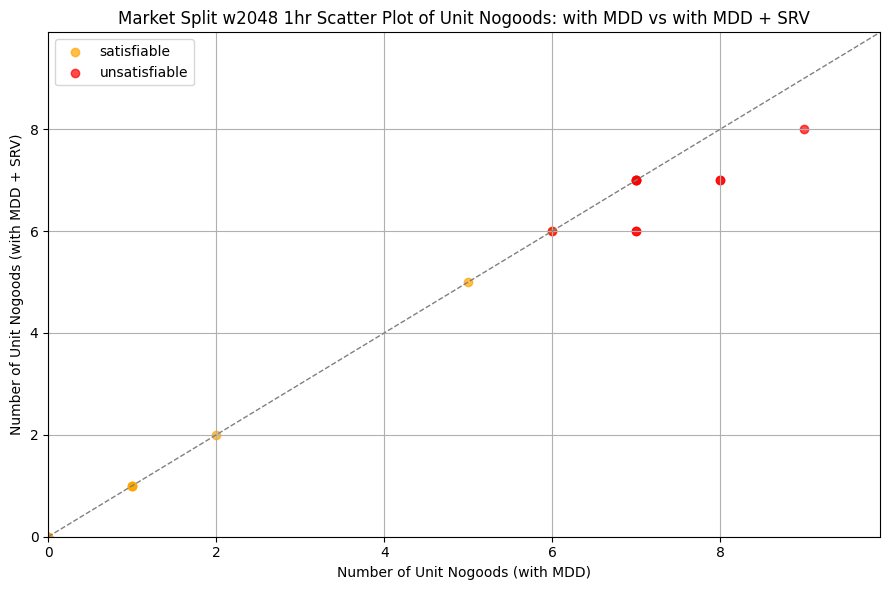

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split w2048 1hr


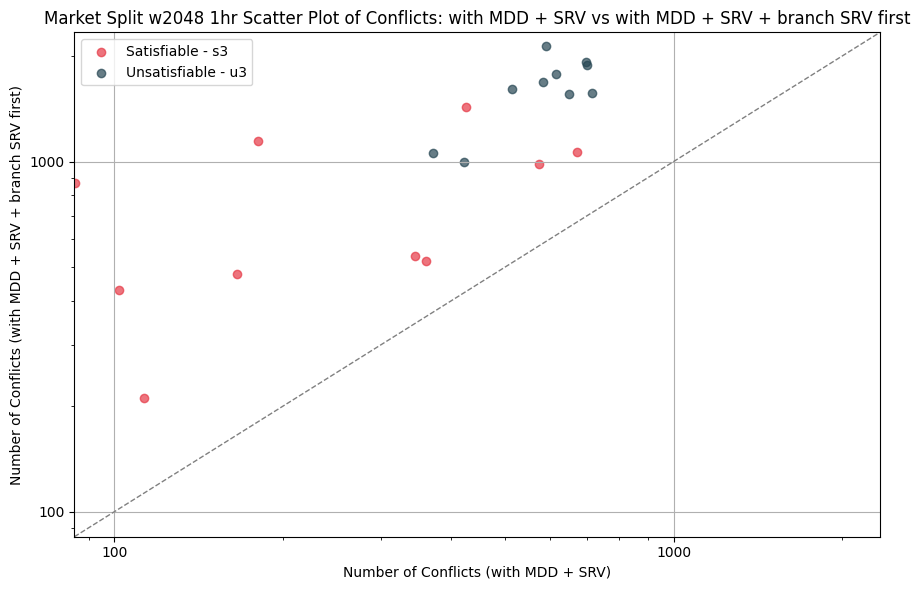

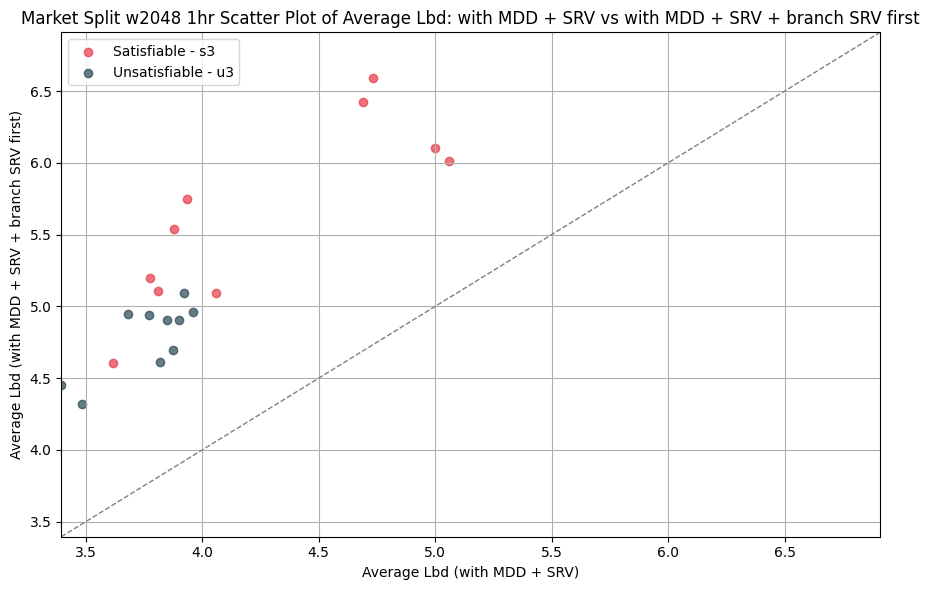

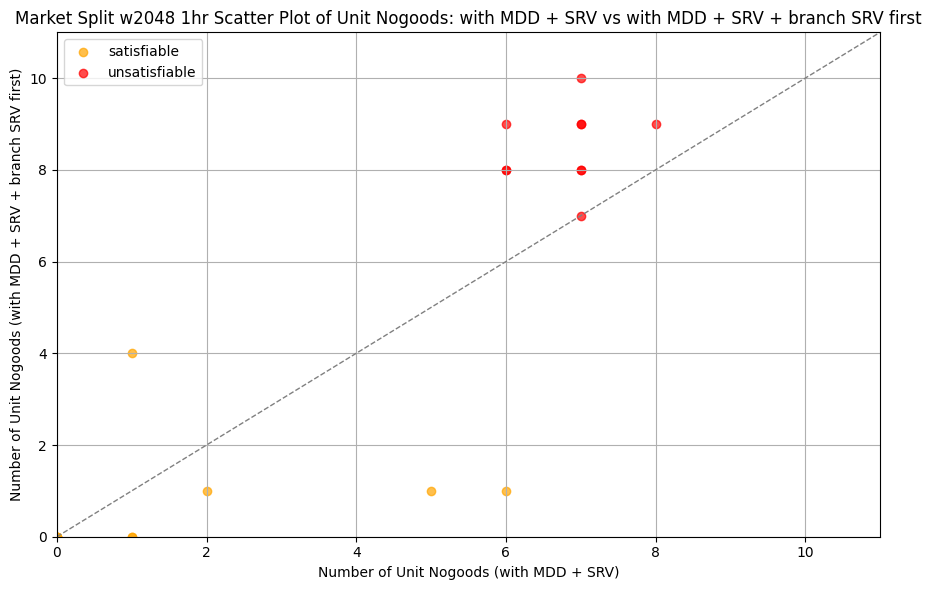

In [9]:
## Market Split w2048 1hr run
file_2048 = 'experiment_w2048_1hr/marketsplit_dd_disabled.csv'
file_2048_with_mdd = 'experiment_w2048_1hr/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'Market Split w2048 1hr', (9,6))
file_2048 = 'experiment_w2048_1hr/marketsplit_dd_disabled.csv'
file_2048_with_mdd_srv = 'experiment_w2048_1hr/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w2048 1hr', (9,6))
file_2048_with_mdd = 'experiment_w2048_1hr/marketsplit_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_w2048_1hr/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w2048 1hr', (9,6))
file_2048_with_mdd_srv = 'experiment_w2048_1hr/marketsplit_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w2048_1hr/marketsplit_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'Market Split w2048 1hr', (9,6))

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

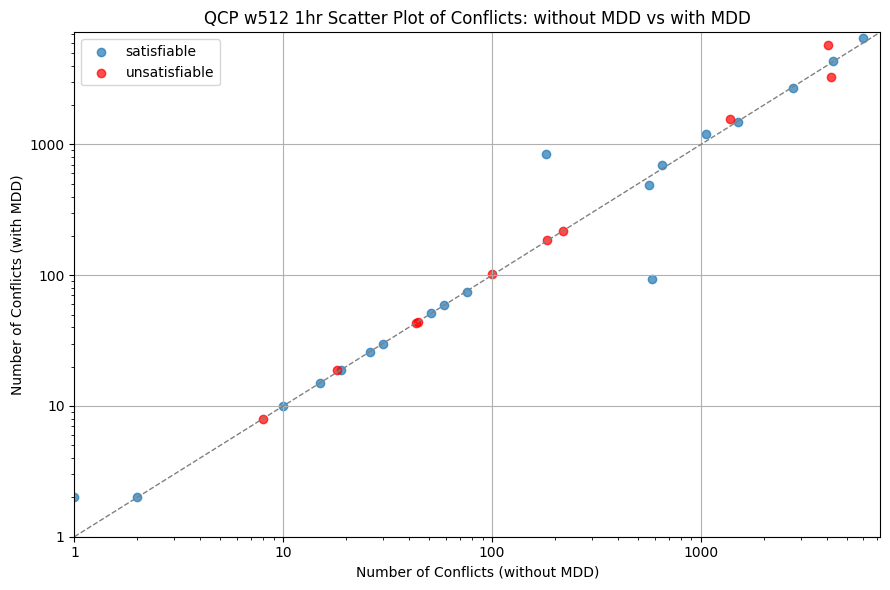

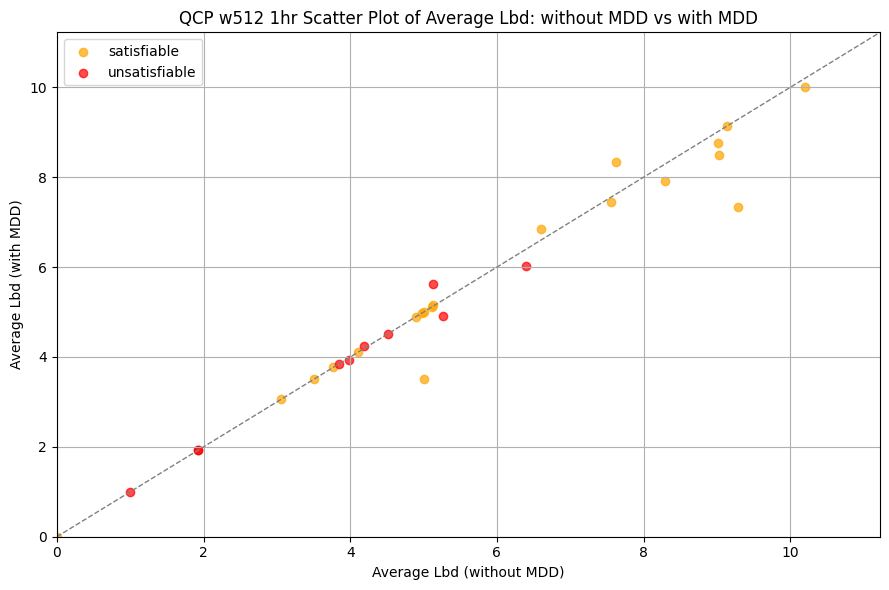

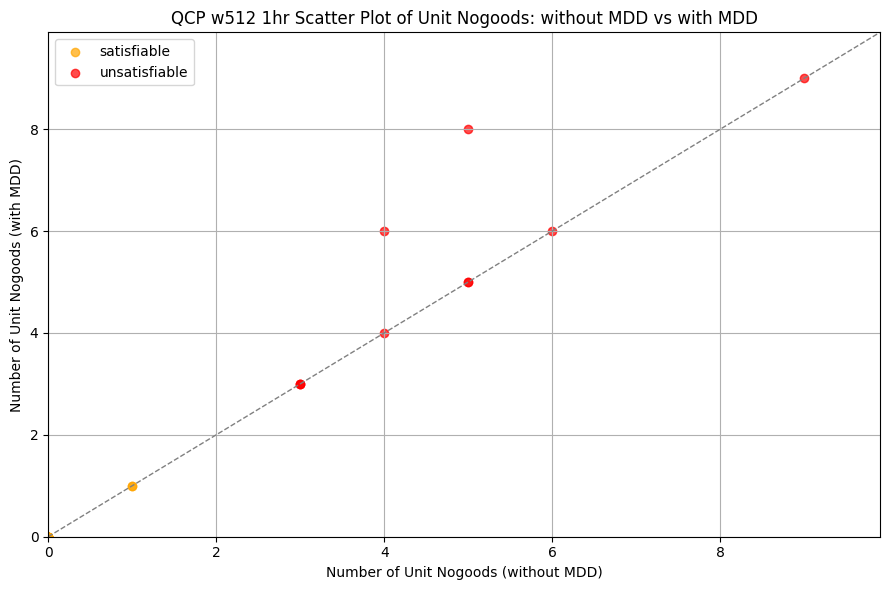

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

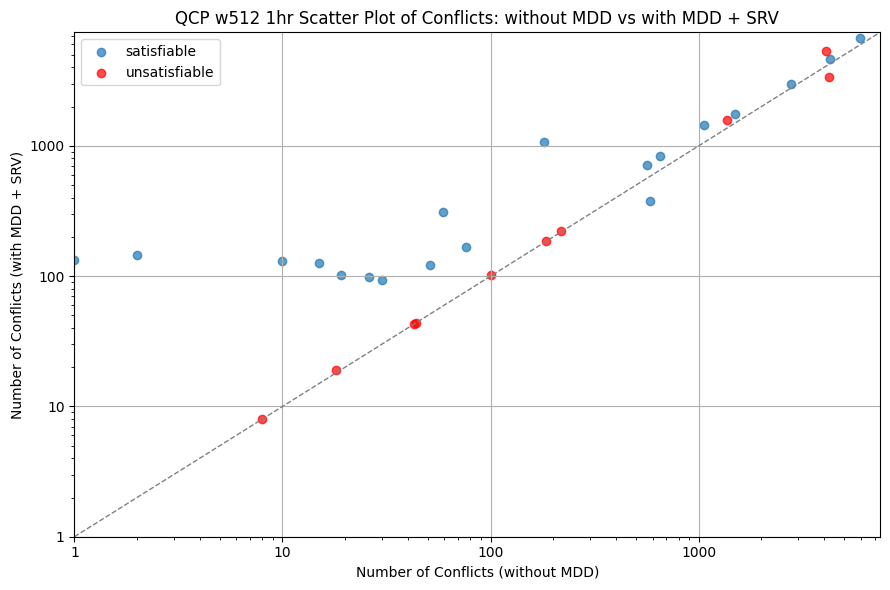

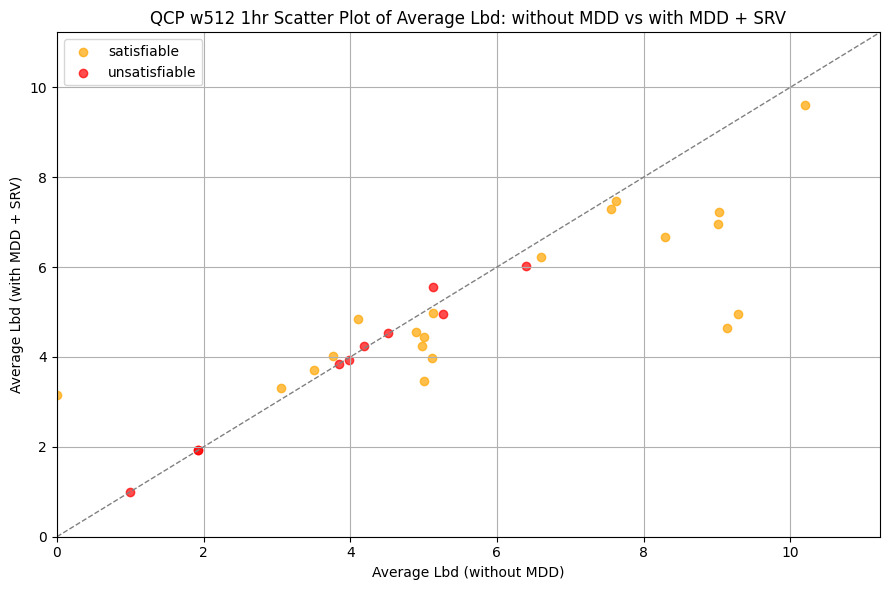

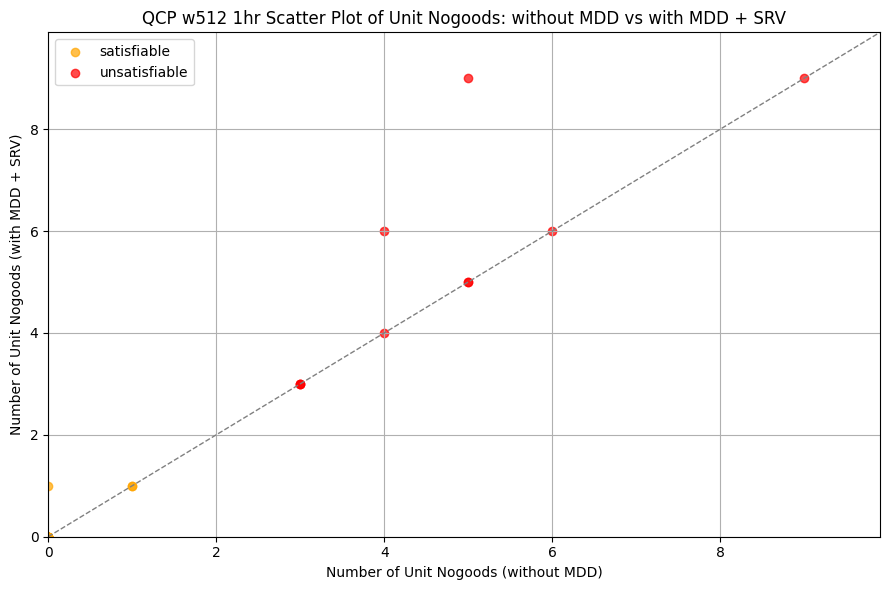

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

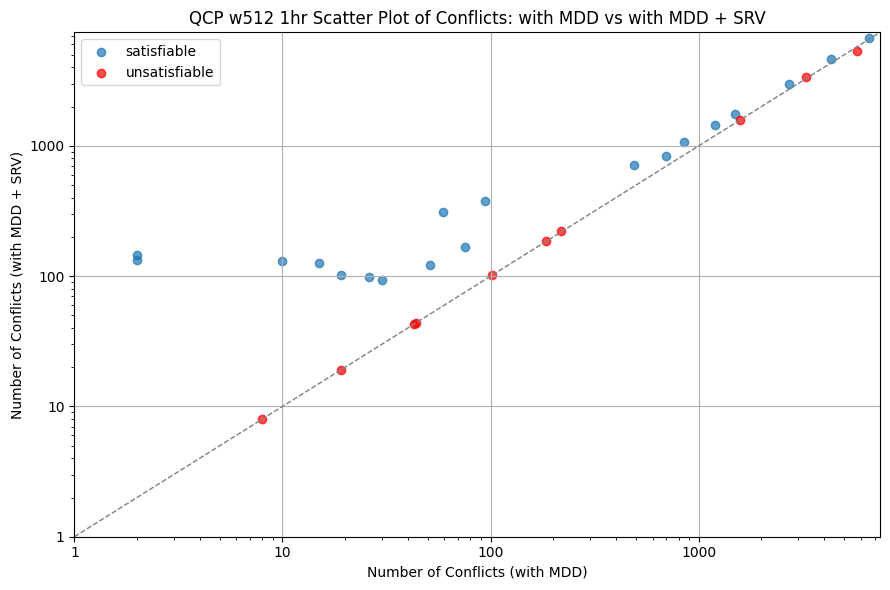

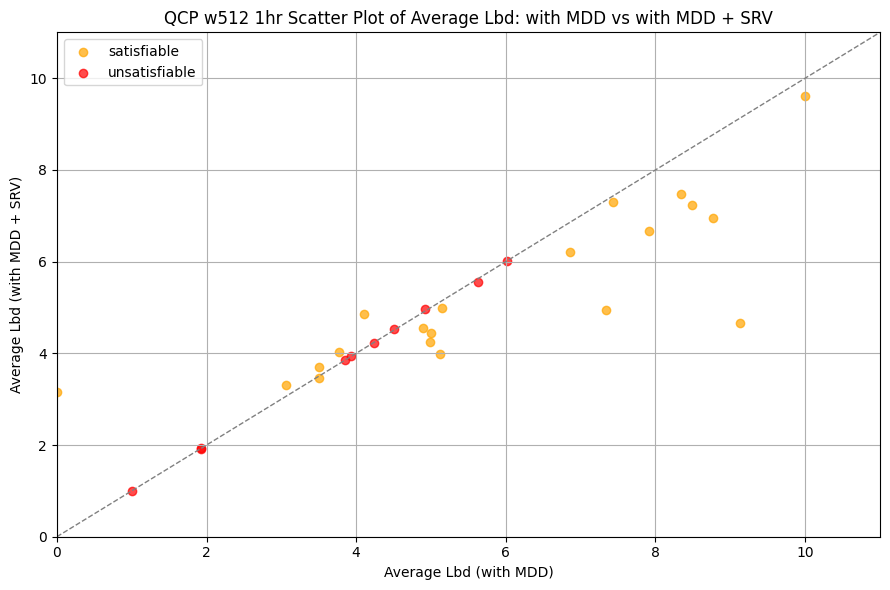

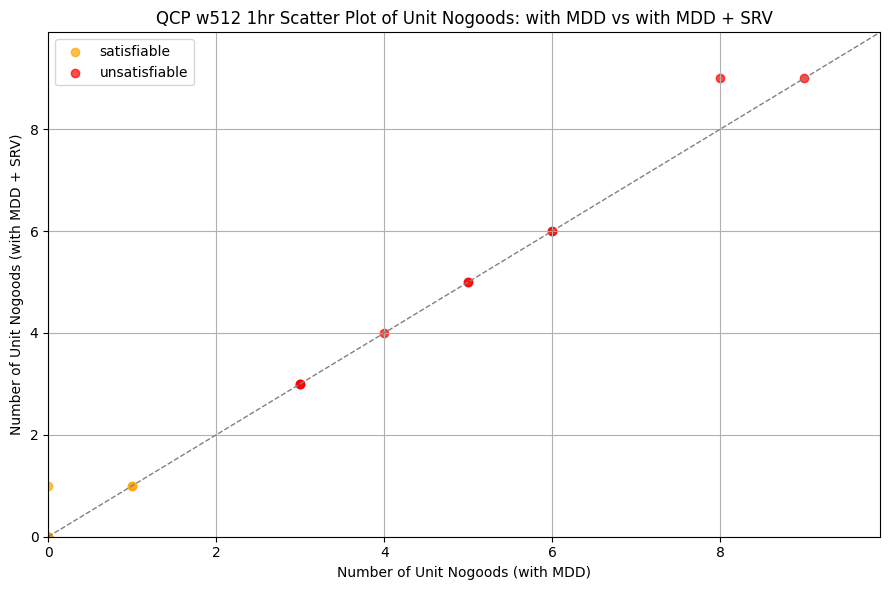

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

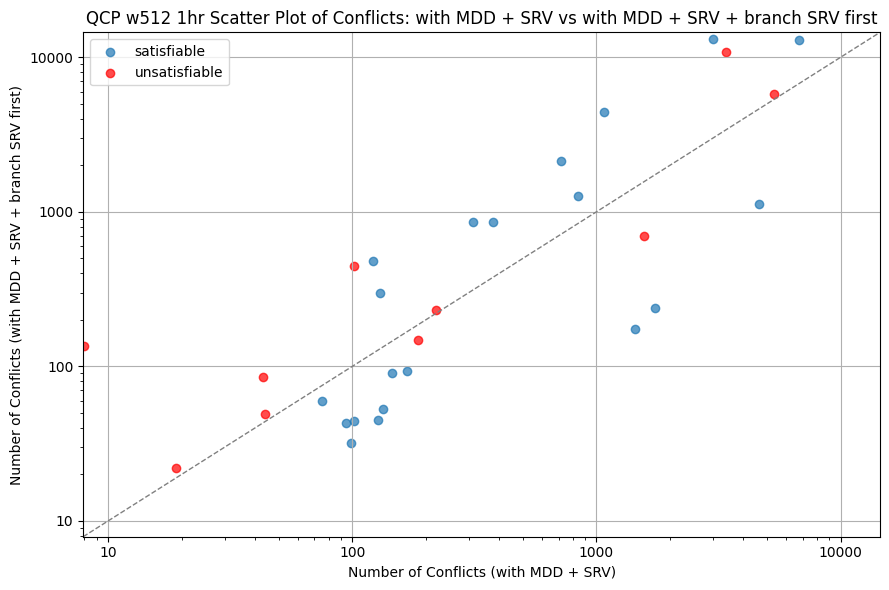

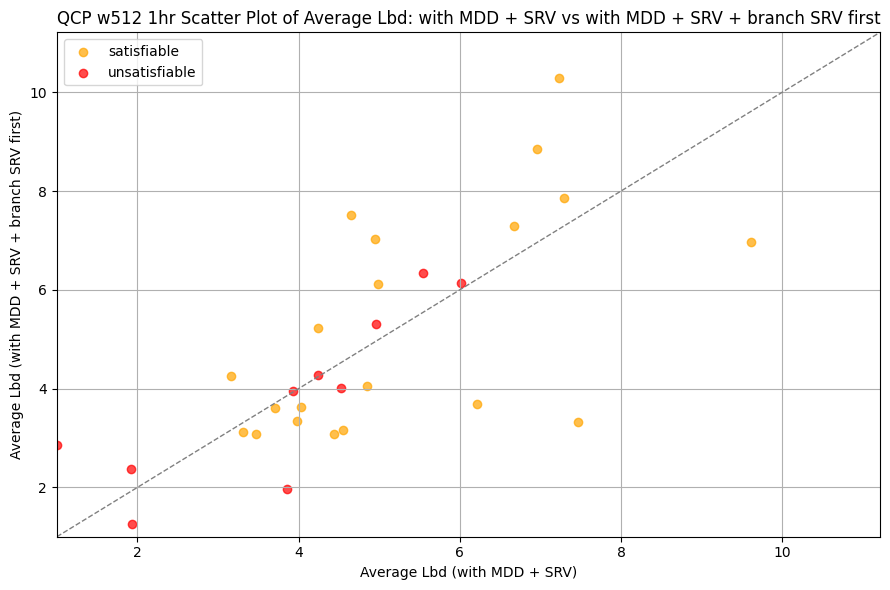

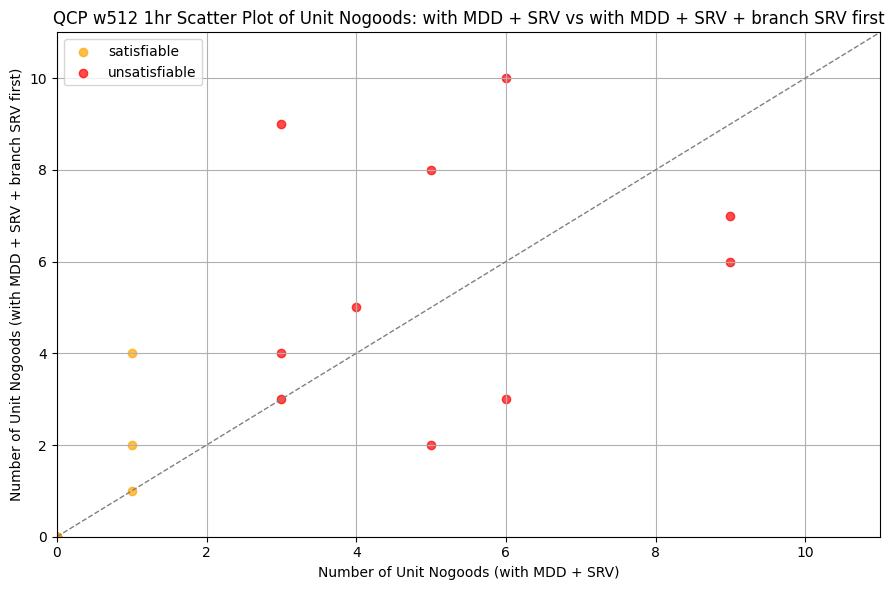

In [10]:
## QCP 1hr run
## Max width 512 - QCP
file_2048 = 'experiment_w512_1hr/qcp_disabled.csv'
file_2048_with_mdd = 'experiment_w512_1hr/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'QCP w512 1hr', (9,6))
file_2048 = 'experiment_w512_1hr/qcp_disabled.csv'
file_2048_with_mdd_srv = 'experiment_w512_1hr/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w512 1hr', (9,6))
file_2048_with_mdd = 'experiment_w512_1hr/qcp_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_w512_1hr/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w512 1hr', (9,6))
file_2048_with_mdd_srv = 'experiment_w512_1hr/qcp_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w512_1hr/qcp_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'QCP w512 1hr', (9,6))

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

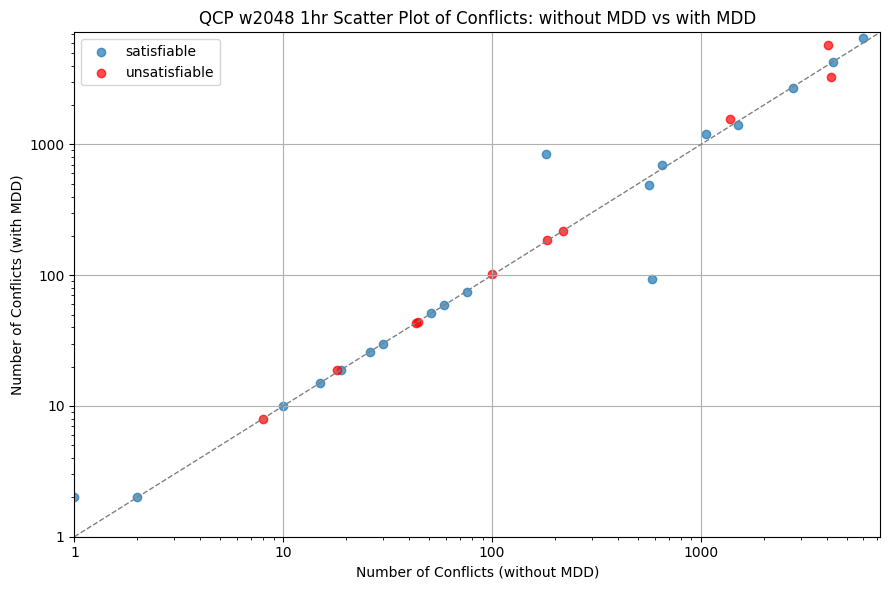

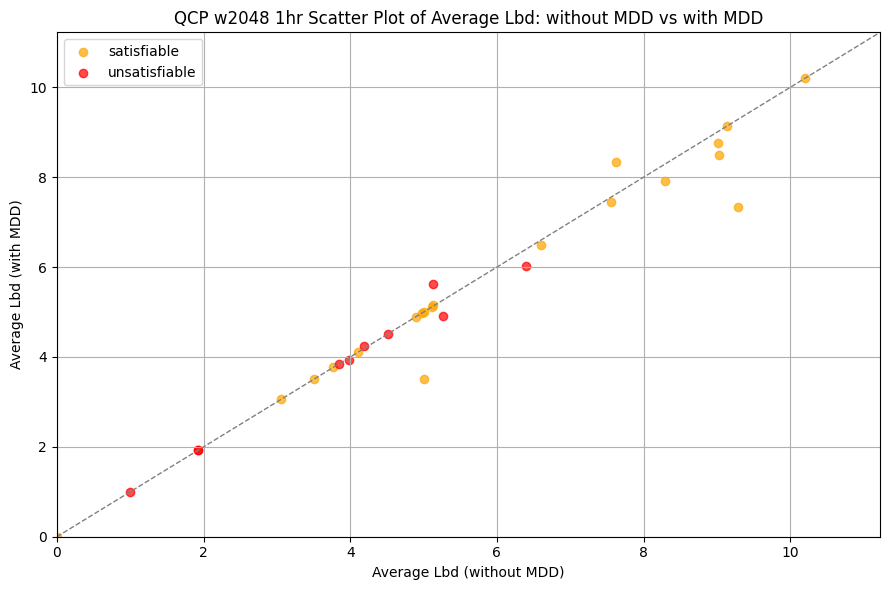

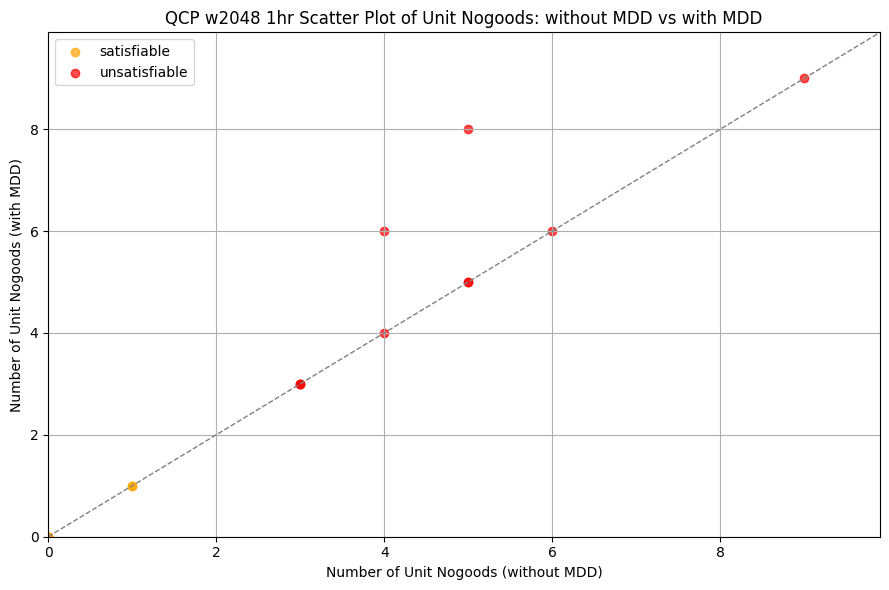

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15

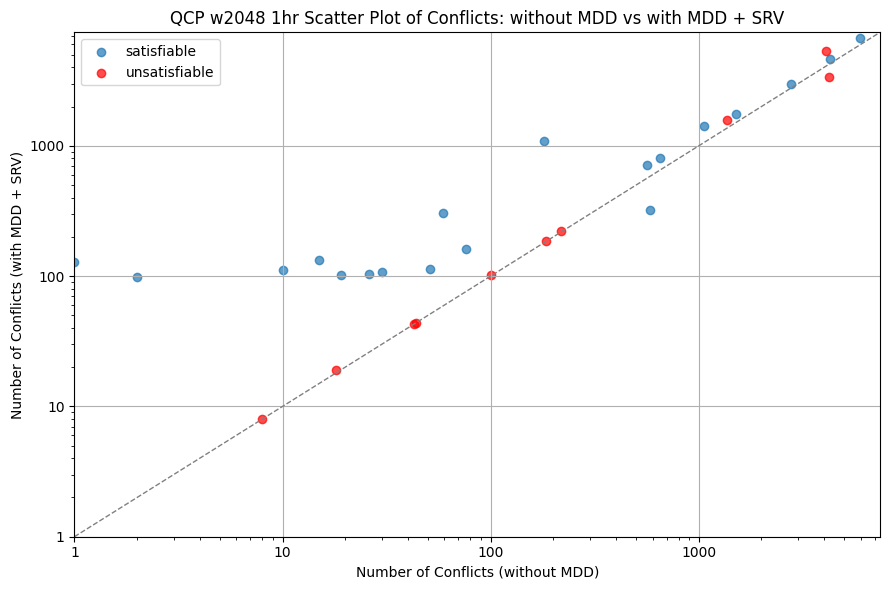

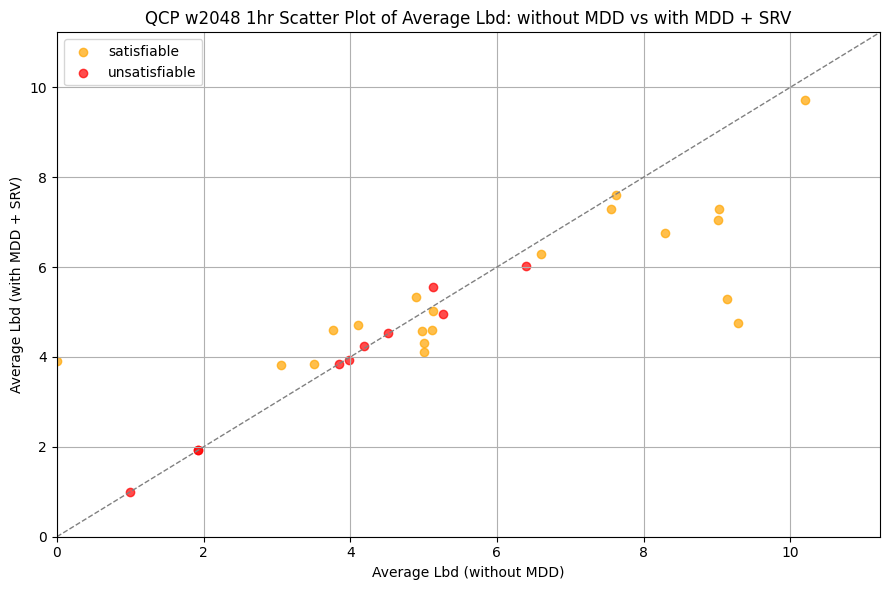

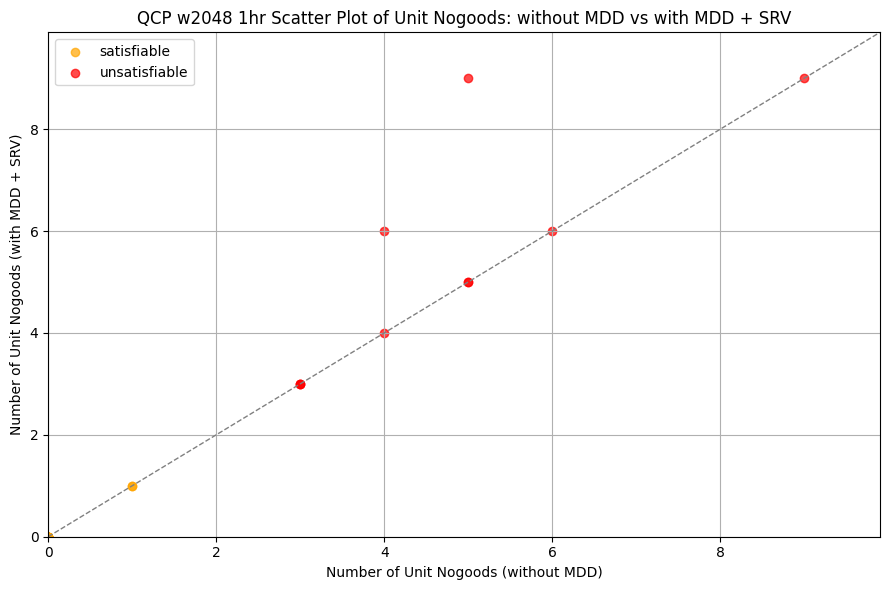

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

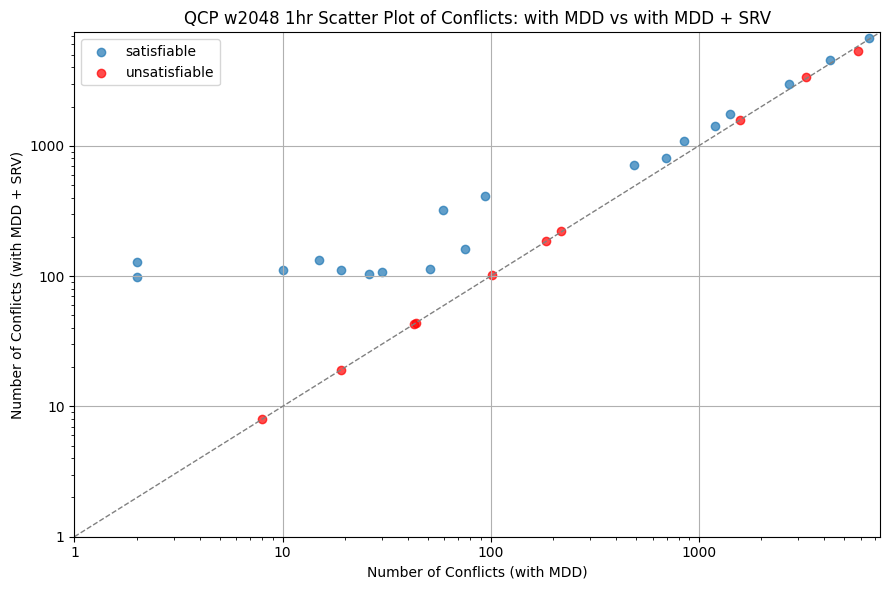

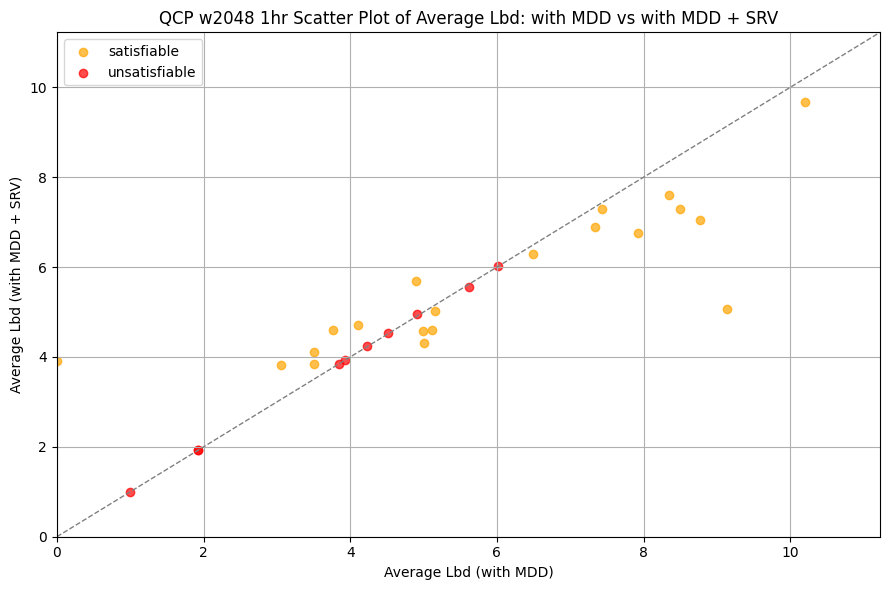

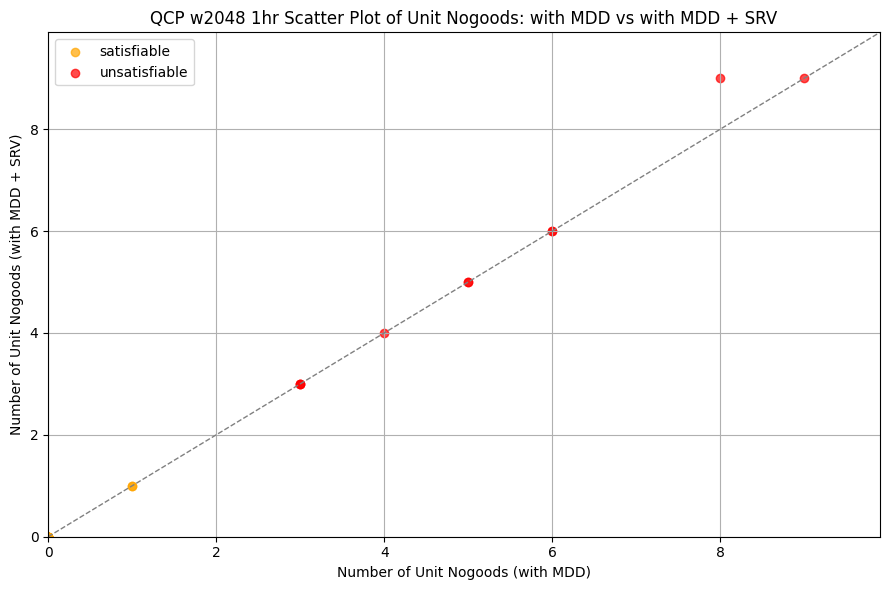

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

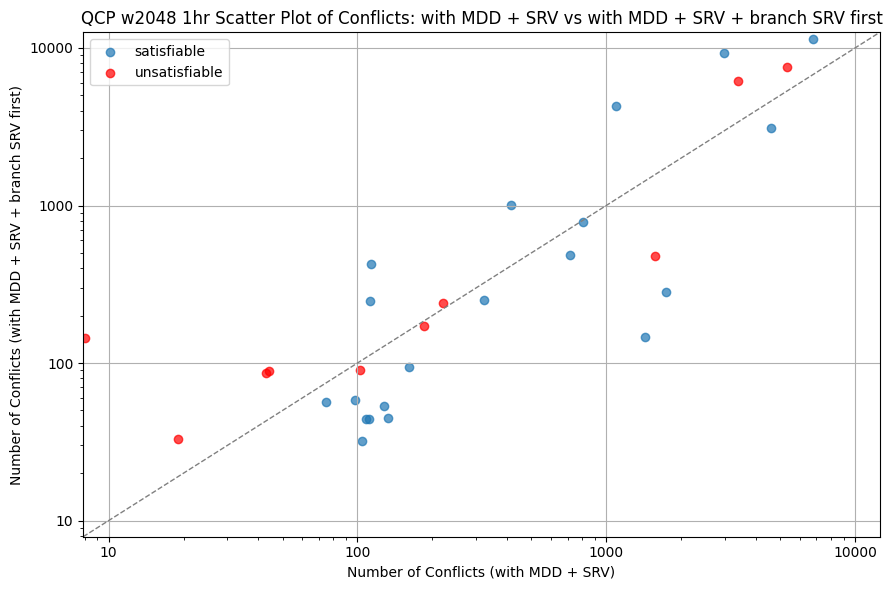

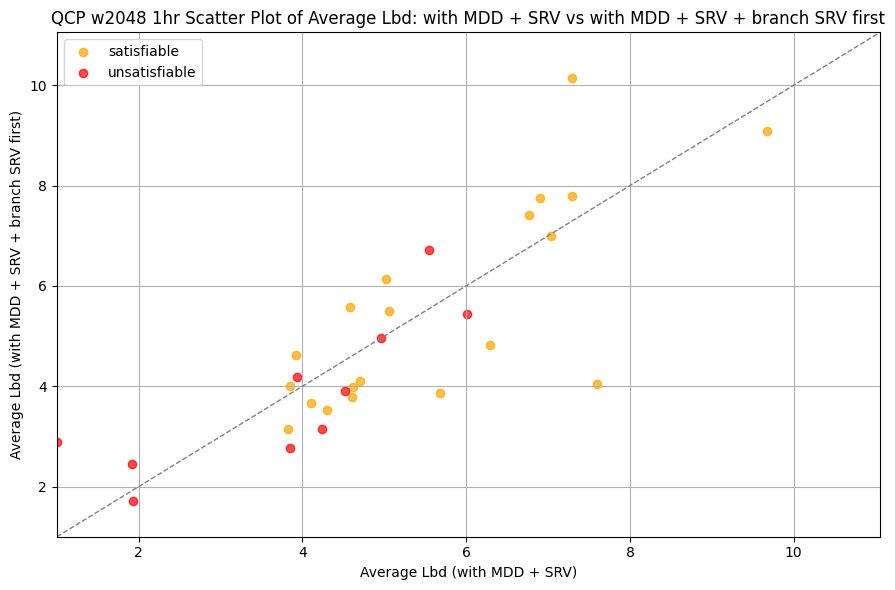

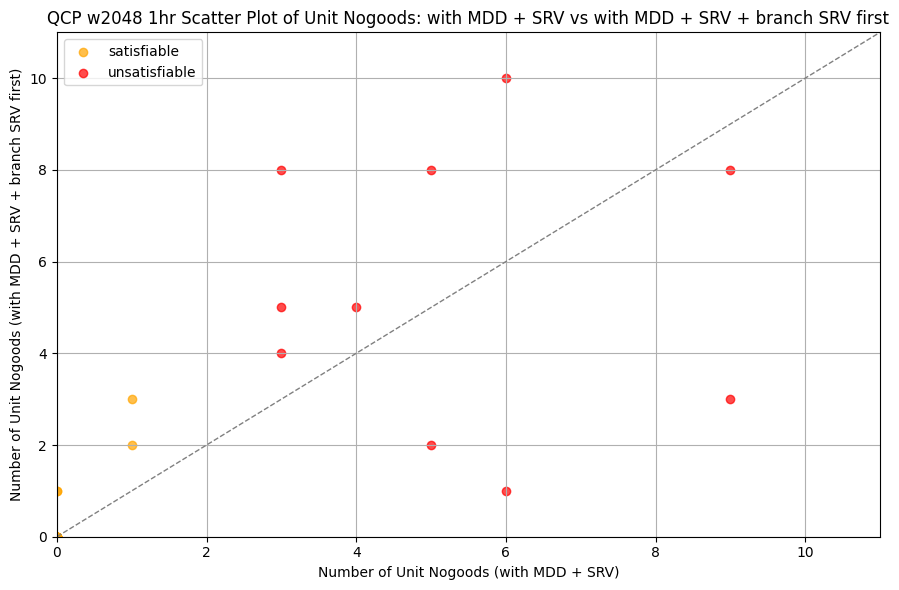

In [11]:
## QCP 1hr run
## Max width 2048 - QCP
file_2048 = 'experiment_w2048_1hr/qcp_disabled.csv'
file_2048_with_mdd = 'experiment_w2048_1hr/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'QCP w2048 1hr', (9,6))
file_2048 = 'experiment_w2048_1hr/qcp_disabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w2048 1hr', (9,6))
file_2048_with_mdd = 'experiment_w2048_1hr/qcp_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_w2048_1hr/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w2048 1hr', (9,6))
file_2048_with_mdd_srv = 'experiment_w2048_1hr/qcp_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w2048_1hr/qcp_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first', 'QCP w2048 1hr', (9,6))

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split without MDD


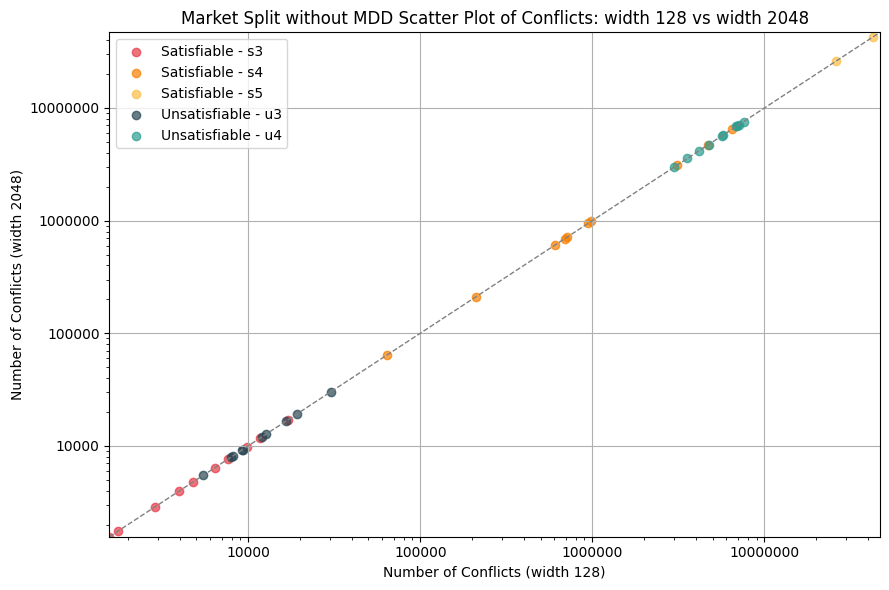

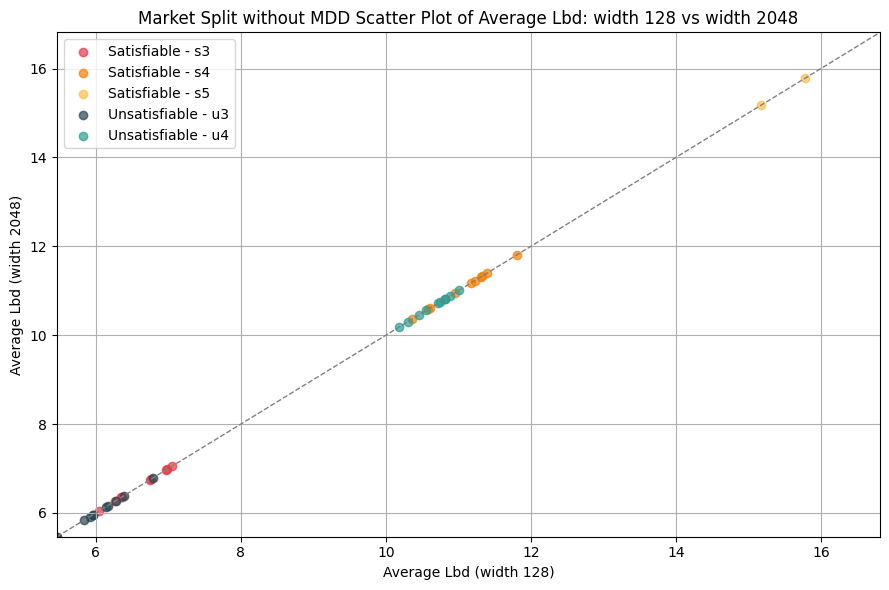

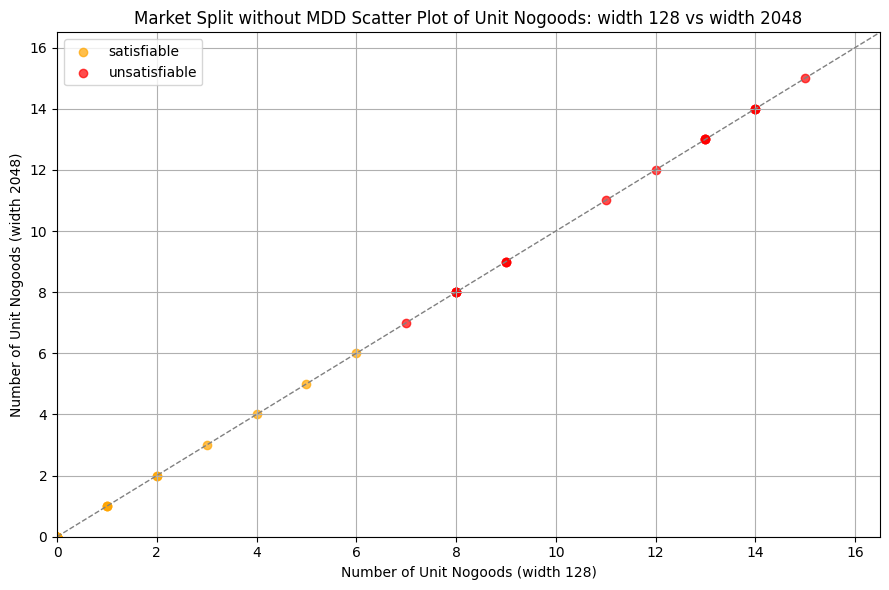

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split without MDD


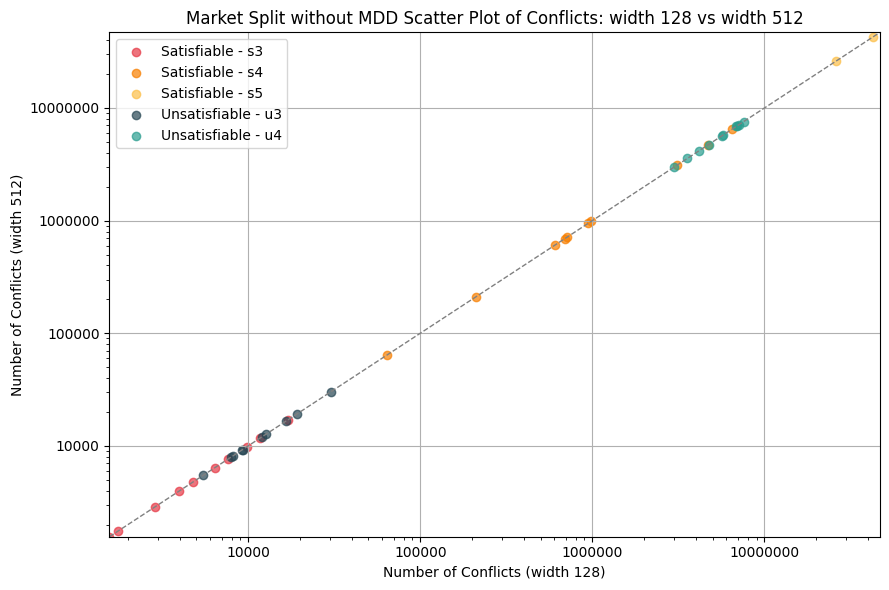

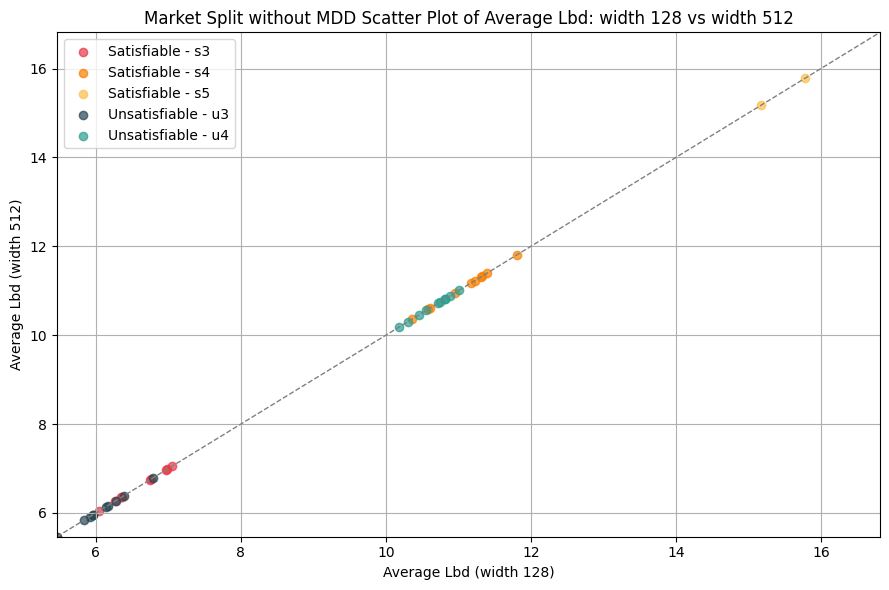

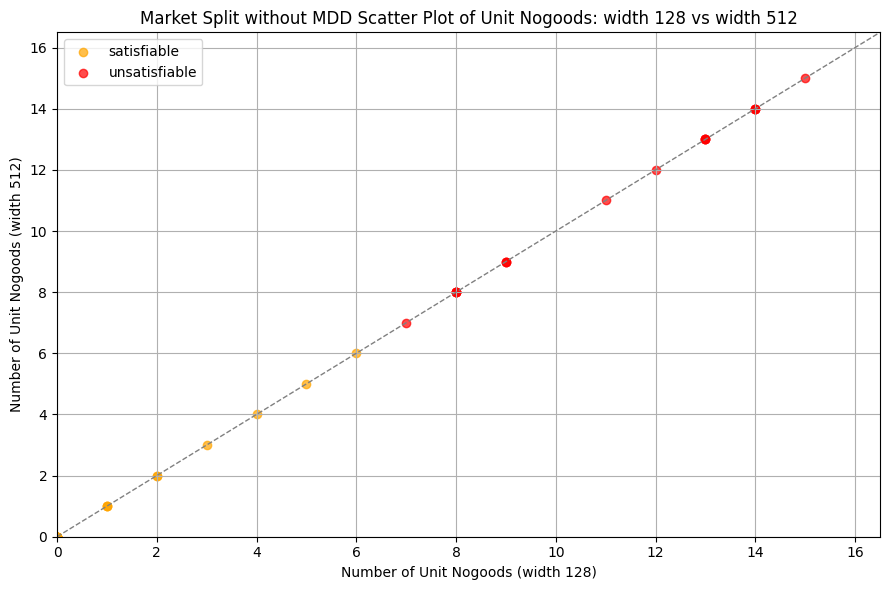

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10', 'u4-01', 'u4-02', 'u4-03', 'u4-04', 'u4-05', 'u4-06', 'u4-07', 'u4-08', 'u4-09', 'u4-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-03', 's4-04', 's4-05', 's4-06', 's4-07', 's4-08', 's4-09', 's4-10', 's5-02', 's5-04']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split without MDD


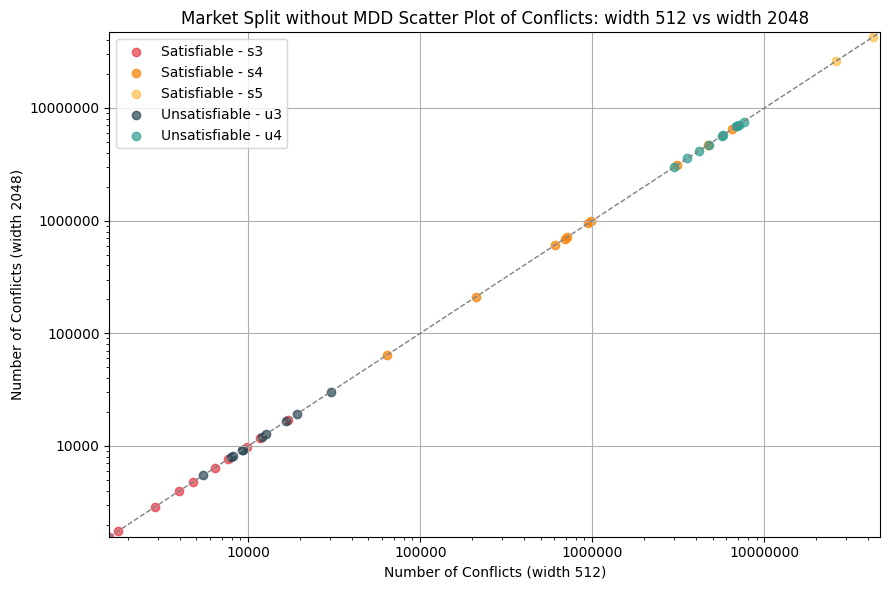

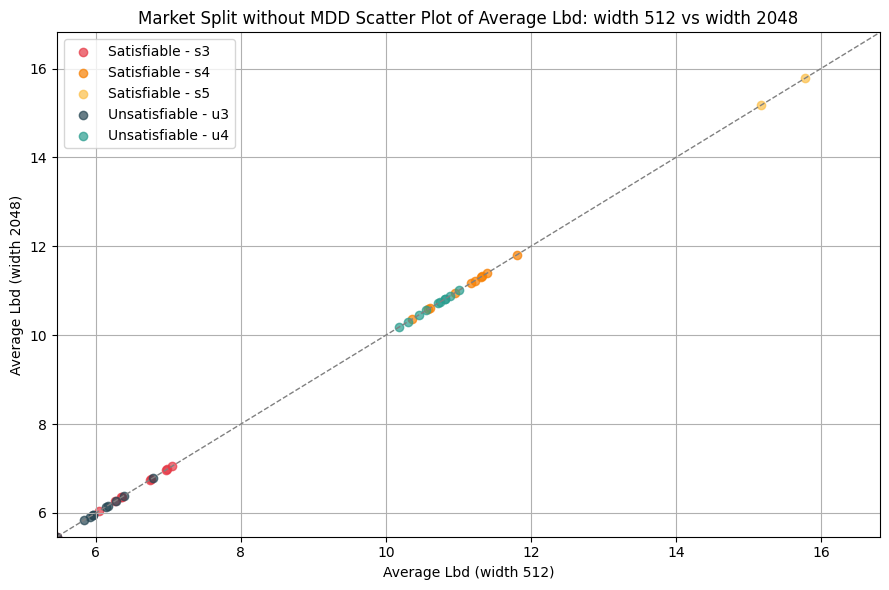

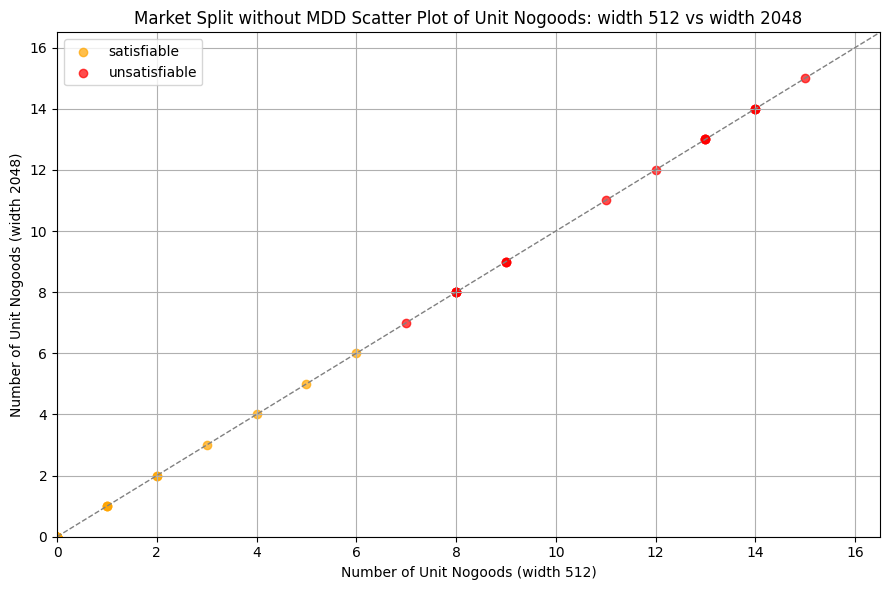

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD


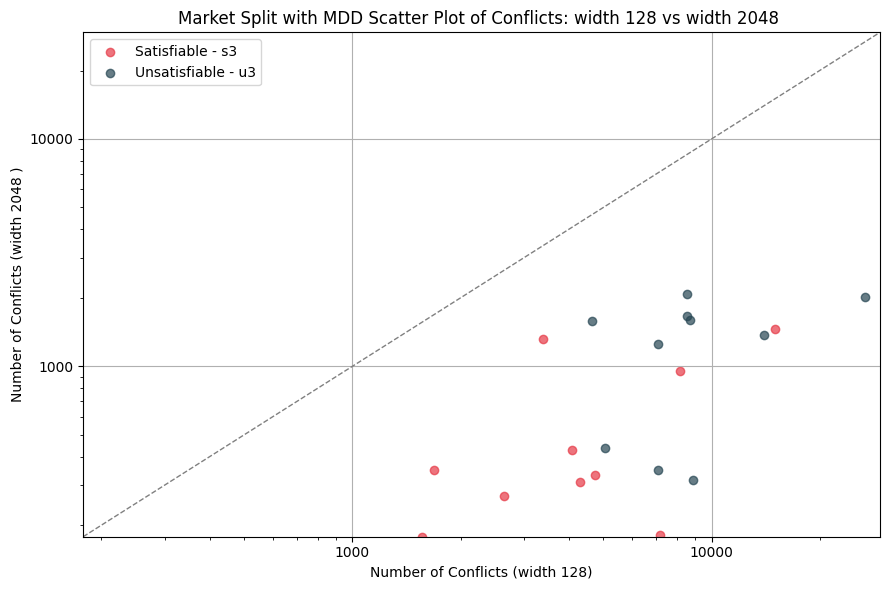

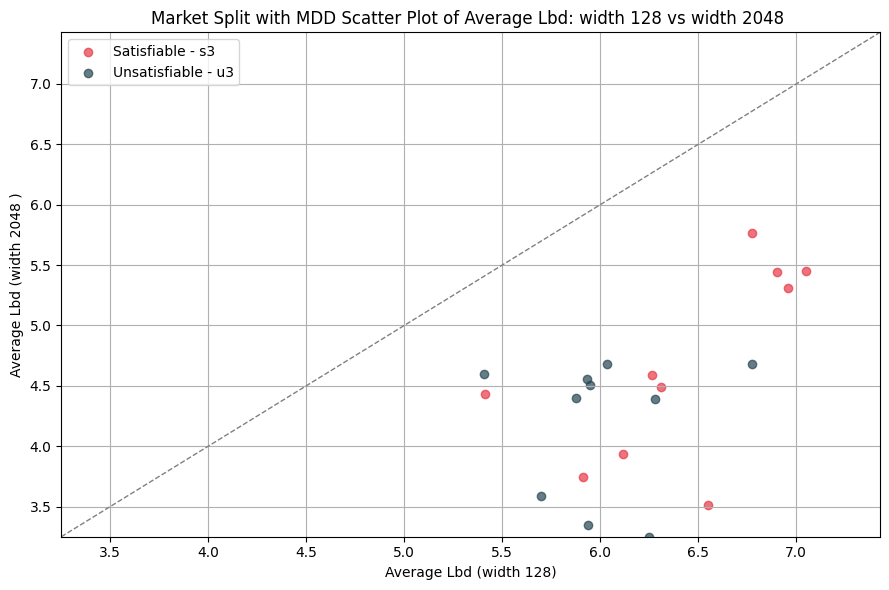

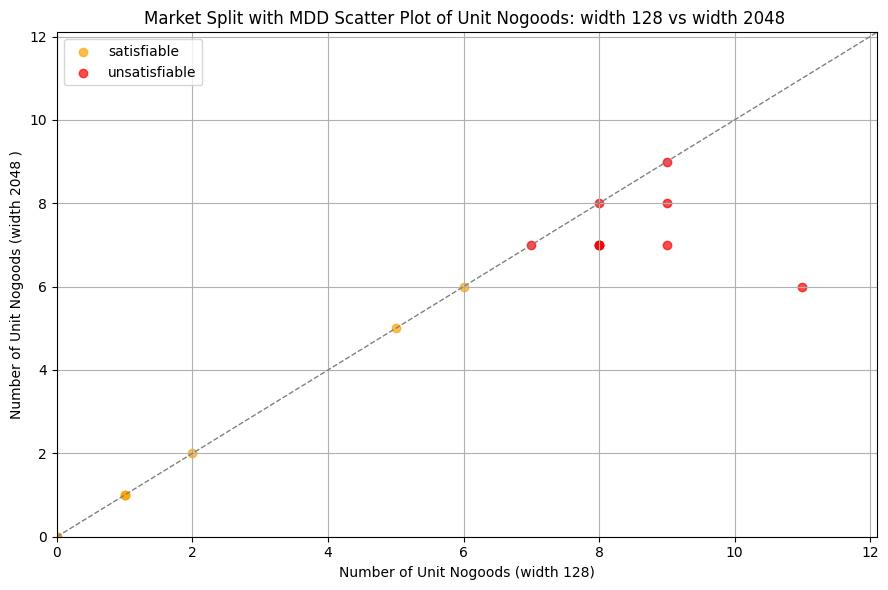

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-05', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD


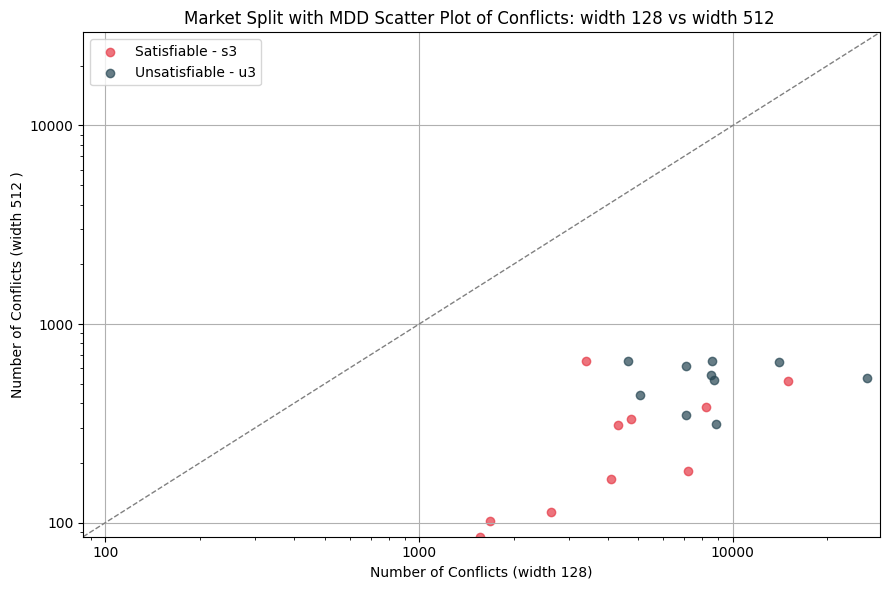

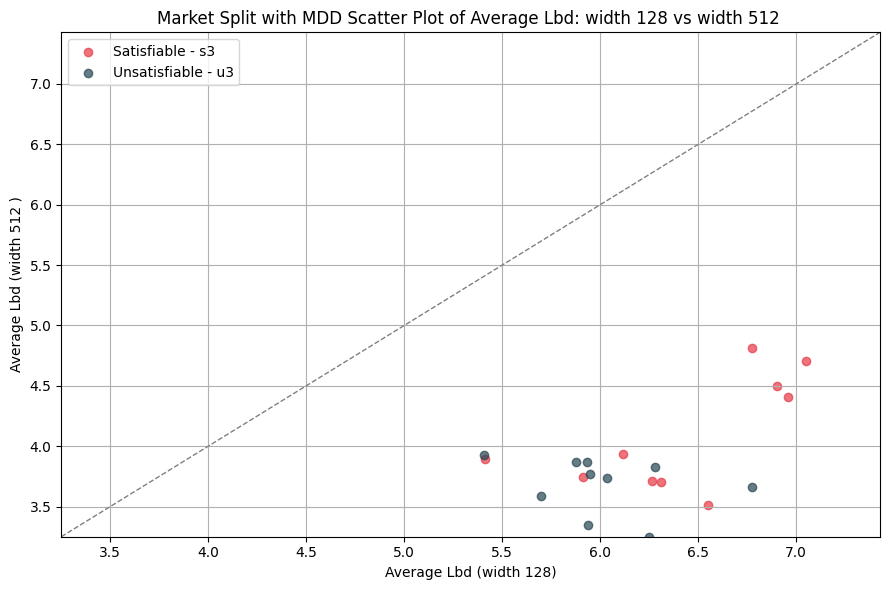

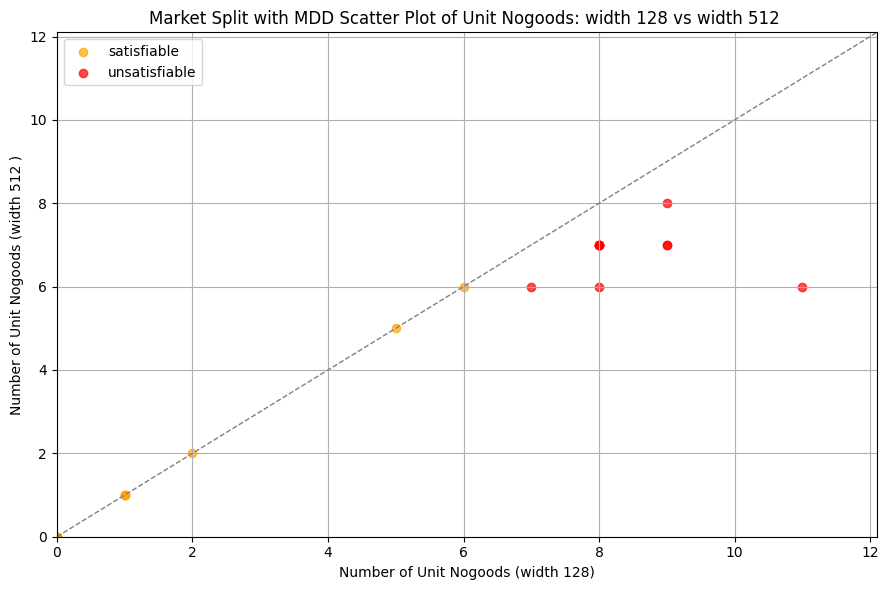

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-05', 's4-08', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-01', 's4-02', 's4-04', 's4-05', 's4-06', 's4-08', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD


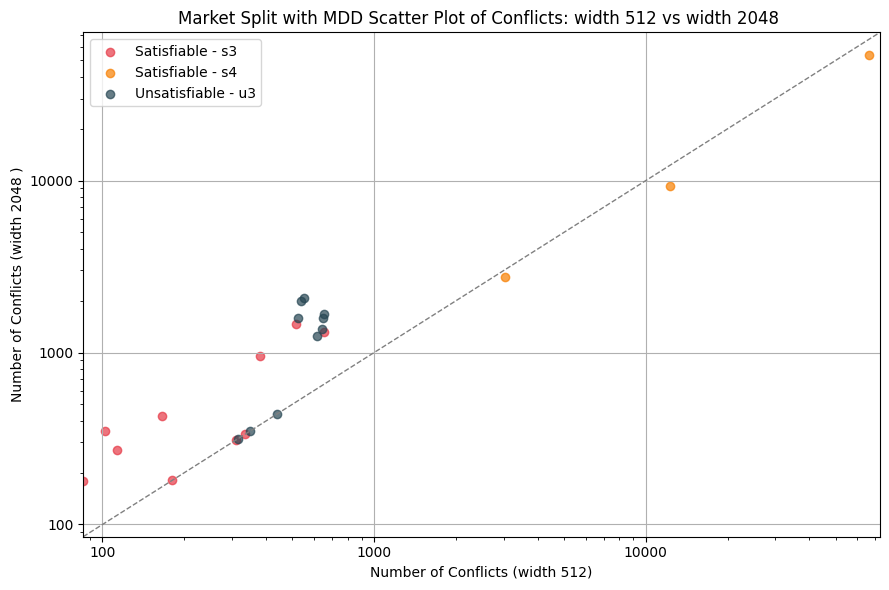

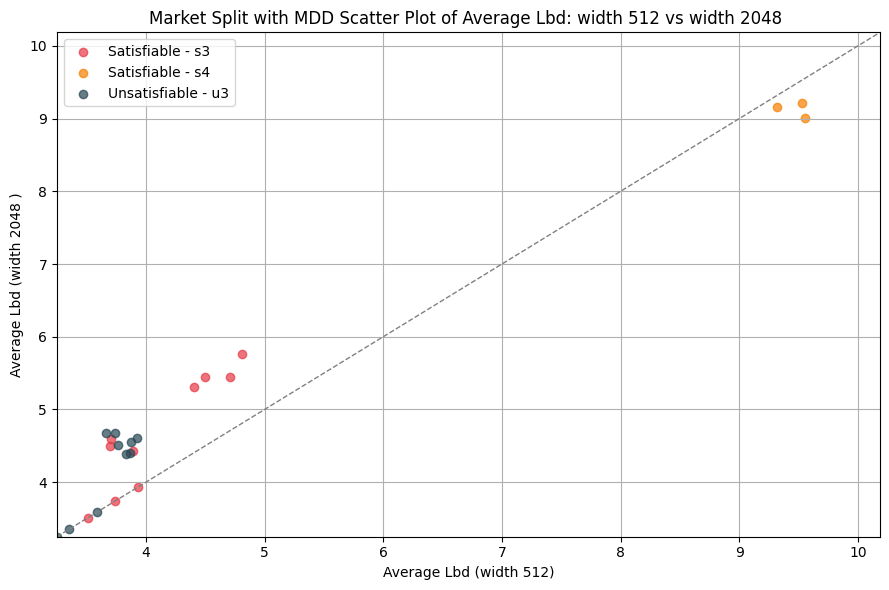

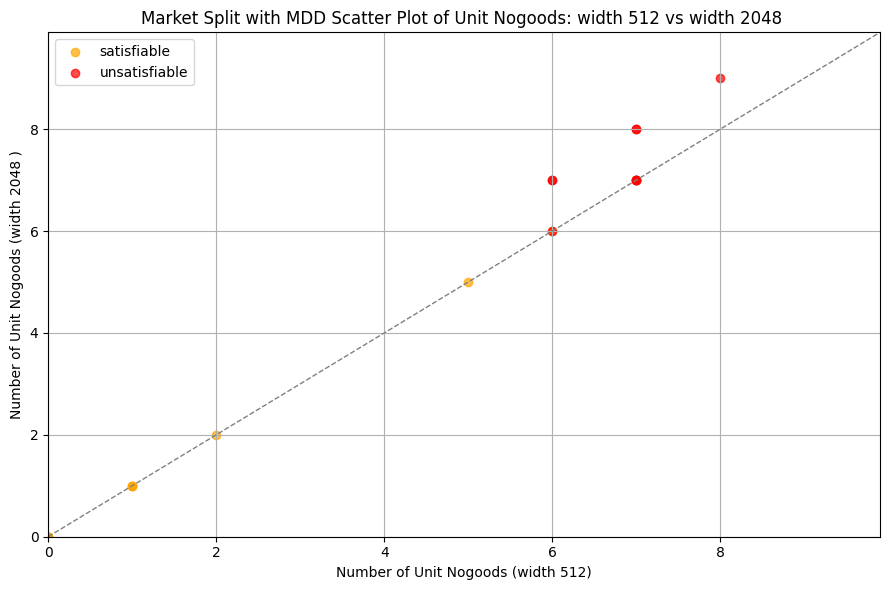

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV


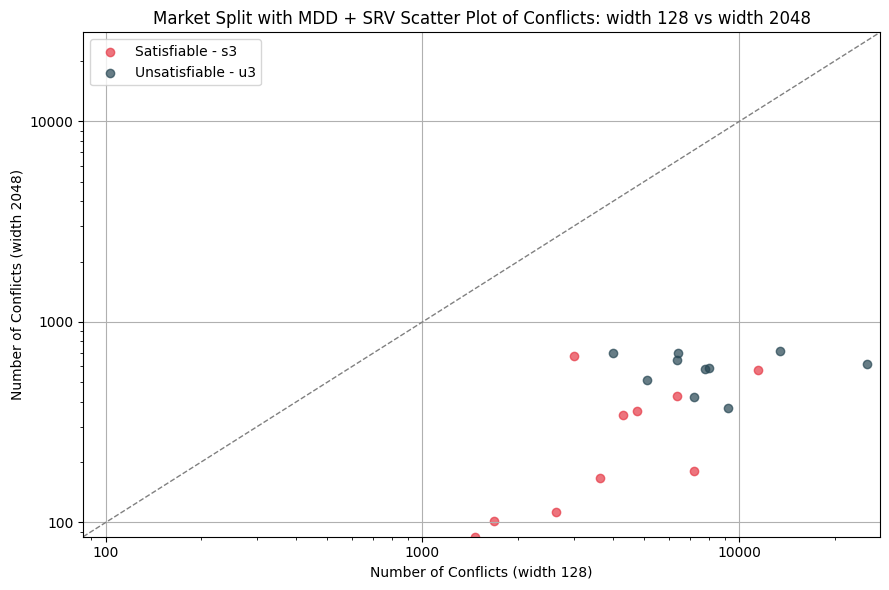

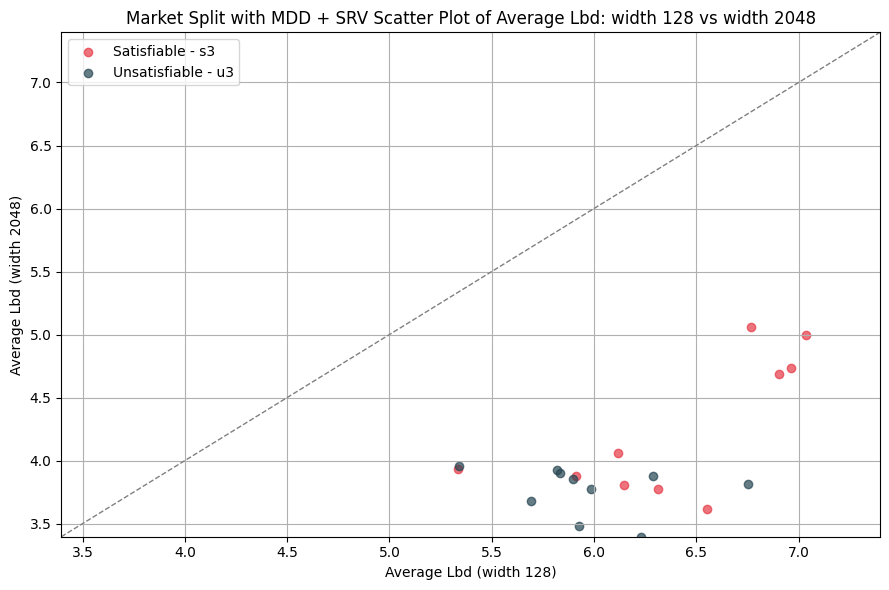

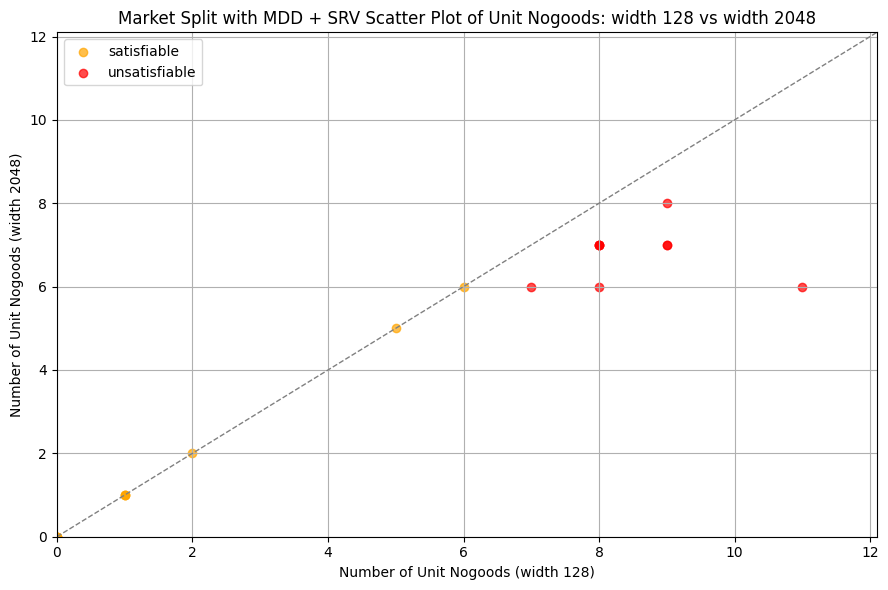

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV


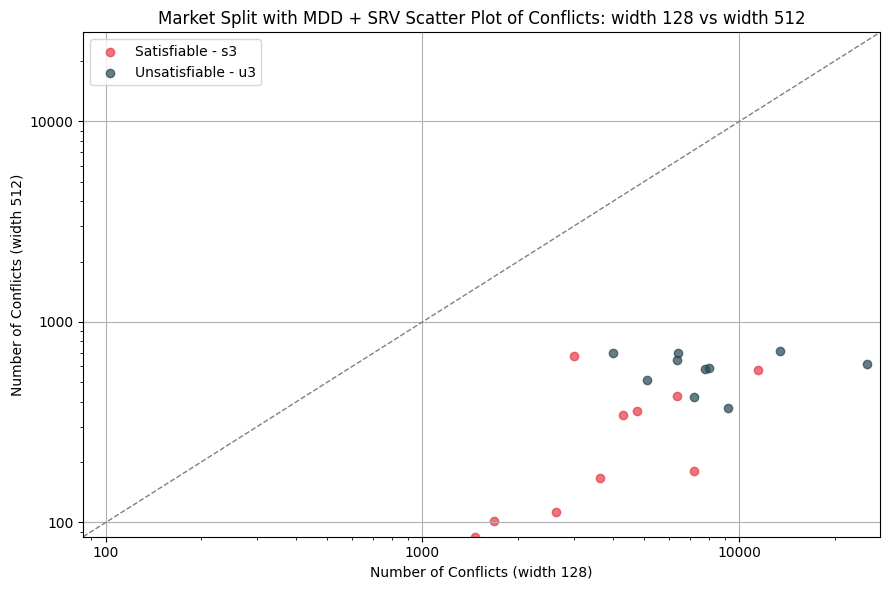

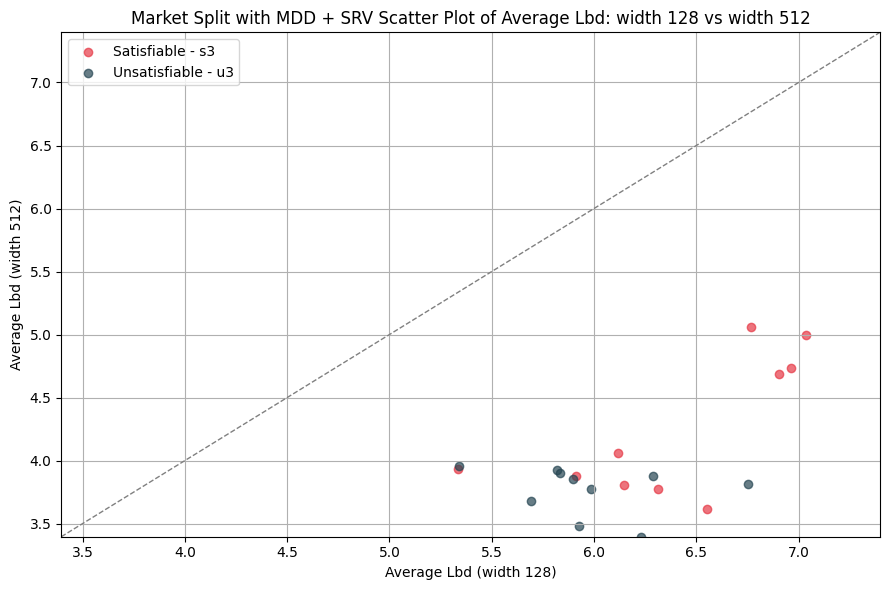

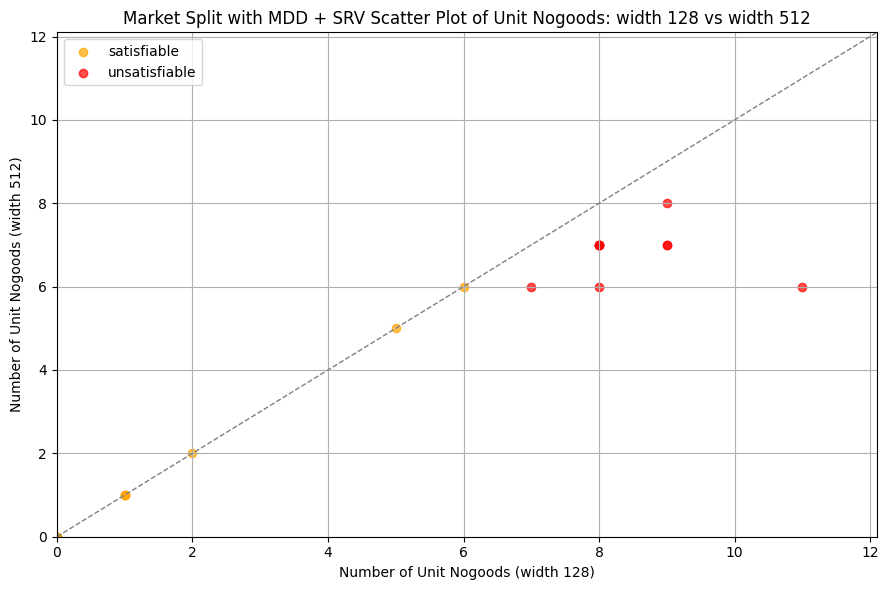

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10', 's4-09']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV


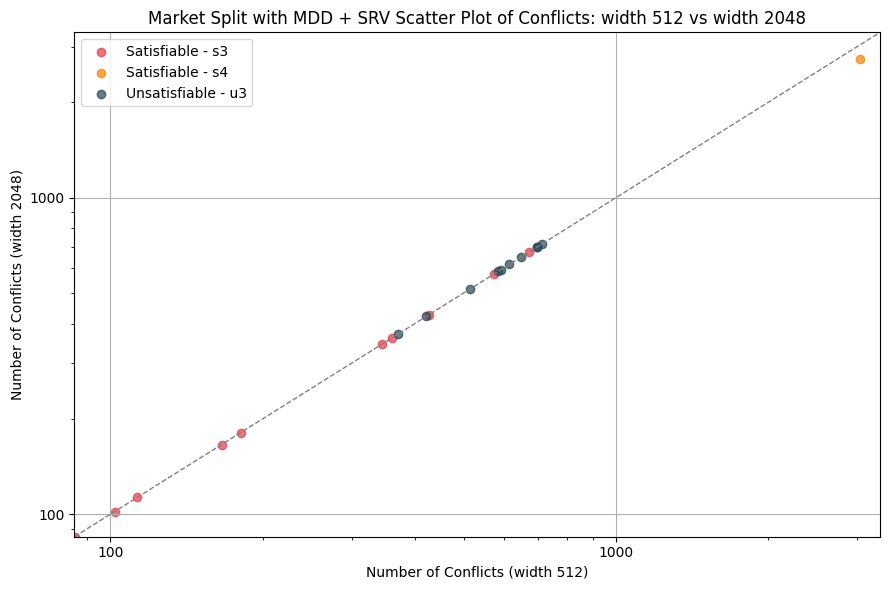

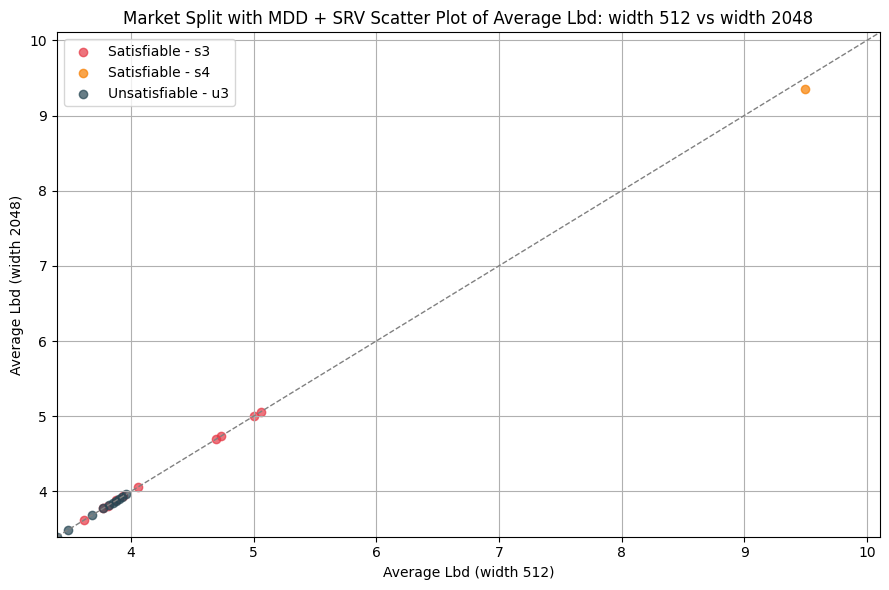

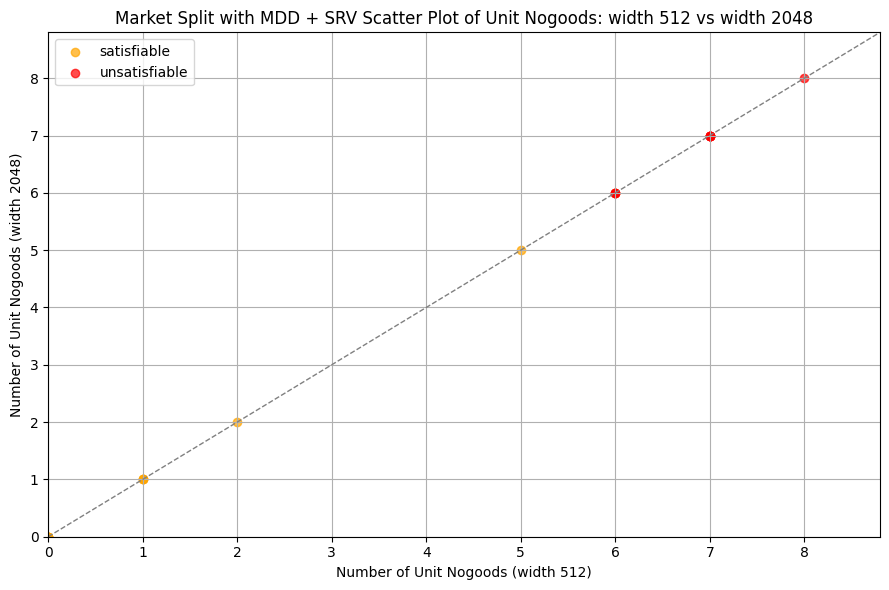

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV + branch SRV first


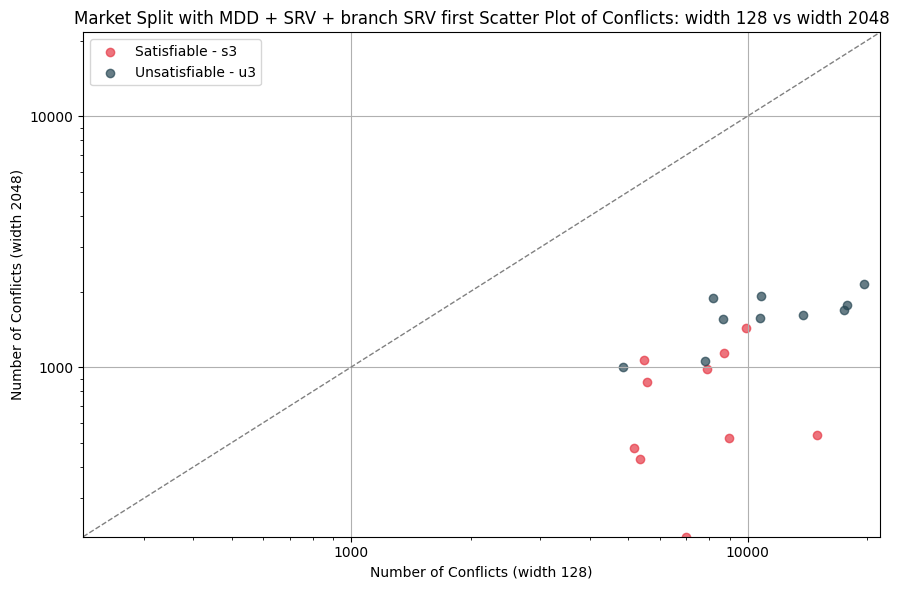

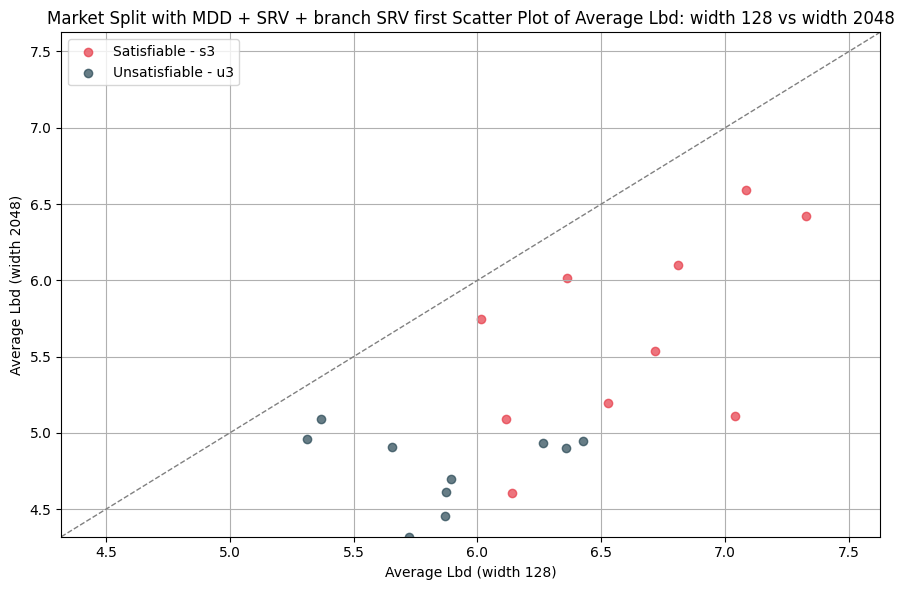

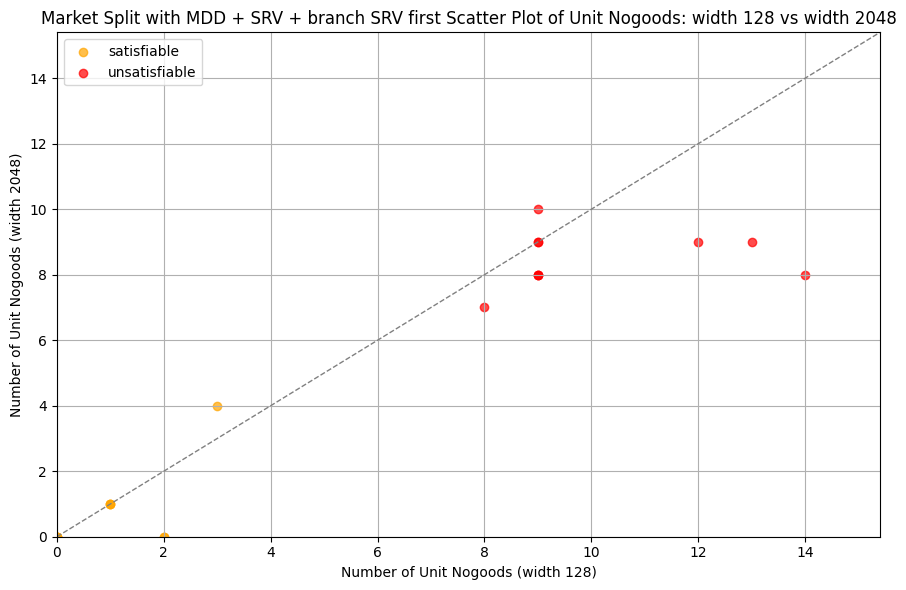

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV + branch SRV first


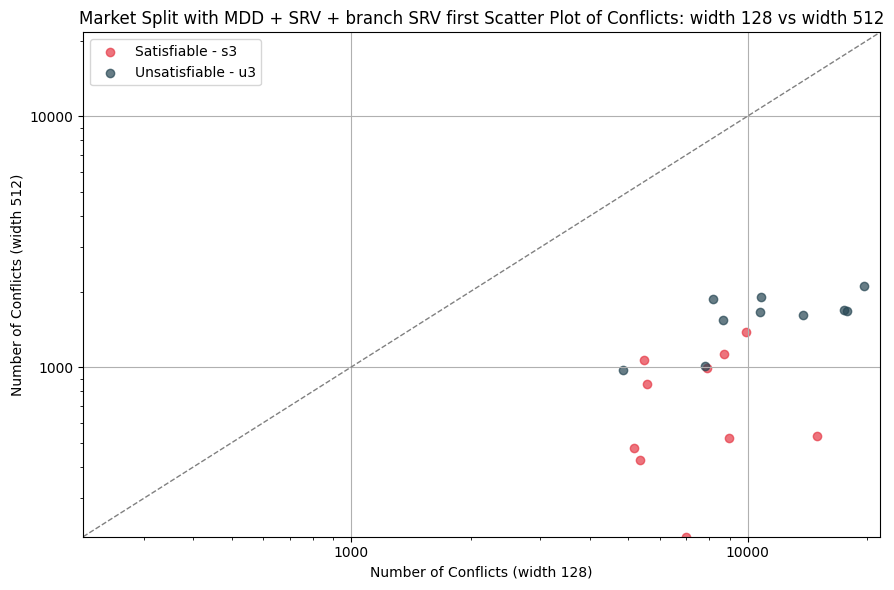

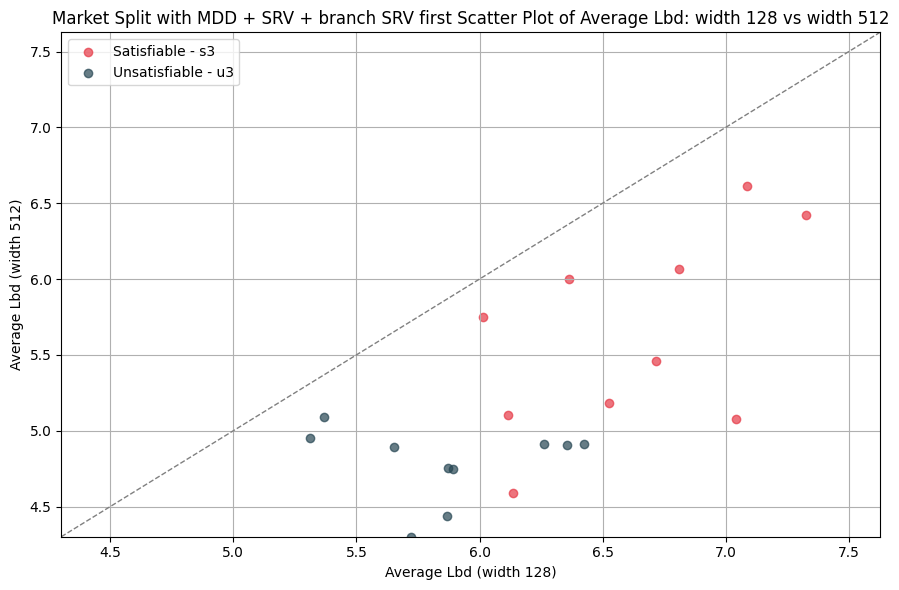

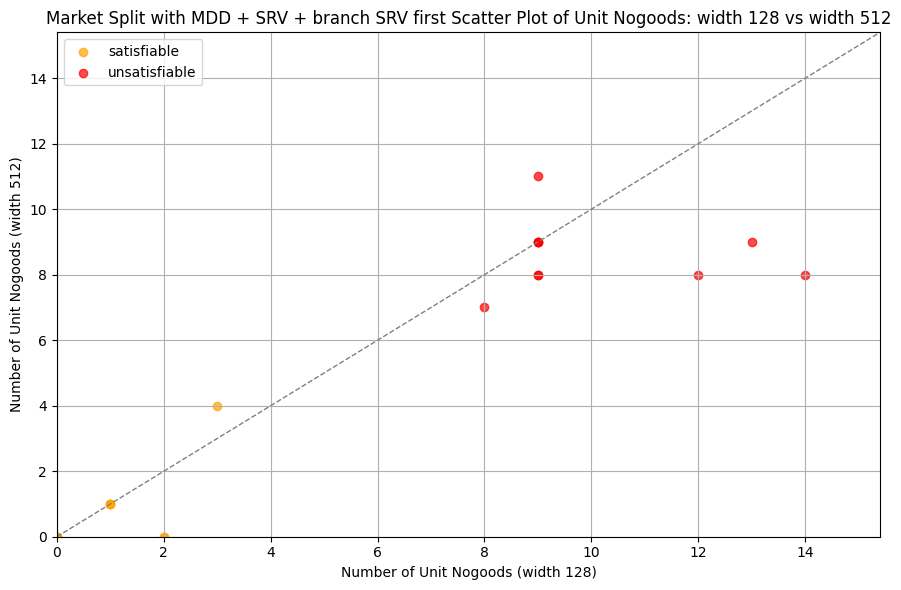

['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['u3-01', 'u3-02', 'u3-03', 'u3-04', 'u3-05', 'u3-06', 'u3-07', 'u3-08', 'u3-09', 'u3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
['s3-01', 's3-02', 's3-03', 's3-04', 's3-05', 's3-06', 's3-07', 's3-08', 's3-09', 's3-10']
Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)
Market Split with MDD + SRV + branch SRV first


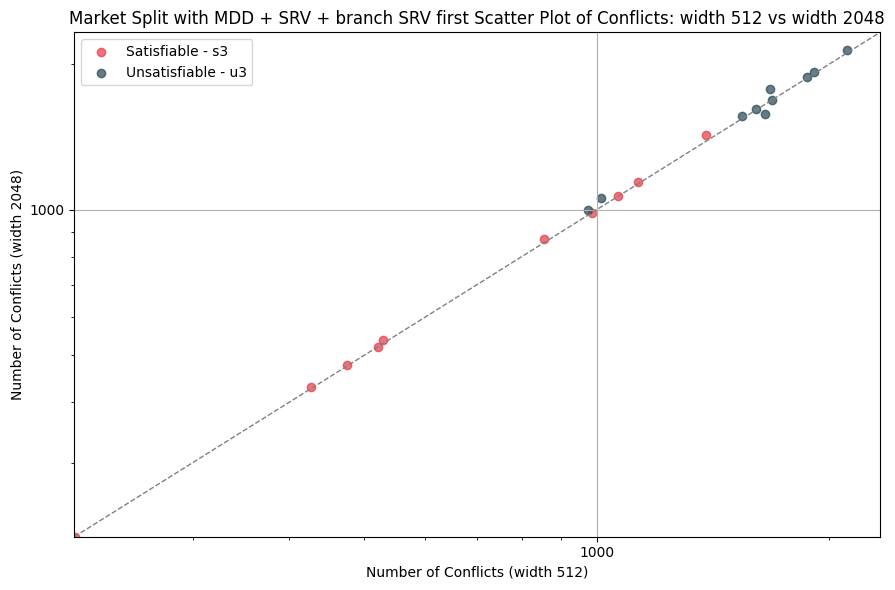

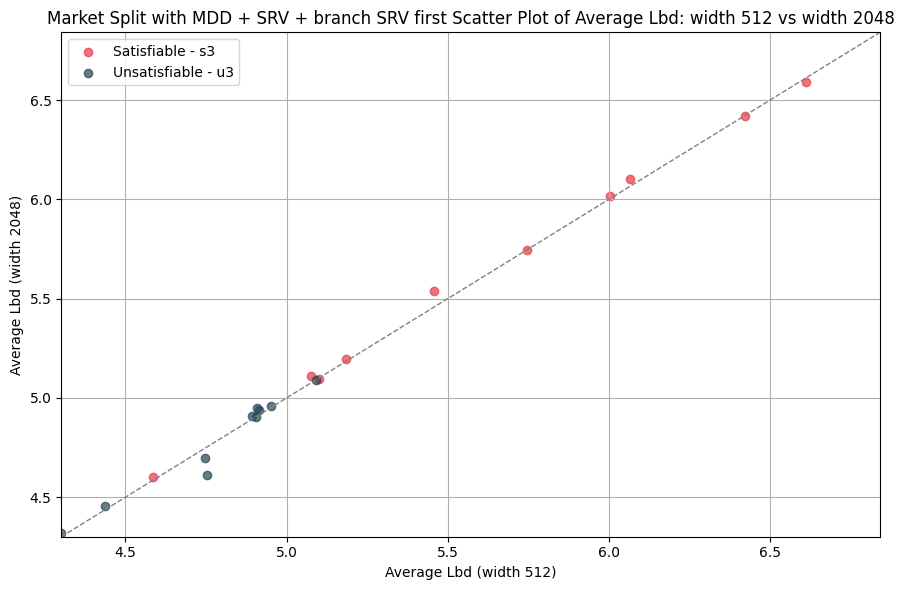

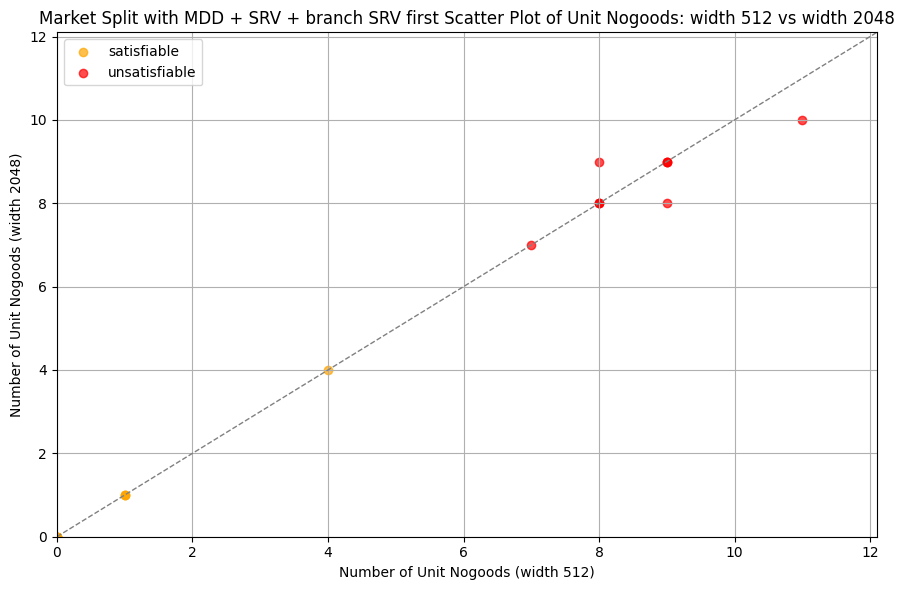

In [12]:
## Market split Max width 128 and 2048
file_128 = 'experiment_w128_1hr/marketsplit_dd_disabled.csv'
file_128_with_mdd = 'experiment_w128_1hr/marketsplit_dd_enabled.csv'
file_512 = 'experiment_w512_1hr/marketsplit_dd_disabled.csv'
file_512_with_mdd = 'experiment_w512_1hr/marketsplit_dd_enabled.csv'
file_2048 = 'experiment_w2048_1hr/marketsplit_dd_disabled.csv'
file_2048_with_mdd = 'experiment_w2048_1hr/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128,file_2048,'width 128','width 2048','Market Split without MDD',  (9,6))
plot_conflicts_and_nogoods(file_128,file_512,'width 128','width 512','Market Split without MDD',  (9,6))
plot_conflicts_and_nogoods(file_512,file_2048,'width 512','width 2048','Market Split without MDD',  (9,6))
plot_conflicts_and_nogoods(file_128_with_mdd,file_2048_with_mdd, 'width 128', 'width 2048 ', 'Market Split with MDD',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd,file_512_with_mdd, 'width 128', 'width 512 ', 'Market Split with MDD',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd,file_2048_with_mdd, 'width 512', 'width 2048 ', 'Market Split with MDD',(9,6))
file_128_with_mdd_srv = 'experiment_w128_1hr/marketsplit_srv.csv'
file_512_with_mdd_srv = 'experiment_w512_1hr/marketsplit_srv.csv'
file_2048_with_mdd_srv = 'experiment_w2048_1hr/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv,file_2048_with_mdd_srv,'width 128','width 2048', 'Market Split with MDD + SRV',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd_srv,file_512_with_mdd_srv,'width 128','width 512', 'Market Split with MDD + SRV',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd_srv,file_2048_with_mdd_srv,'width 512','width 2048', 'Market Split with MDD + SRV',(9,6))
file_128_with_mdd_srv_branchfirst = 'experiment_w128_1hr/marketsplit_srv_branch_first.csv'
file_512_with_mdd_srv_branchfirst = 'experiment_w512_1hr/marketsplit_srv_branch_first.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w2048_1hr/marketsplit_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv_branchfirst,file_2048_with_mdd_srv_branchfirst,'width 128','width 2048', 'Market Split with MDD + SRV + branch SRV first',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd_srv_branchfirst,file_512_with_mdd_srv_branchfirst,'width 128','width 512', 'Market Split with MDD + SRV + branch SRV first',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd_srv_branchfirst,file_2048_with_mdd_srv_branchfirst,'width 512','width 2048', 'Market Split with MDD + SRV + branch SRV first',(9,6))

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ex

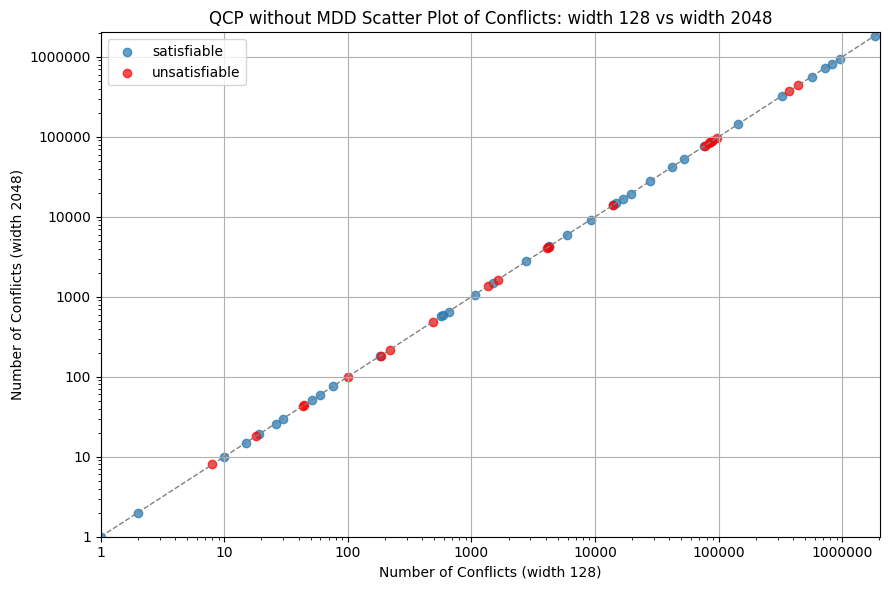

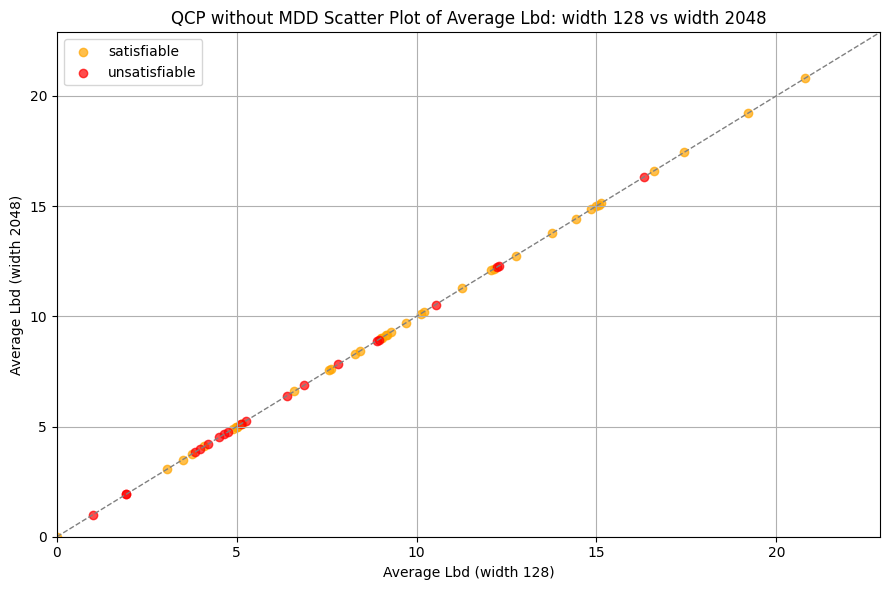

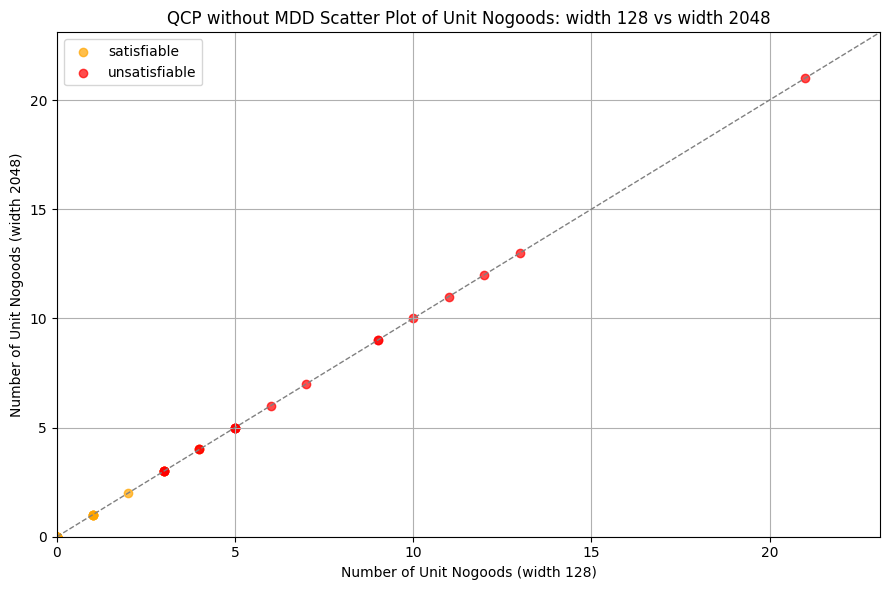

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ex

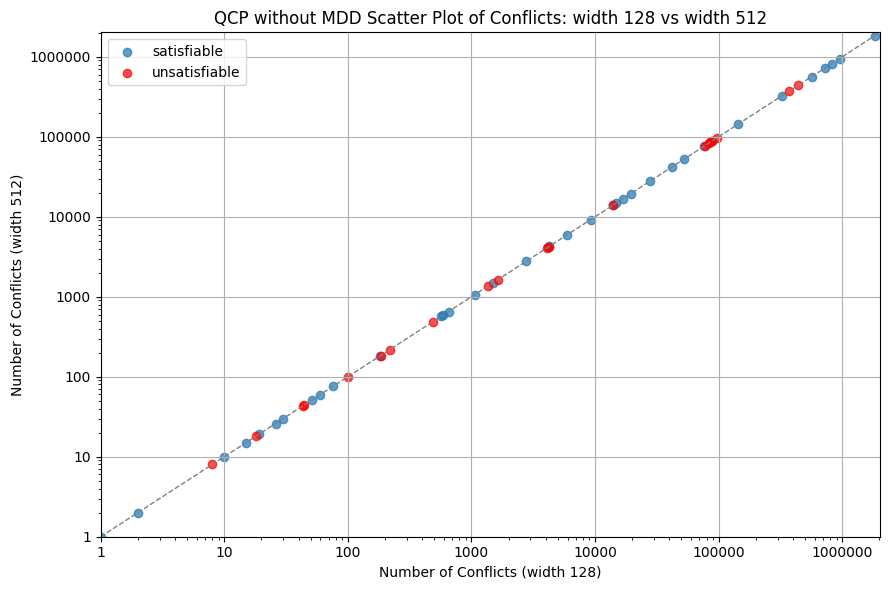

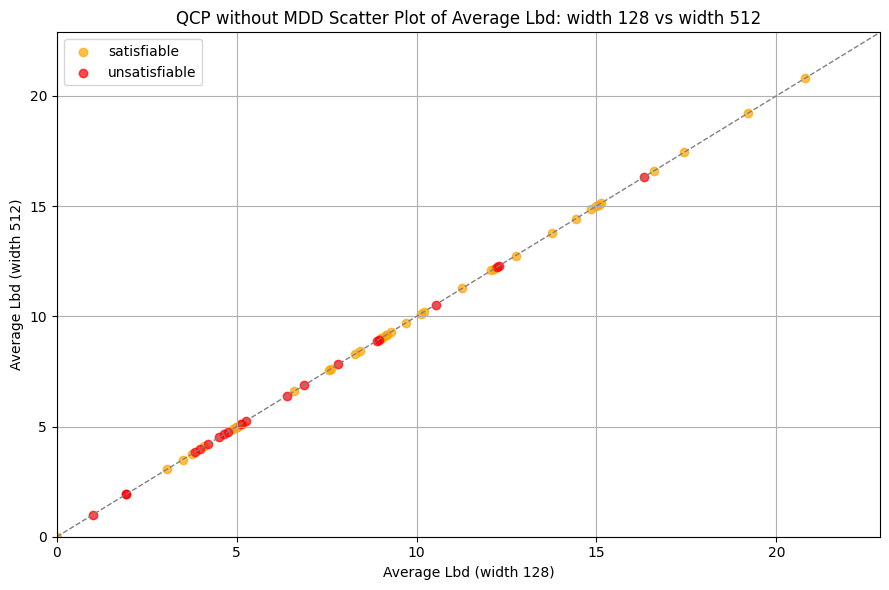

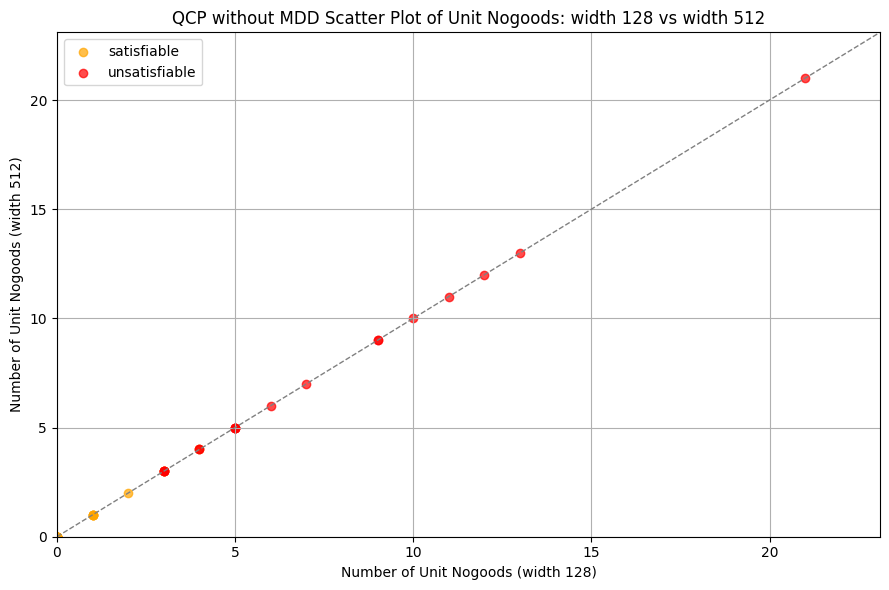

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext', 'qcp-20-187-10_ext', 'qcp-20-187-11_ext', 'qcp-20-187-12_ext', 'qcp-20-187-13_ext', 'qcp-20-187-14_ext', 'qcp-25-264-10_ext', 'qcp-25-264-11_ext', 'qcp-25-264-12_ext', 'qcp-25-264-13_ext', 'qcp-25-264-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ex

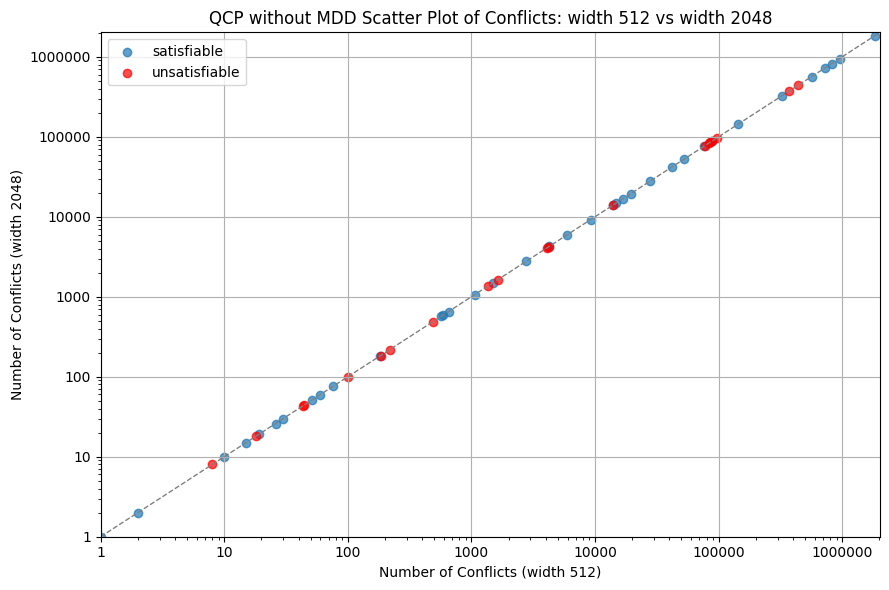

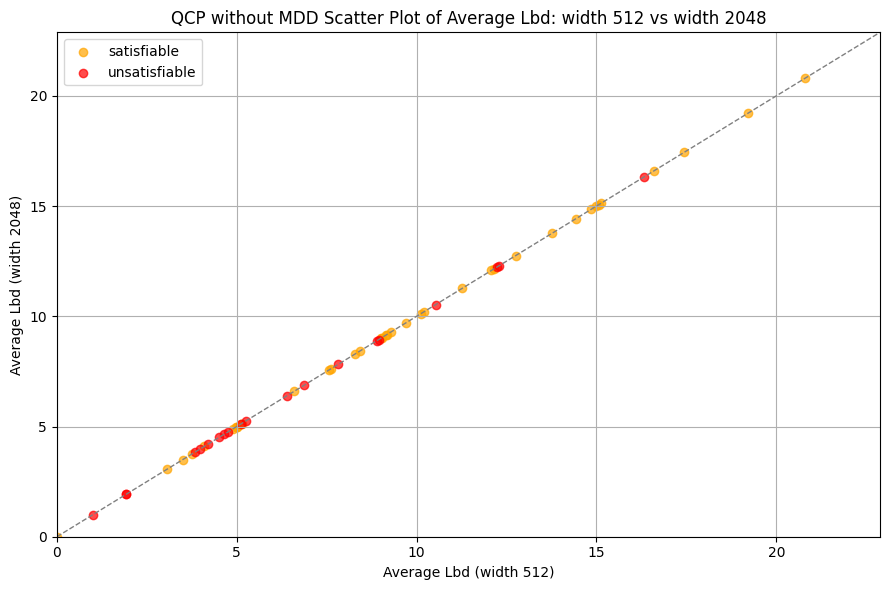

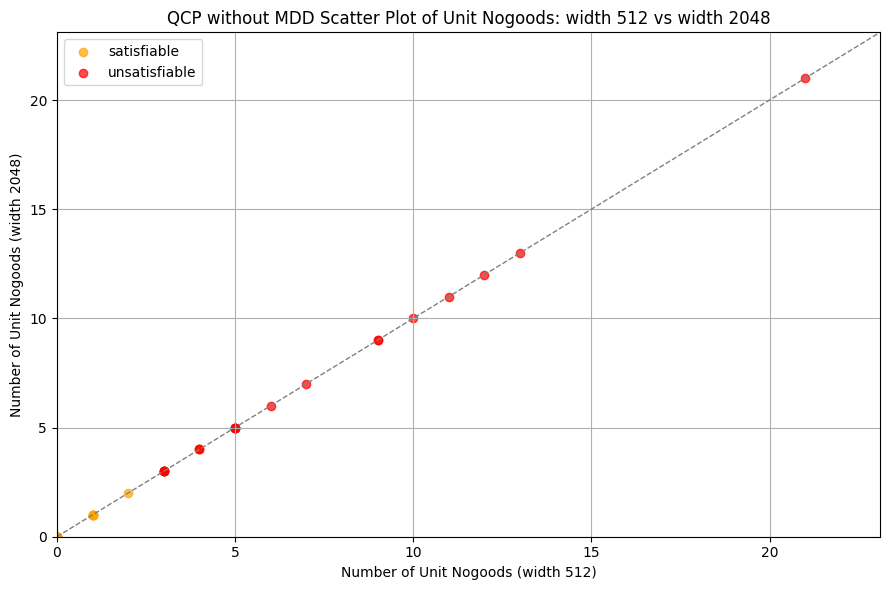

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

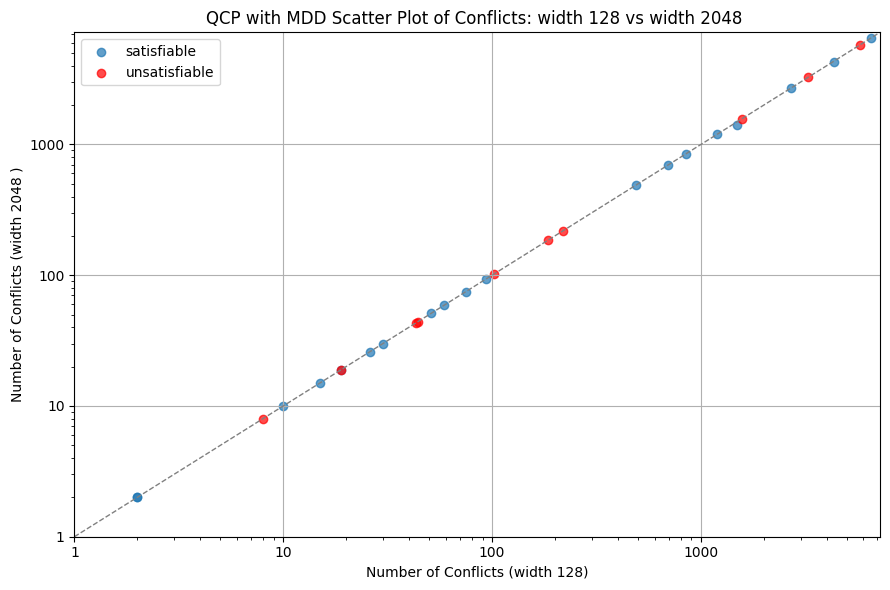

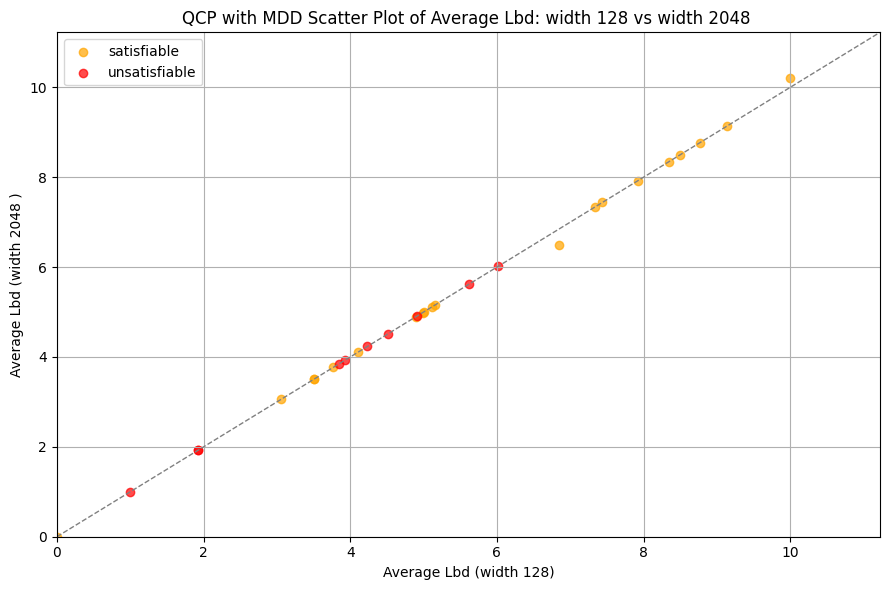

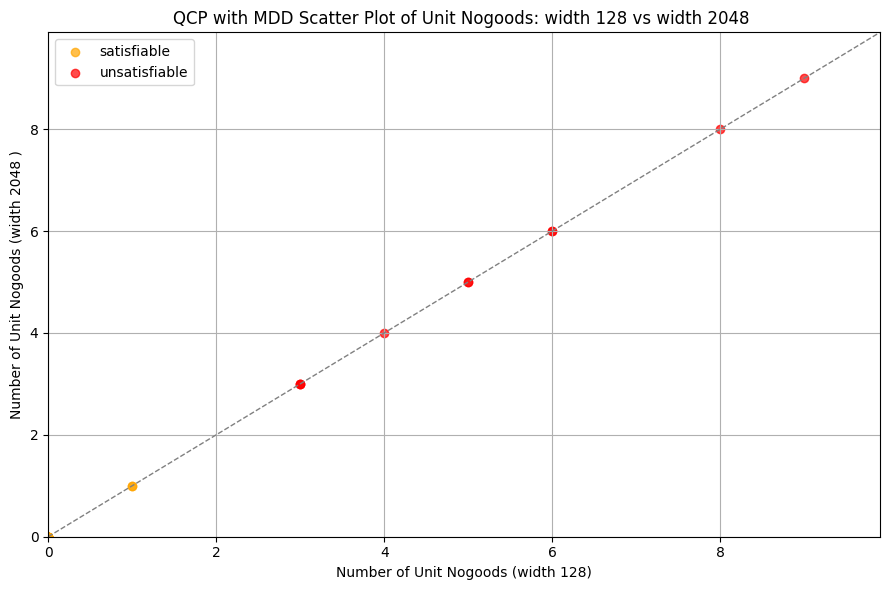

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

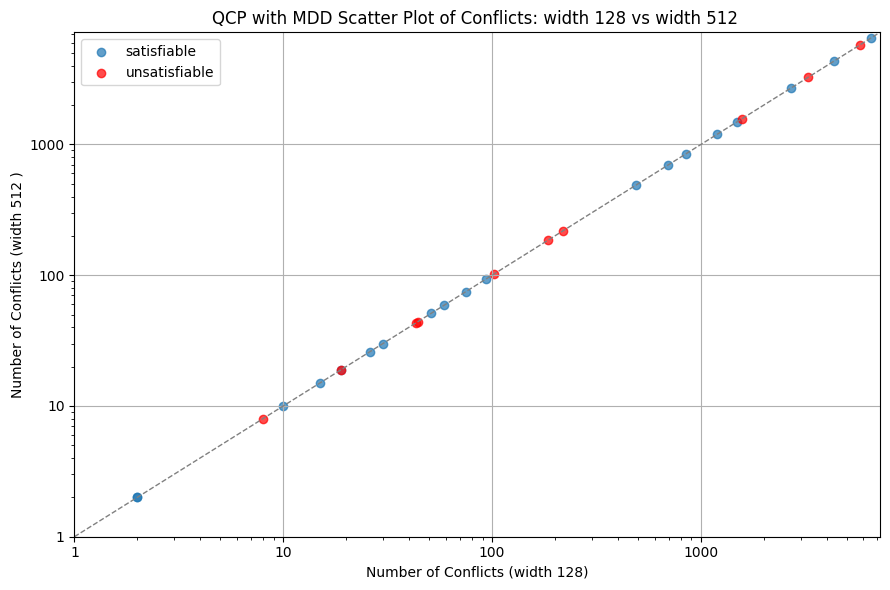

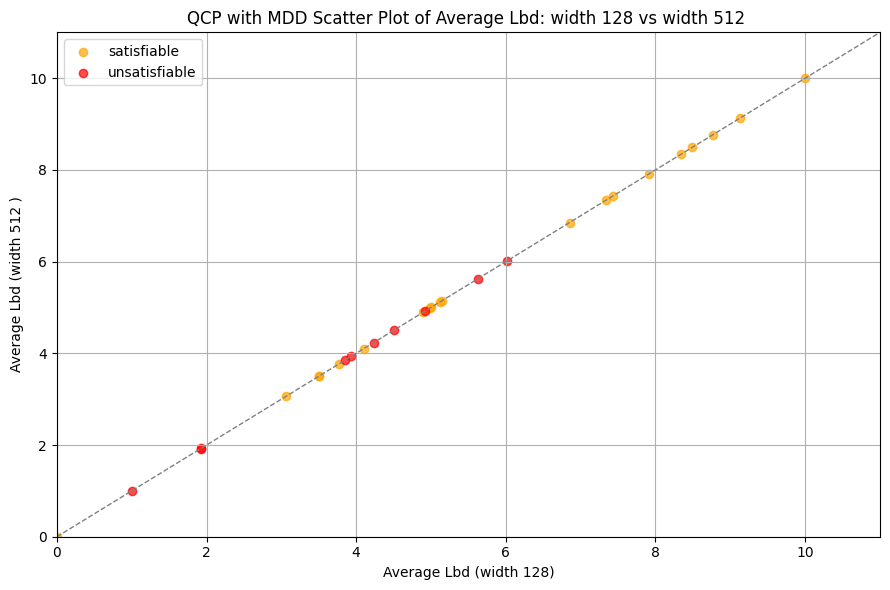

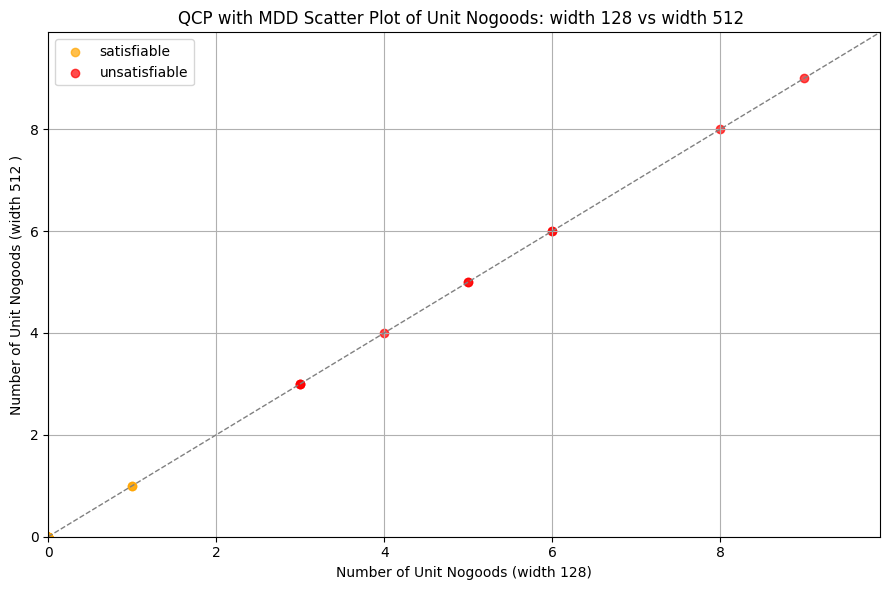

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

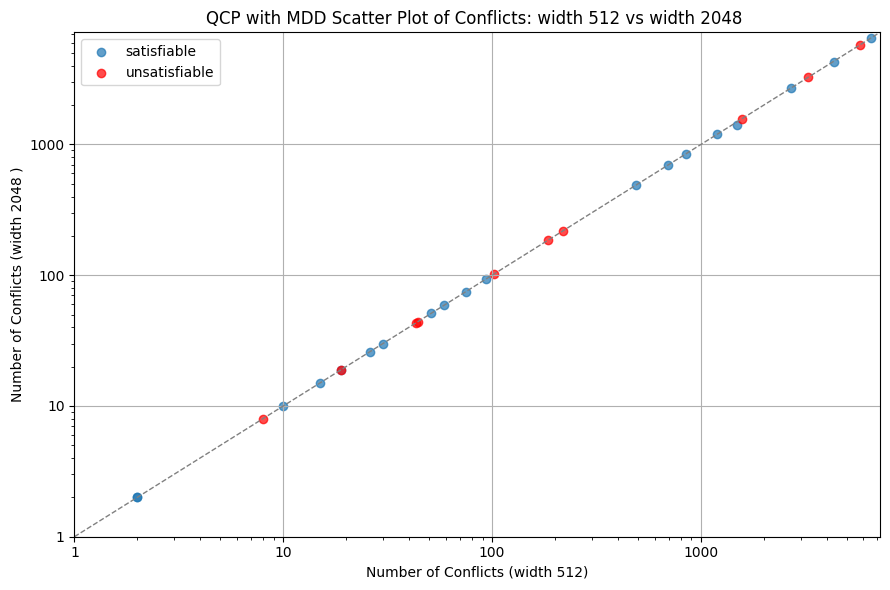

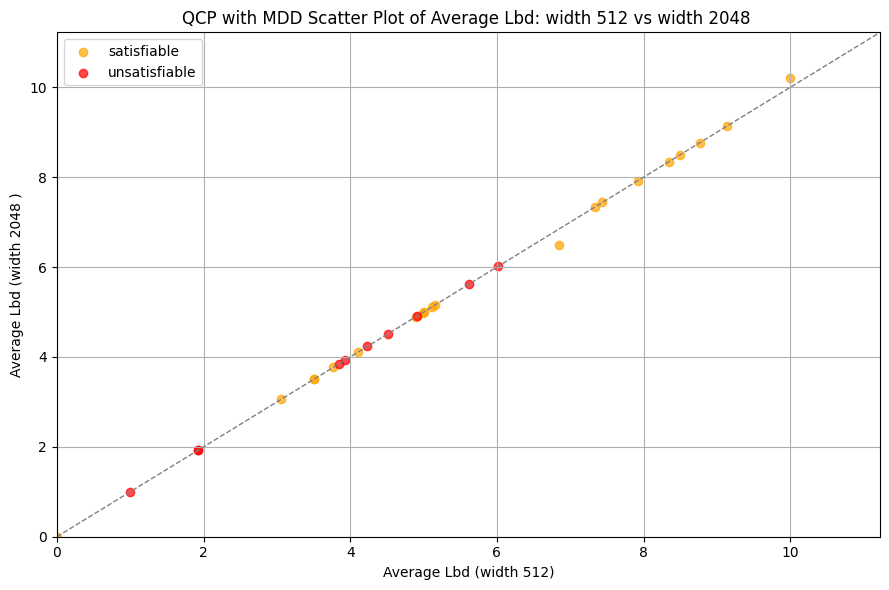

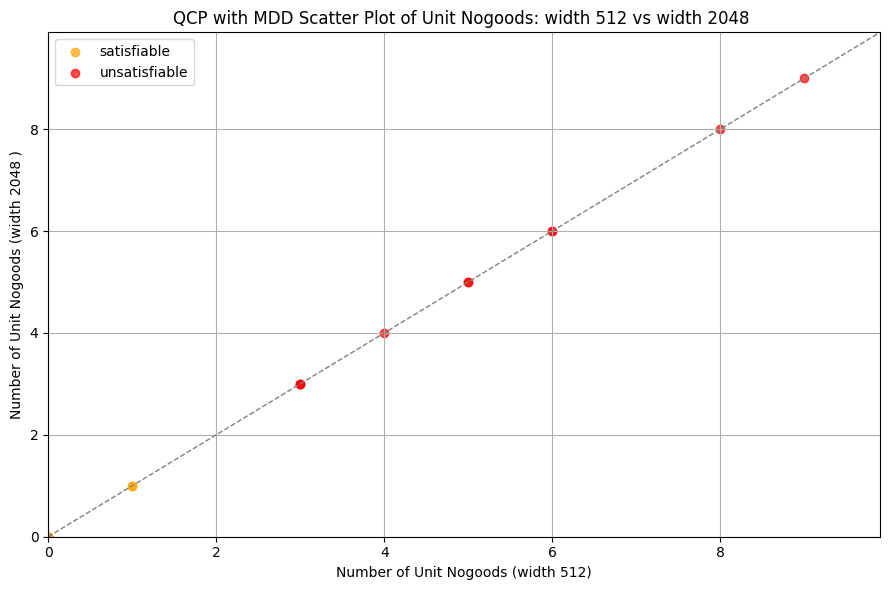

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

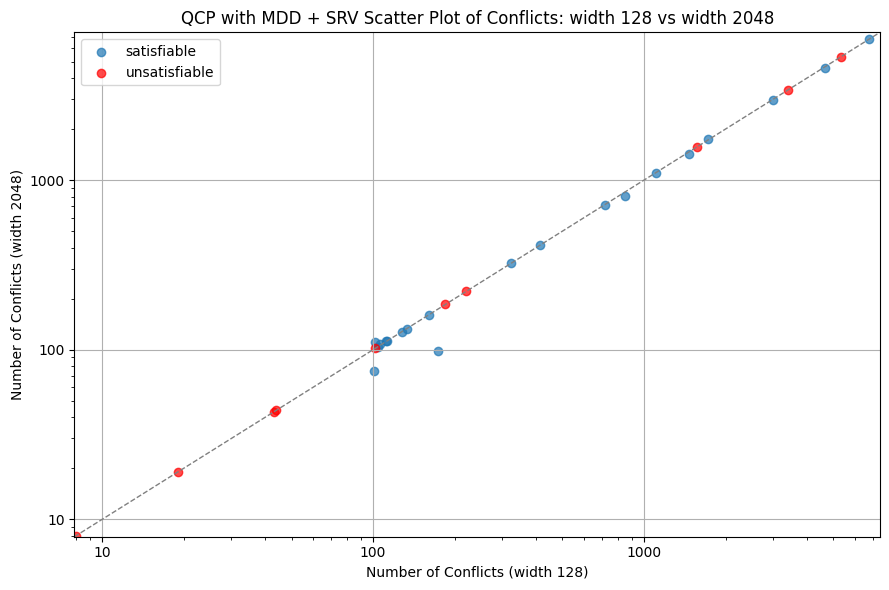

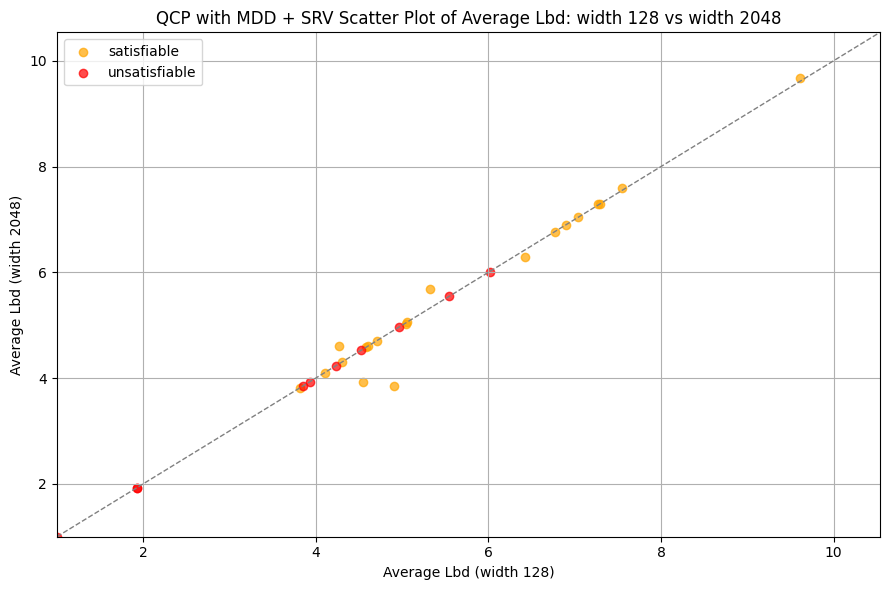

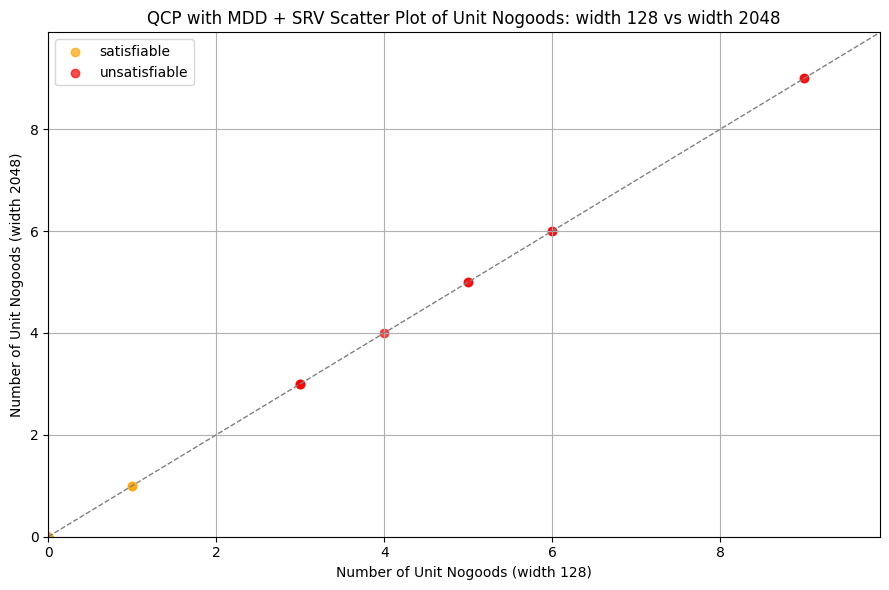

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

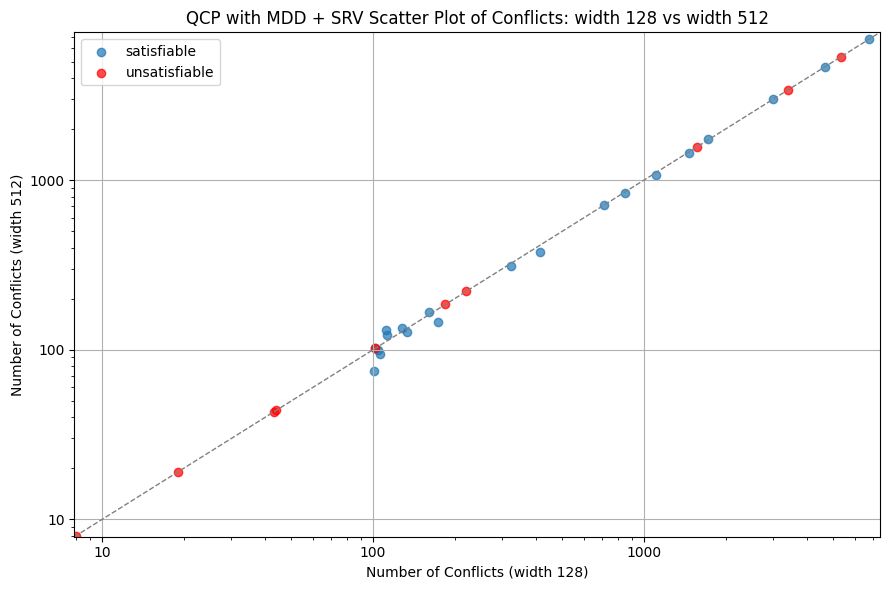

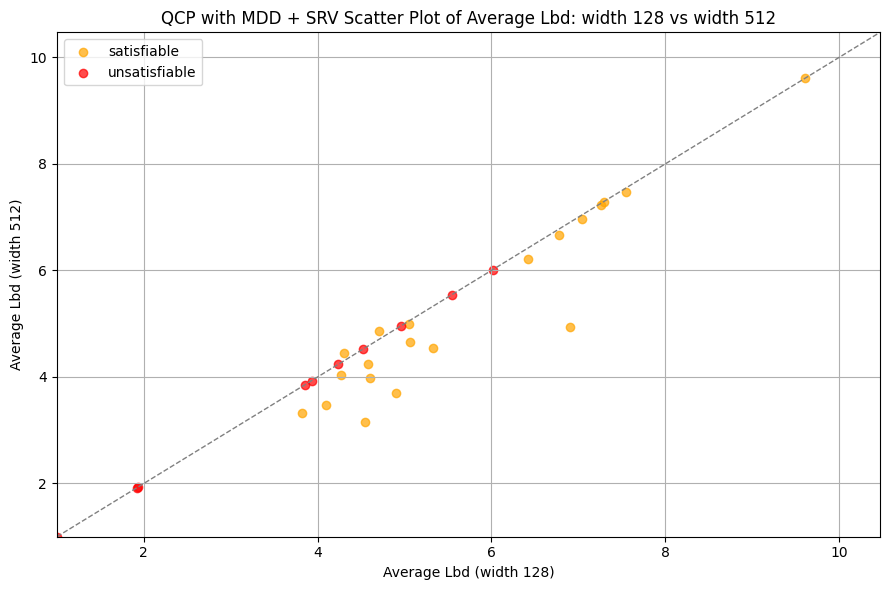

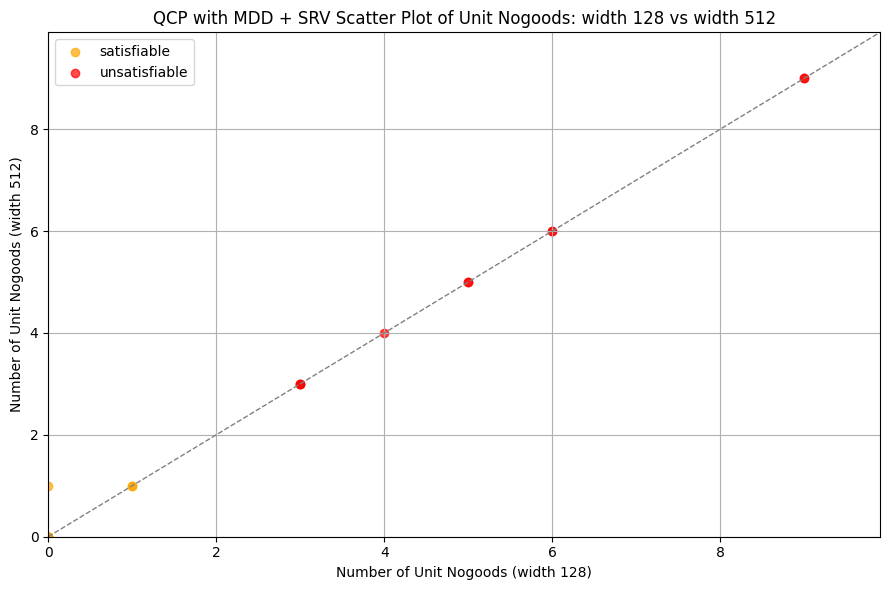

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

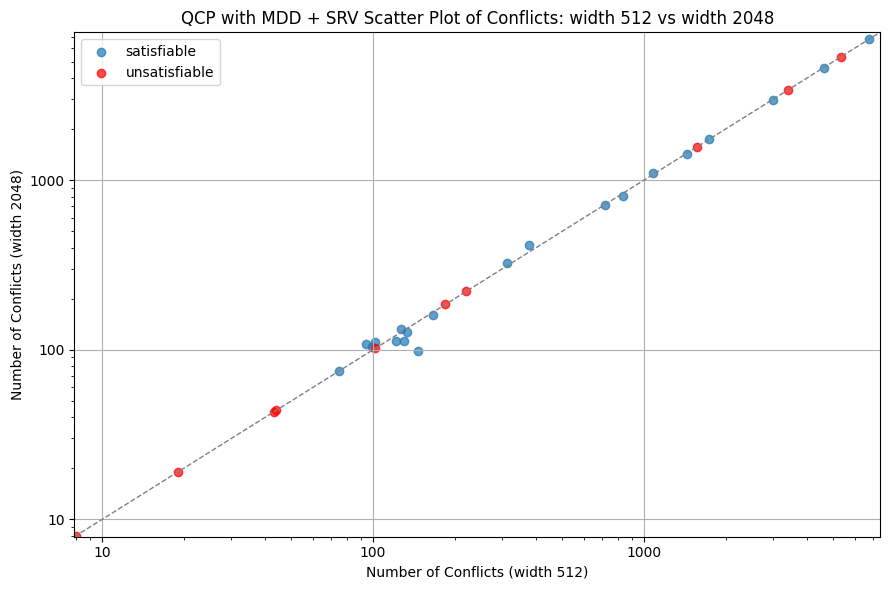

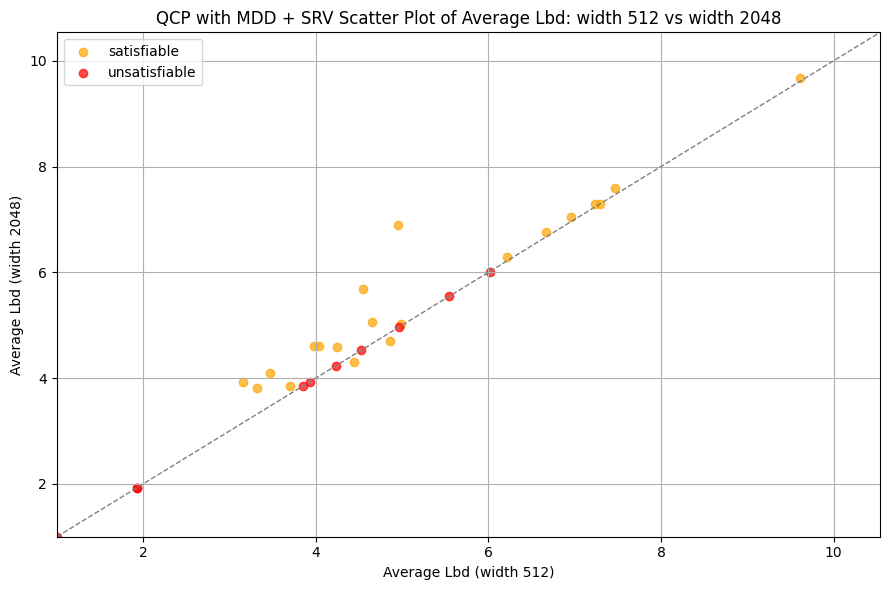

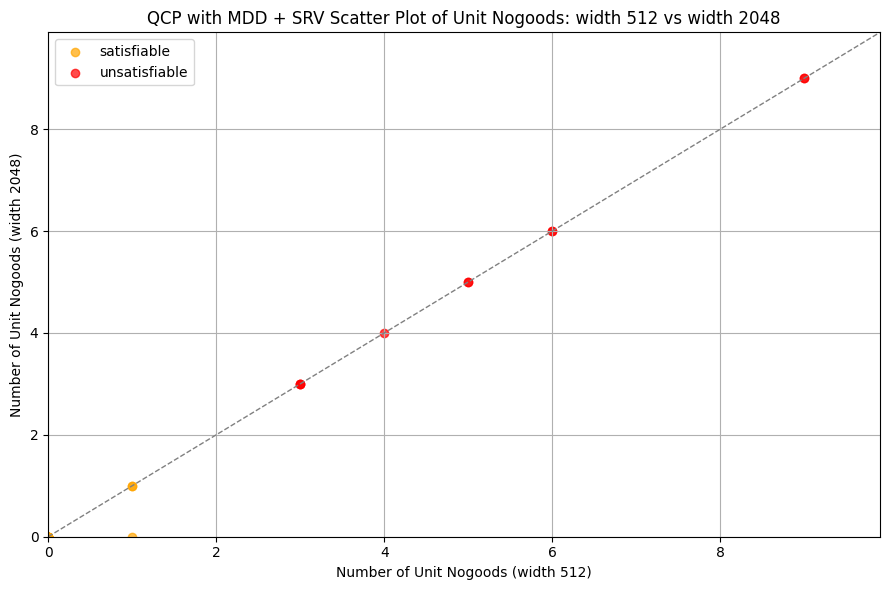

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

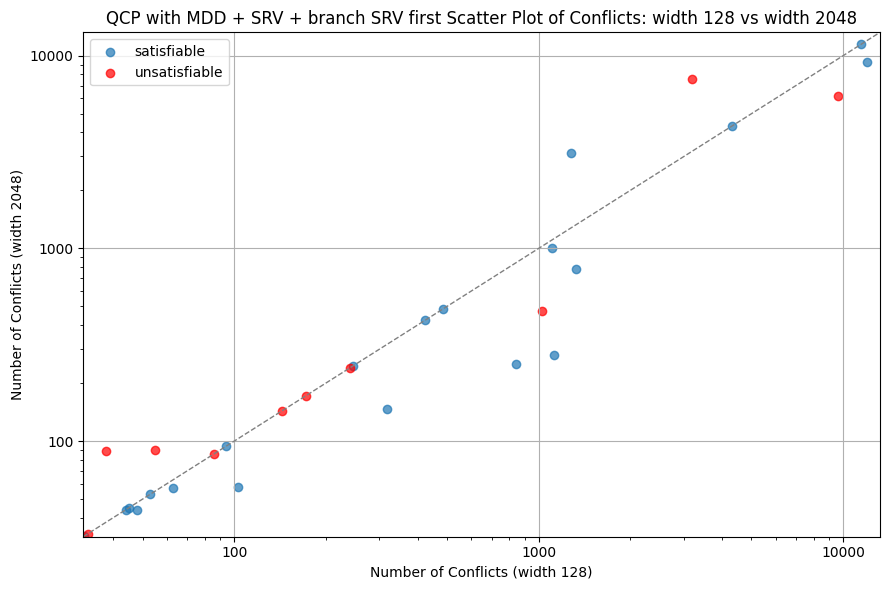

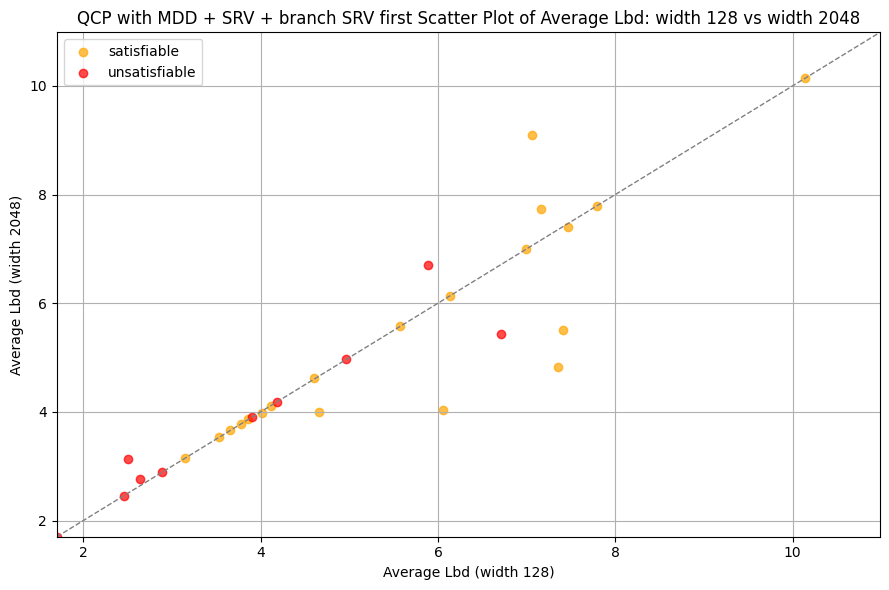

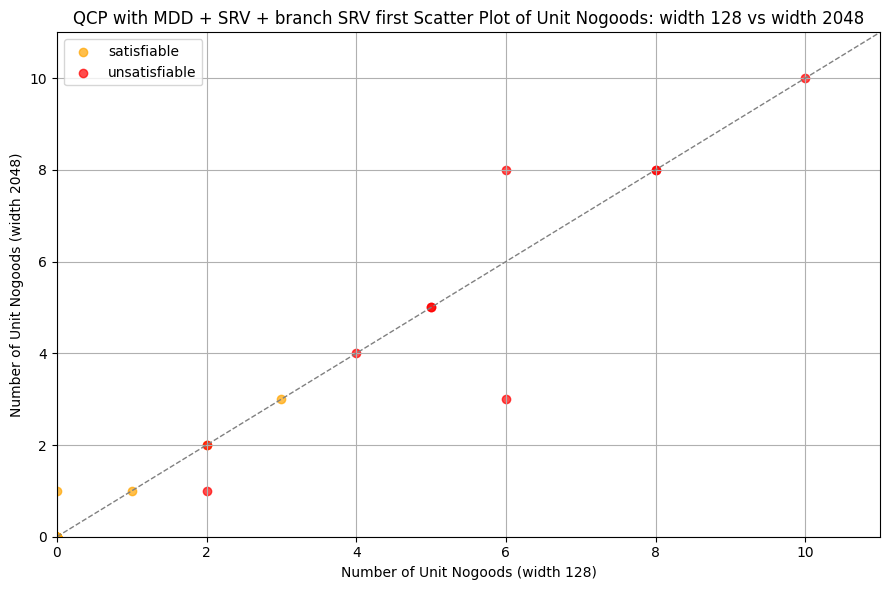

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

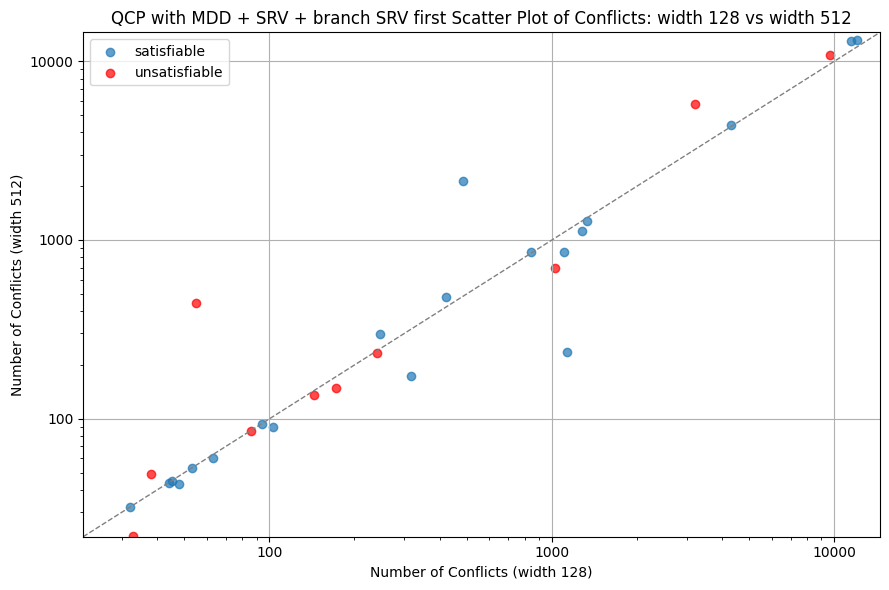

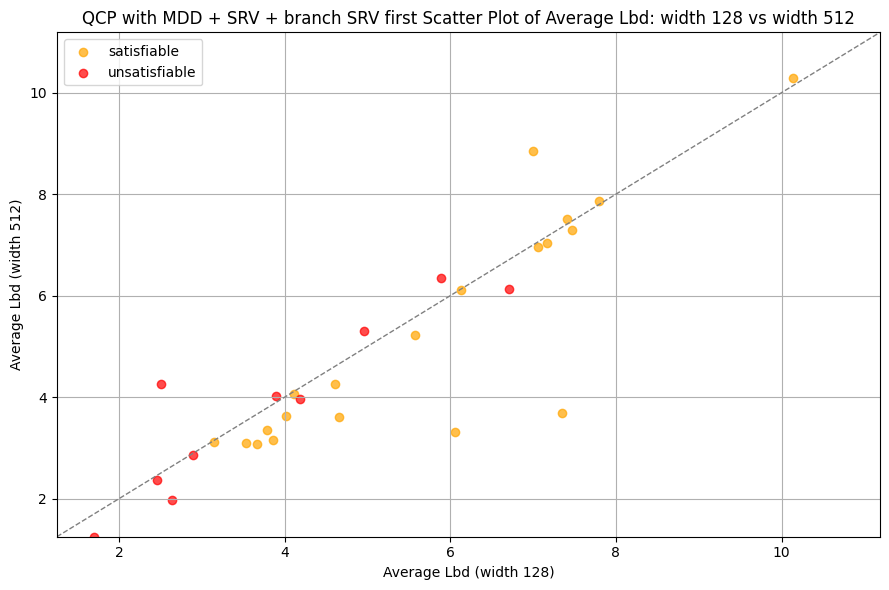

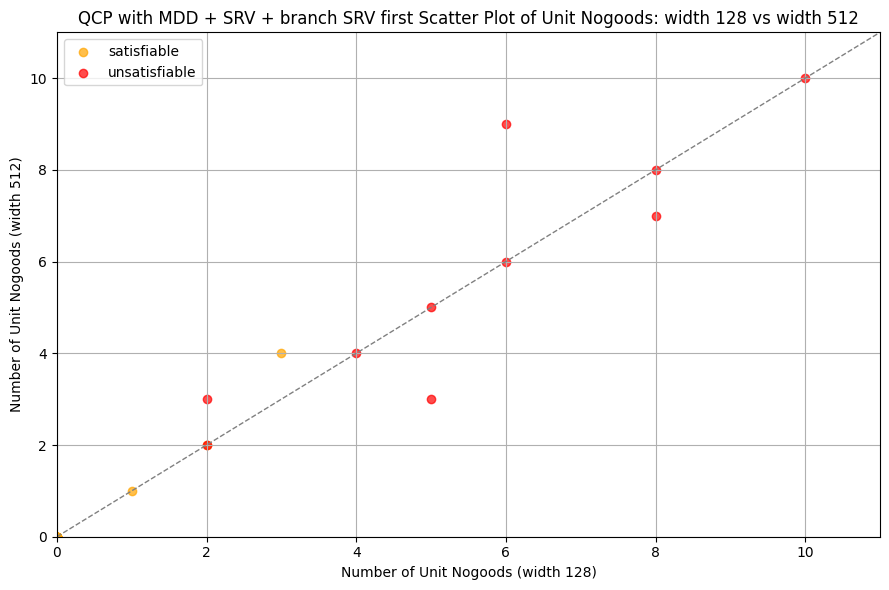

['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-10_ext', 'qcp-10-67-11_ext', 'qcp-10-67-12_ext', 'qcp-10-67-13_ext', 'qcp-10-67-14_ext', 'qcp-15-120-10_ext', 'qcp-15-120-11_ext', 'qcp-15-120-12_ext', 'qcp-15-120-13_ext', 'qcp-15-120-14_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-15-120-0_ext', 'qcp-15-120-1_ext', 'qcp-15-120-2_ext', 'qcp-15-120-3_ext', 'qcp-15-120-4_ext', 'qcp-15-120-5_ext', 'qcp-15-120-6_ext', 'qcp-15-120-7_ext', 'qcp-15-120-8_ext', 'qcp-15-120-9_ext']
['qcp-10-67-0_ext', 'qcp-10-67-1_ext', 'qcp-10-67-2_ext', 'qcp-10-67-3_ext', 'qcp-10-67-4_ext', 'qcp-10-67-5_ext', 'qcp-10-67-6_ext', 'qcp-10-67-7_ext', 'qcp-10-67-8_ext', 'qcp-10-67-9_ext', 'qcp-1

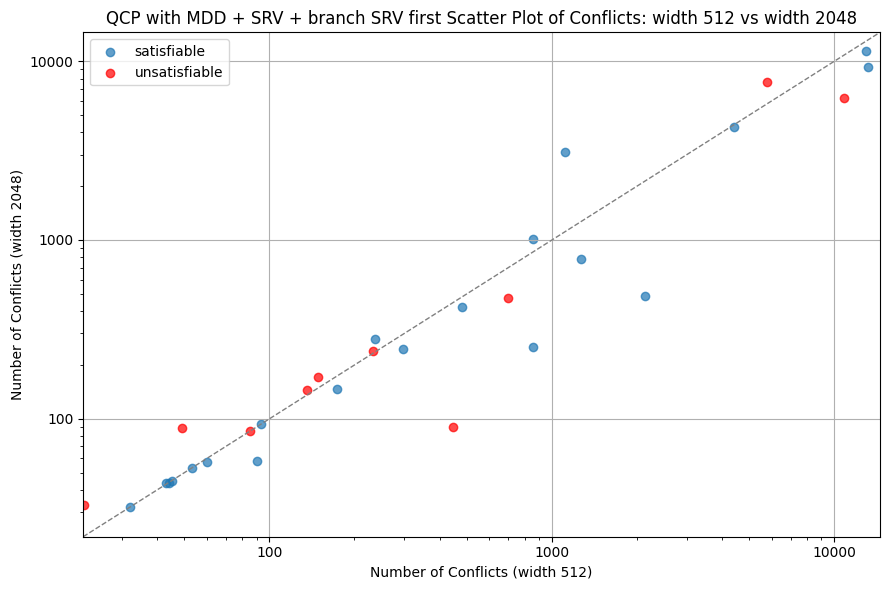

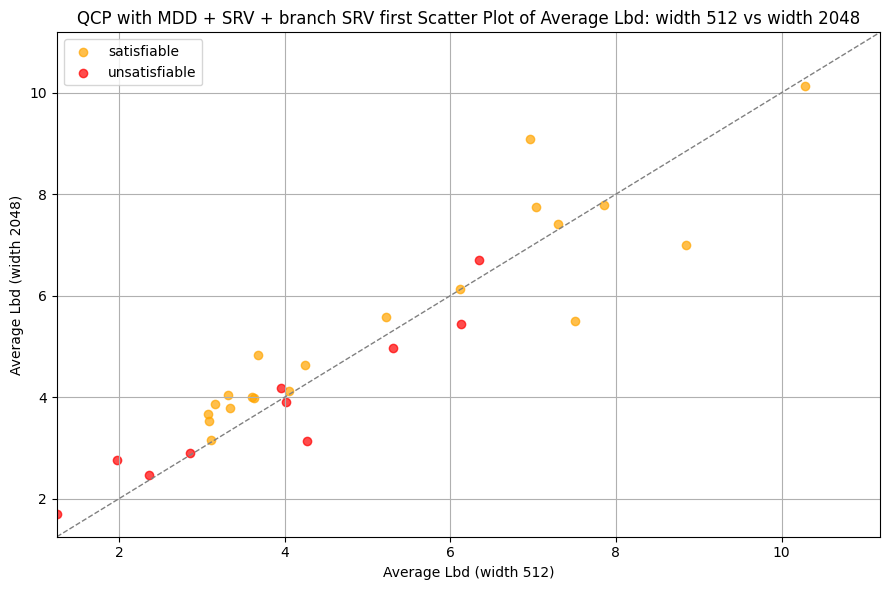

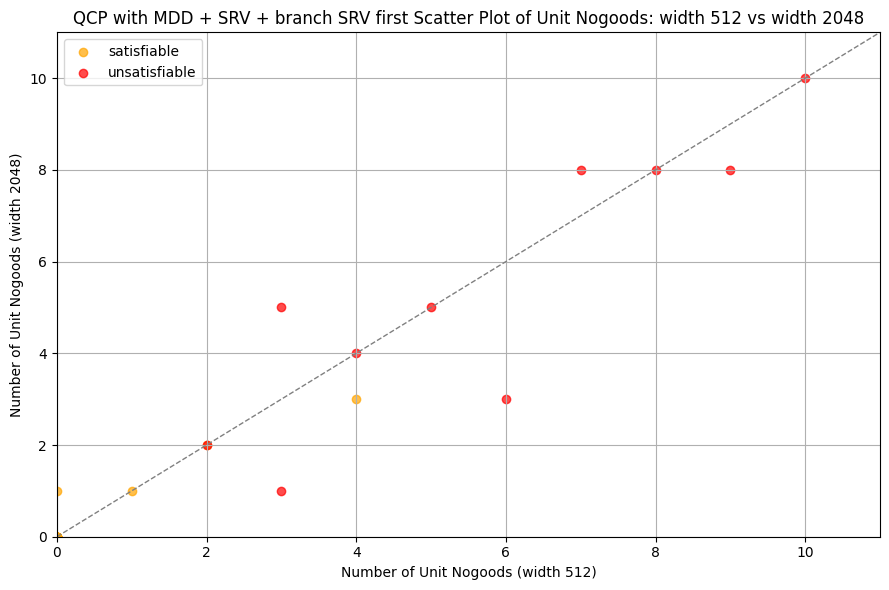

In [13]:
## QCP width 128 and 2048
file_128 = 'experiment_w128_1hr/qcp_disabled.csv'
file_128_with_mdd = 'experiment_w128_1hr/qcp_dd_enabled.csv'
file_512= 'experiment_w512_1hr/qcp_disabled.csv'
file_512_with_mdd = 'experiment_w128_1hr/qcp_dd_enabled.csv'
file_2048 = 'experiment_w2048_1hr/qcp_disabled.csv'
file_2048_with_mdd = 'experiment_w2048_1hr/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128,file_2048,'width 128','width 2048','QCP without MDD',  (9,6))
plot_conflicts_and_nogoods(file_128,file_512,'width 128','width 512','QCP without MDD',  (9,6))
plot_conflicts_and_nogoods(file_512,file_2048,'width 512','width 2048','QCP without MDD',  (9,6))
plot_conflicts_and_nogoods(file_128_with_mdd,file_2048_with_mdd, 'width 128', 'width 2048 ', 'QCP with MDD',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd,file_512_with_mdd, 'width 128', 'width 512 ', 'QCP with MDD',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd,file_2048_with_mdd, 'width 512', 'width 2048 ', 'QCP with MDD',(9,6))
file_128_with_mdd_srv = 'experiment_w128_1hr/qcp_srv.csv'
file_512_with_mdd_srv = 'experiment_w512_1hr/qcp_srv.csv'
file_2048_with_mdd_srv = 'experiment_w2048_1hr/qcp_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv,file_2048_with_mdd_srv,'width 128','width 2048', 'QCP with MDD + SRV',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd_srv,file_512_with_mdd_srv,'width 128','width 512', 'QCP with MDD + SRV',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd_srv,file_2048_with_mdd_srv,'width 512','width 2048', 'QCP with MDD + SRV',(9,6))
file_128_with_mdd_srv_branchfirst = 'experiment_w128_1hr/qcp_srv_branch_first.csv'
file_512_with_mdd_srv_branchfirst = 'experiment_w512_1hr/qcp_srv_branch_first.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_w2048_1hr/qcp_srv_branch_first.csv'
plot_conflicts_and_nogoods(file_128_with_mdd_srv_branchfirst,file_2048_with_mdd_srv_branchfirst,'width 128','width 2048', 'QCP with MDD + SRV + branch SRV first',(9,6))
plot_conflicts_and_nogoods(file_128_with_mdd_srv_branchfirst,file_512_with_mdd_srv_branchfirst,'width 128','width 512', 'QCP with MDD + SRV + branch SRV first',(9,6))
plot_conflicts_and_nogoods(file_512_with_mdd_srv_branchfirst,file_2048_with_mdd_srv_branchfirst,'width 512','width 2048', 'QCP with MDD + SRV + branch SRV first',(9,6))
